[1] Raw dataset shape          : (3653, 48)
    Columns                    : ['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value', 'Value']
[2] After IC5

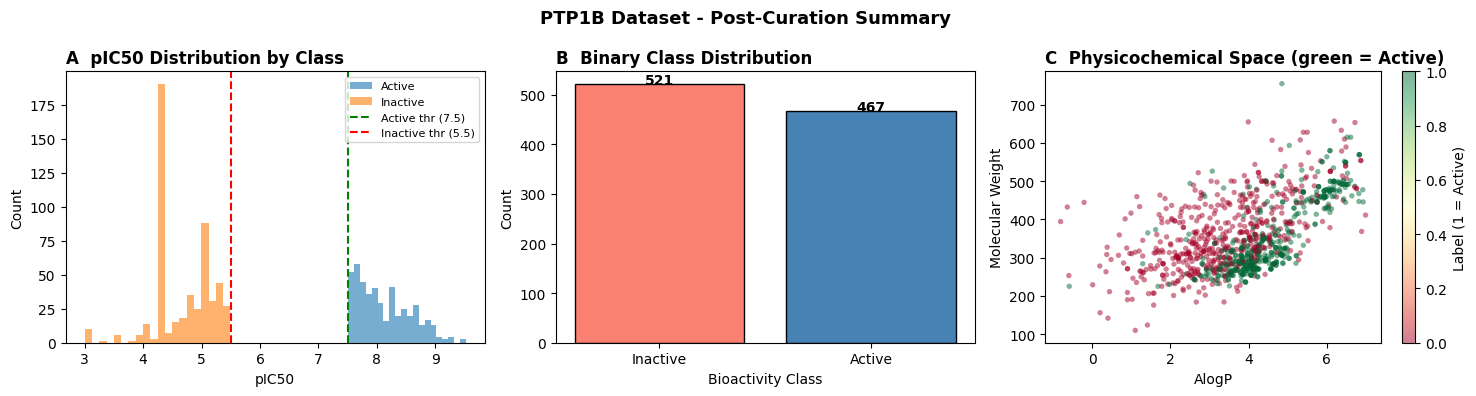

Data curation pipeline complete.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 – Load raw dataset
# ─────────────────────────────────────────────────────────────────────────────
RAW_PATH  = "/Users/abbaskhan/Desktop/ESR_beta_new/esrbetsa_raw.csv"
SAVE_PATH = "/Users/abbaskhan/Desktop/ESR_beta_new/esrbetsa_raw_clean_1.csv"

df_raw = pd.read_csv(RAW_PATH, sep=';')
print("[1] Raw dataset shape          :", df_raw.shape)
print("    Columns                    :", list(df_raw.columns))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 – Retain only reliable IC50 measurements in nM
# ─────────────────────────────────────────────────────────────────────────────
df = df_raw.copy()
df = df[df["Standard Type"].str.upper().str.strip() == "IC50"]
df = df[df["Standard Units"].str.strip() == "nM"]
print("[2] After IC50 / nM filter     :", df.shape)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 – Drop rows with missing values in critical columns
# ─────────────────────────────────────────────────────────────────────────────
critical_cols = ["Molecule ChEMBL ID", "Smiles", "Standard Value",
                 "Molecular Weight", "AlogP"]
df.dropna(subset=critical_cols, inplace=True)
print("[3] After dropping missing rows :", df.shape)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 – Enforce numeric types and sensible value ranges
# ─────────────────────────────────────────────────────────────────────────────
for col in ["Standard Value", "Molecular Weight", "AlogP"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.dropna(subset=["Standard Value", "Molecular Weight", "AlogP"], inplace=True)

# IC50 must be strictly positive (needed for log transform)
df = df[df["Standard Value"] > 0]
print("[4] After numeric type checks  :", df.shape)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 – Compute / verify pIC50
#           pIC50 = -log10(IC50_M) = -log10(IC50_nM * 1e-9) = 9 - log10(IC50_nM)
# ─────────────────────────────────────────────────────────────────────────────
df["pIC50"] = 9 - np.log10(df["Standard Value"])

# If the dataset already had a pIC50 column, validate & overwrite
if "pIC50" in df_raw.columns:
    df["pIC50_orig"] = pd.to_numeric(df_raw.loc[df.index, "pIC50"], errors="coerce")
    disagreement = (df["pIC50_orig"] - df["pIC50"]).abs() > 0.05
    print(f"    pIC50 recalculated; {disagreement.sum()} rows had >0.05 unit discrepancy (overwritten)")
    df.drop(columns=["pIC50_orig"], inplace=True)

print(f"[5] pIC50 range                : {df['pIC50'].min():.2f} - {df['pIC50'].max():.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 – Remove duplicate entries
#           Primary: exact duplicate rows; Secondary: same ChEMBL ID x IC50 pair
# ─────────────────────────────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.drop_duplicates(subset=["Molecule ChEMBL ID", "Standard Value"], keep="first", inplace=True)
print(f"[6] After removing duplicates  : {df.shape}  (removed {before - len(df)})")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 – Flag and remove conflicting replicates
#           Compounds whose pIC50 measurements span > 0.5 log units are unreliable
# ─────────────────────────────────────────────────────────────────────────────
replicate_stats = df.groupby("Molecule ChEMBL ID")["pIC50"].agg(["mean", "std", "count"])
inconsistent_ids = replicate_stats[
    (replicate_stats["count"] > 1) & (replicate_stats["std"] > 0.5)
].index
df_conflict = df[df["Molecule ChEMBL ID"].isin(inconsistent_ids)]
df = df[~df["Molecule ChEMBL ID"].isin(inconsistent_ids)]
n_conflict_cpds = df_conflict["Molecule ChEMBL ID"].nunique()
print(f"[7] Removed {len(df_conflict)} rows ({n_conflict_cpds} compounds) with conflicting replicates (std pIC50 > 0.5)")
print("    After conflict removal      :", df.shape)

# For compounds with multiple concordant replicates, keep the row closest to median pIC50
df["_median_pIC50"] = df.groupby("Molecule ChEMBL ID")["pIC50"].transform("median")
df["_dist"] = (df["pIC50"] - df["_median_pIC50"]).abs()
df = df.sort_values("_dist").drop_duplicates(subset="Molecule ChEMBL ID", keep="first")
df.drop(columns=["_median_pIC50", "_dist"], inplace=True)
print("    After collapsing replicates :", df.shape)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 – Remove compounds with unrealistic physicochemical properties
#           Cutoffs inspired by Lipinski Ro5 + extended Veber / PTP1B context
# ─────────────────────────────────────────────────────────────────────────────
physchem_mask = (
    df["Molecular Weight"].between(100, 900) &   # avoid fragments & macromolecules
    df["AlogP"].between(-3, 7)                   # drug-like lipophilicity window
)
removed_physchem = (~physchem_mask).sum()
df = df[physchem_mask]
print(f"[8] Removed {removed_physchem} compounds with unrealistic physicochemical properties")
print("    After physicochemical filter:", df.shape)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 9 – Assign bioactivity labels
#           Active      : pIC50 >= 6   (IC50 <= 1 uM  – potent inhibitors)
#           Intermediate: 5 <= pIC50 < 6 (IC50 1-10 uM – excluded to reduce noise)
#           Inactive    : pIC50 < 5   (IC50 > 10 uM  – poor inhibitors)
# ─────────────────────────────────────────────────────────────────────────────
ACTIVE_THR   = 7.5   # pIC50 >= 6  -> Active
INACTIVE_THR = 5.5   # pIC50 <  5  -> Inactive  (5 <= pIC50 < 6 -> Intermediate, excluded)

def assign_label(p):
    if p >= ACTIVE_THR:
        return "Active"
    elif p < INACTIVE_THR:
        return "Inactive"
    else:
        return "Intermediate"

df["Bioactivity_Class"] = df["pIC50"].apply(assign_label)
class_counts = df["Bioactivity_Class"].value_counts()
print("[9] Class distribution (before exclusion):")
print(class_counts.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# STEP 10 – Exclude intermediate compounds (ambiguous zone -> label noise)
# ─────────────────────────────────────────────────────────────────────────────
df_intermediate = df[df["Bioactivity_Class"] == "Intermediate"]
df = df[df["Bioactivity_Class"] != "Intermediate"].copy()
print(f"[10] Removed {len(df_intermediate)} intermediate compounds (7.5 <= pIC50 < 5.5)")
print("     Final dataset shape        :", df.shape)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 11 – Create binary numeric label  (Active = 1, Inactive = 0)
# ─────────────────────────────────────────────────────────────────────────────
df["Label"] = (df["Bioactivity_Class"] == "Active").astype(int)
final_counts = df["Bioactivity_Class"].value_counts()
pct_active   = final_counts.get("Active",   0) / len(df) * 100
pct_inactive = final_counts.get("Inactive", 0) / len(df) * 100
print("[11] Final binary class distribution:")
print(final_counts.to_string())
print(f"     Class balance               : {pct_active:.1f}% Active, {pct_inactive:.1f}% Inactive")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 12 – Select & reorder final columns, then save
# ─────────────────────────────────────────────────────────────────────────────
final_cols = ["Molecule ChEMBL ID", "Smiles", "Standard Value",
              "pIC50", "Molecular Weight", "AlogP",
              "Bioactivity_Class", "Label"]
final_cols = [c for c in final_cols if c in df.columns]   # keep only existing cols
df_final = df[final_cols].reset_index(drop=True)
df_final.to_csv(SAVE_PATH, index=False)
print("")
print("ML-ready dataset saved to:", SAVE_PATH)
print("  Shape  :", df_final.shape)
print("  Columns:", list(df_final.columns))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 13 – Quick visual summary
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Set background (choose one)
fig.patch.set_facecolor("white")   # White background
# fig.patch.set_alpha(0)           # Uncomment for transparent background

# ── A: pIC50 distribution by class ─────────────────────────────
for lbl, grp in df_final.groupby("Bioactivity_Class"):
    axes[0].hist(grp["pIC50"], bins=20, alpha=0.6, label=lbl)

axes[0].axvline(ACTIVE_THR, color="green", ls="--", lw=1.5,
                label=f"Active thr ({ACTIVE_THR})")
axes[0].axvline(INACTIVE_THR, color="red", ls="--", lw=1.5,
                label=f"Inactive thr ({INACTIVE_THR})")

axes[0].set_xlabel("pIC50")
axes[0].set_ylabel("Count")
axes[0].set_title("A  pIC50 Distribution by Class", loc="left", fontweight="bold")
axes[0].legend(fontsize=8)

# ── B: Class distribution ──────────────────────────────────────
bar_colors = ["steelblue" if c == "Active" else "salmon"
              for c in final_counts.index]

axes[1].bar(final_counts.index, final_counts.values,
            color=bar_colors, edgecolor="black")

axes[1].set_xlabel("Bioactivity Class")
axes[1].set_ylabel("Count")
axes[1].set_title("B  Binary Class Distribution", loc="left", fontweight="bold")

for i, v in enumerate(final_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# ── C: Physicochemical space ───────────────────────────────────
sc = axes[2].scatter(df_final["AlogP"], df_final["Molecular Weight"],
                     c=df_final["Label"], cmap="RdYlGn",
                     alpha=0.5, s=15, edgecolors="none")

axes[2].set_xlabel("AlogP")
axes[2].set_ylabel("Molecular Weight")
axes[2].set_title("C  Physicochemical Space (green = Active)",
                  loc="left", fontweight="bold")

plt.colorbar(sc, ax=axes[2], label="Label (1 = Active)")

# ── Overall title ──────────────────────────────────────────────
plt.suptitle("PTP1B Dataset - Post-Curation Summary",
             fontsize=13, fontweight="bold")

plt.tight_layout()

# Save figure (transparent or white)
plt.savefig("figure.png", dpi=300, bbox_inches="tight",
            facecolor="white")  # change to 'none' for transparent

plt.show()

print("Data curation pipeline complete.")


Molecules: 988
ECFP4   : (988, 2048)
ECFP6   : (988, 2048)
MACCS   : (988, 166)
RDKit FP: (988, 2048)
2D descriptors: (988, 44)
Generating 3D conformers (ETKDG v3 + MMFF) – takes ~2-3 min ...


[12:55:15] UFFTYPER: Unrecognized charge state for atom: 1


3D descriptors: (988, 10)  | 0 conformer failures (set to NaN)
Saved: descriptors (2D+3D), ECFP4, ECFP6, MACCS, RDKit FP


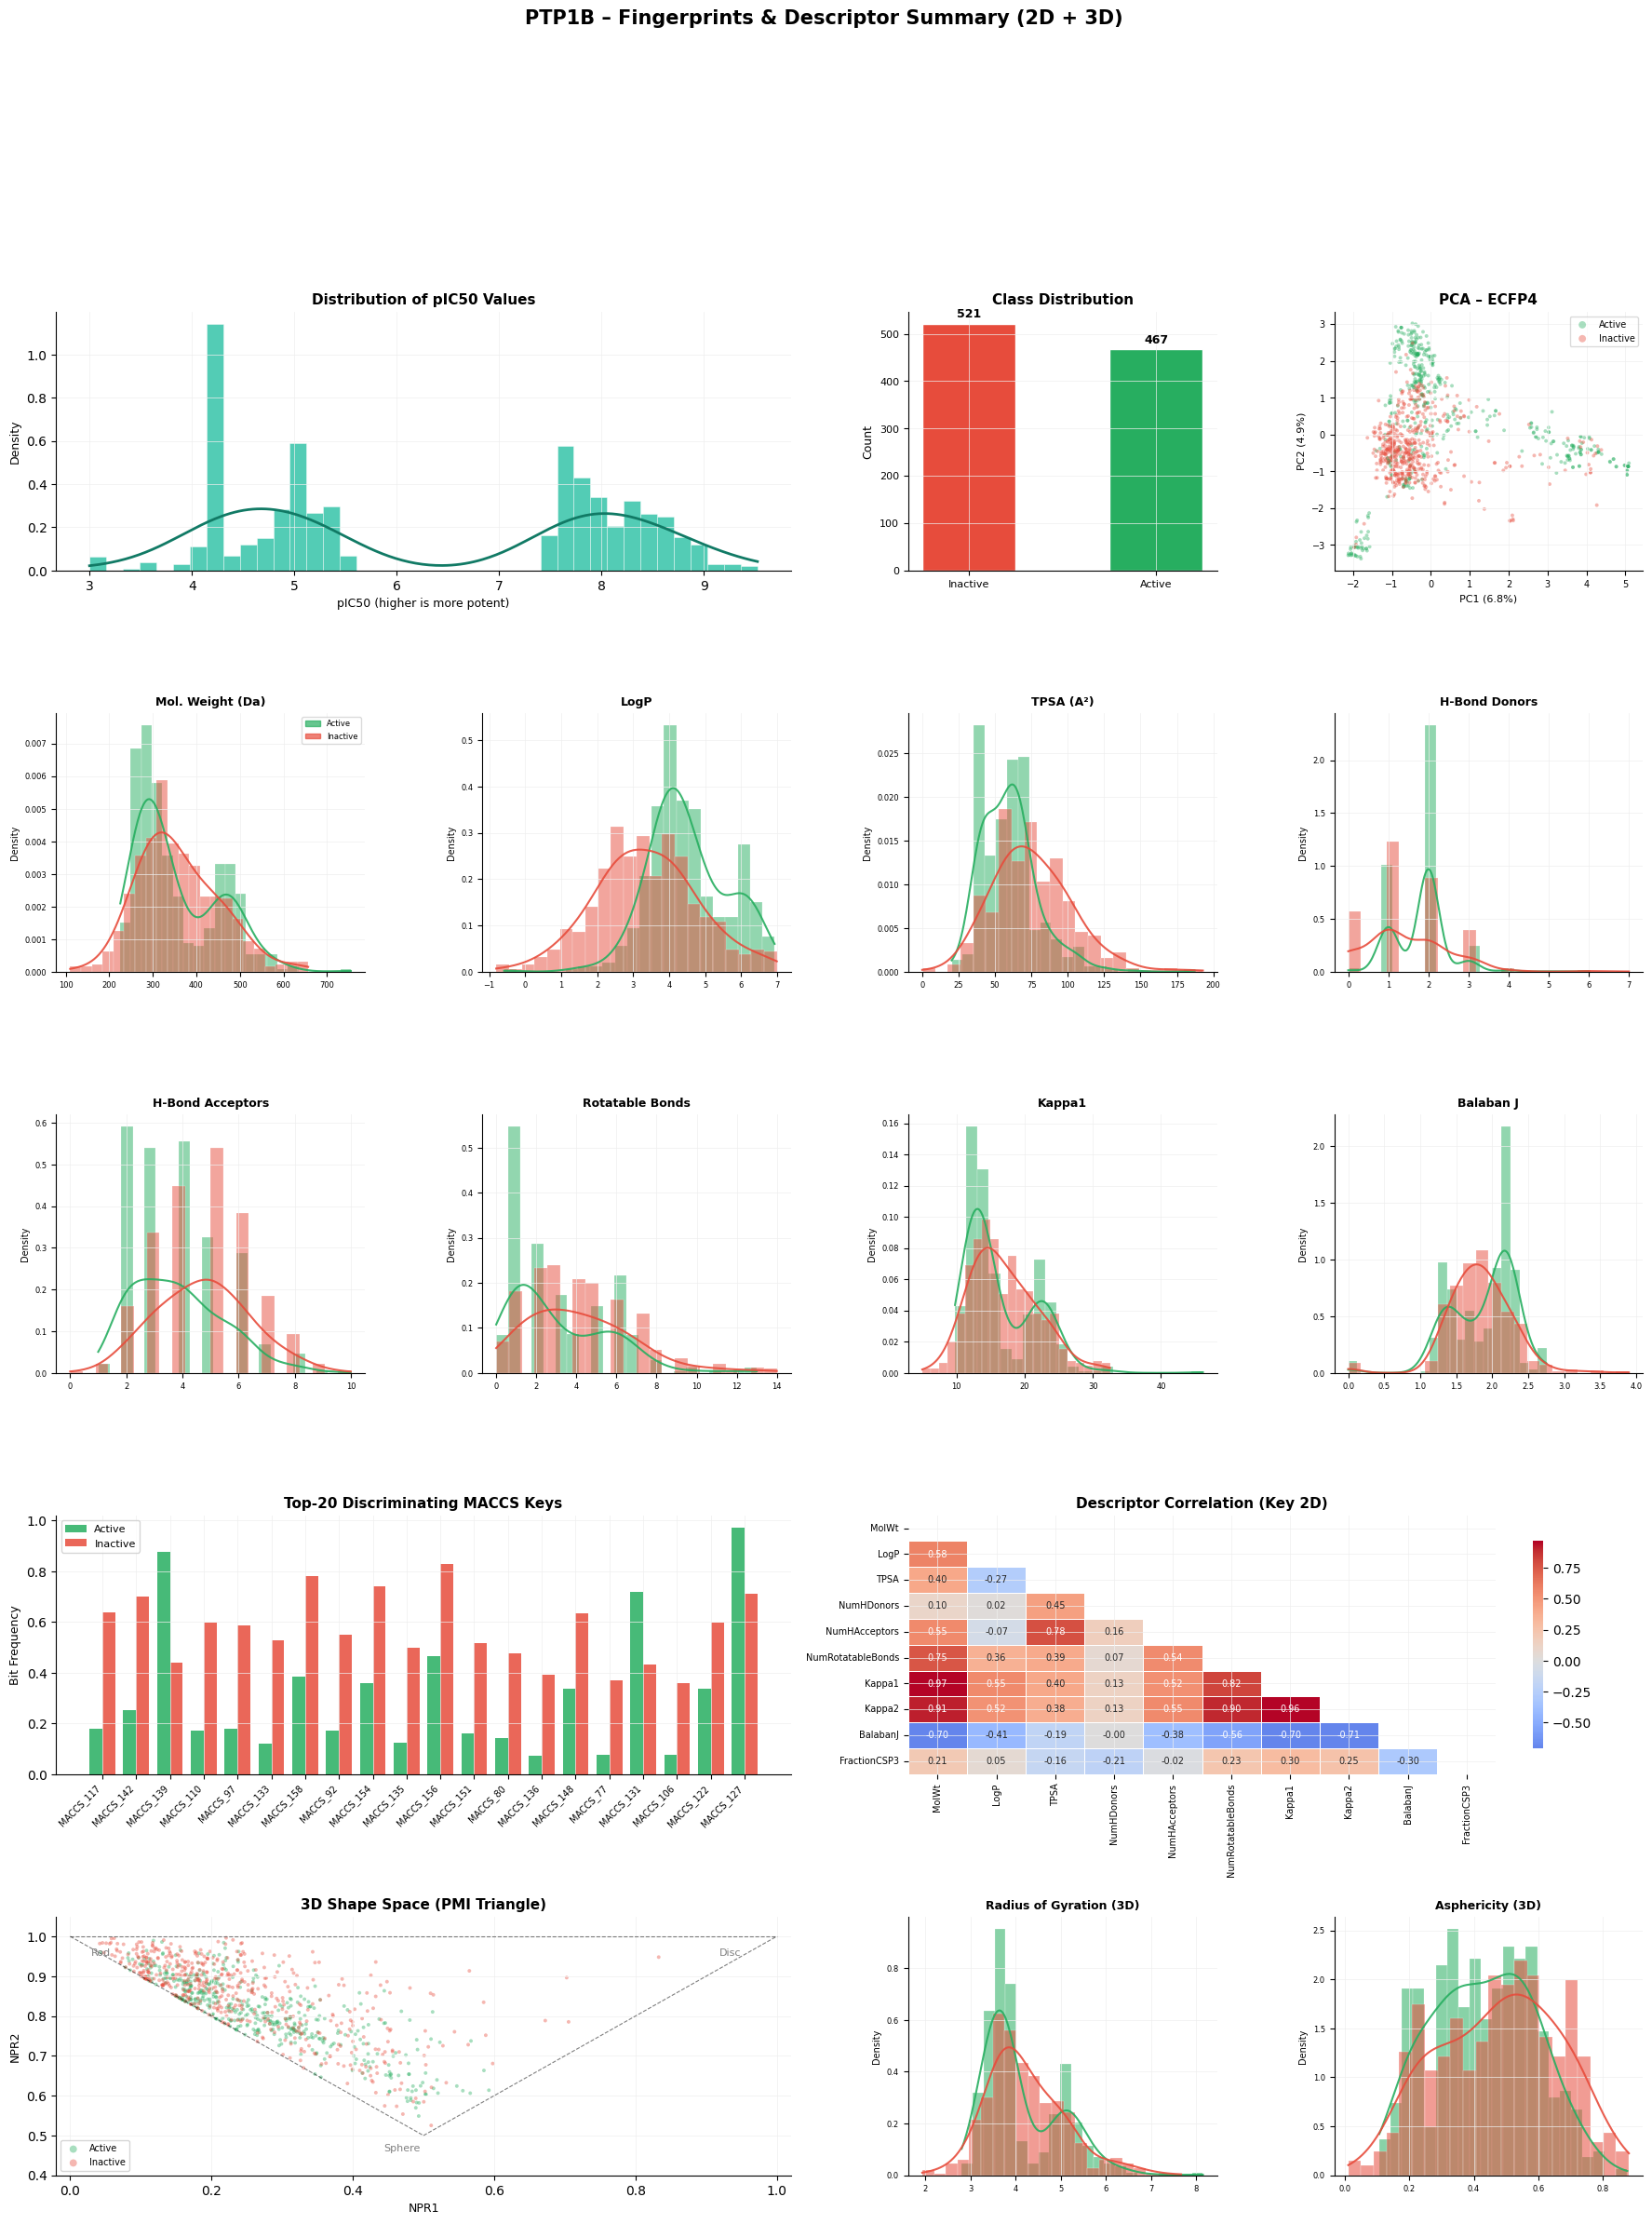

Composite figure saved to: /Users/abbaskhan/Desktop/ESR_beta_new/ESRB_descriptor_summary.png
Done. All descriptors and fingerprints computed for 988 compounds.


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys, AllChem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────────────────────────────────────
BASE       = "/Users/abbaskhan/Desktop/ESR_beta_new/"
DATA_PATH  = BASE + "esrbetsa_raw_clean_1.csv"
SAVE_DESC  = BASE + "ESRB_descriptors_full.csv"
SAVE_ECFP4 = BASE + "ESRB_ecfp4.csv"
SAVE_ECFP6 = BASE + "ESRB_ecfp6.csv"
SAVE_MACCS = BASE + "ESRB_maccs.csv"
SAVE_RDKIT = BASE + "ESRB_rdkitfp.csv"
SAVE_FIG   = BASE + "ESRB_descriptor_summary.png"

# ─────────────────────────────────────────────────────────────────────────────
# Load & parse SMILES
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df["mol"] = df["Smiles"].apply(lambda s: Chem.MolFromSmiles(s) if isinstance(s, str) else None)
df = df[df["mol"].notna()].reset_index(drop=True)
mols      = df["mol"].tolist()
label_col = df["Bioactivity_Class"].reset_index(drop=True)
print("Molecules:", len(df))

# ═════════════════════════════════════════════════════════════════════════════
# FINGERPRINTS
# ═════════════════════════════════════════════════════════════════════════════
def fp_arr(fp, n):
    a = np.zeros(n, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, a)
    return a

# ECFP4 – Morgan radius=2, 2048 bits
gen4      = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
ecfp4_mat = np.vstack([fp_arr(gen4.GetFingerprint(m), 2048) for m in mols])
df_ecfp4  = pd.DataFrame(ecfp4_mat, columns=["ECFP4_"+str(i) for i in range(2048)])
print("ECFP4   :", df_ecfp4.shape)

# ECFP6 – Morgan radius=3, 2048 bits
gen6      = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
ecfp6_mat = np.vstack([fp_arr(gen6.GetFingerprint(m), 2048) for m in mols])
df_ecfp6  = pd.DataFrame(ecfp6_mat, columns=["ECFP6_"+str(i) for i in range(2048)])
print("ECFP6   :", df_ecfp6.shape)

# MACCS keys – 166 bits
def maccs_arr(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)
    a  = np.zeros(167, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, a)
    return a[1:]

maccs_mat = np.vstack([maccs_arr(m) for m in mols])
df_maccs  = pd.DataFrame(maccs_mat, columns=["MACCS_"+str(i) for i in range(1, 167)])
print("MACCS   :", df_maccs.shape)

# RDKit Topological FP – path-based, 2048 bits
genR      = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=7, fpSize=2048)
rdkit_mat = np.vstack([fp_arr(genR.GetFingerprint(m), 2048) for m in mols])
df_rdkit  = pd.DataFrame(rdkit_mat, columns=["RDKit_"+str(i) for i in range(2048)])
print("RDKit FP:", df_rdkit.shape)

# ═════════════════════════════════════════════════════════════════════════════
# 2D DESCRIPTORS
# ═════════════════════════════════════════════════════════════════════════════
def calc_2d(mol):
    return {
        # ── Basic physicochemical ───────────────────────────────────────────
        "MolWt"             : Descriptors.MolWt(mol),
        "LogP"              : Descriptors.MolLogP(mol),
        "TPSA"              : rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors"        : rdMolDescriptors.CalcNumHBD(mol),
        "NumHAcceptors"     : rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds" : rdMolDescriptors.CalcNumRotatableBonds(mol),
        "NumAromaticRings"  : rdMolDescriptors.CalcNumAromaticRings(mol),
        "RingCount"         : rdMolDescriptors.CalcNumRings(mol),
        "FractionCSP3"      : rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount"    : mol.GetNumHeavyAtoms(),
        # ── Connectivity indices ────────────────────────────────────────────
        "Chi0"              : Descriptors.Chi0n(mol),
        "Chi1"              : Descriptors.Chi1n(mol),
        "Chi2"              : Descriptors.Chi2n(mol),
        "Chi3"              : Descriptors.Chi3n(mol),
        "Chi4"              : Descriptors.Chi4n(mol),
        # ── Shape indices ───────────────────────────────────────────────────
        "Kappa1"            : Descriptors.Kappa1(mol),
        "Kappa2"            : Descriptors.Kappa2(mol),
        "Kappa3"            : Descriptors.Kappa3(mol),
        # ── Topological ─────────────────────────────────────────────────────
        "BalabanJ"          : Descriptors.BalabanJ(mol),
        # ── EState VSA ──────────────────────────────────────────────────────
        "EState_VSA1"       : Descriptors.EState_VSA1(mol),
        "EState_VSA2"       : Descriptors.EState_VSA2(mol),
        "EState_VSA3"       : Descriptors.EState_VSA3(mol),
        "EState_VSA4"       : Descriptors.EState_VSA4(mol),
        "EState_VSA5"       : Descriptors.EState_VSA5(mol),
        "EState_VSA6"       : Descriptors.EState_VSA6(mol),
        "EState_VSA7"       : Descriptors.EState_VSA7(mol),
        "EState_VSA8"       : Descriptors.EState_VSA8(mol),
        "EState_VSA9"       : Descriptors.EState_VSA9(mol),
        "EState_VSA10"      : Descriptors.EState_VSA10(mol),
        "EState_VSA11"      : Descriptors.EState_VSA11(mol),
        # ── PEOE VSA ────────────────────────────────────────────────────────
        "PEOE_VSA1"         : Descriptors.PEOE_VSA1(mol),
        "PEOE_VSA2"         : Descriptors.PEOE_VSA2(mol),
        "PEOE_VSA3"         : Descriptors.PEOE_VSA3(mol),
        "PEOE_VSA4"         : Descriptors.PEOE_VSA4(mol),
        "PEOE_VSA5"         : Descriptors.PEOE_VSA5(mol),
        "PEOE_VSA6"         : Descriptors.PEOE_VSA6(mol),
        "PEOE_VSA7"         : Descriptors.PEOE_VSA7(mol),
        "PEOE_VSA8"         : Descriptors.PEOE_VSA8(mol),
        "PEOE_VSA9"         : Descriptors.PEOE_VSA9(mol),
        "PEOE_VSA10"        : Descriptors.PEOE_VSA10(mol),
        "PEOE_VSA11"        : Descriptors.PEOE_VSA11(mol),
        "PEOE_VSA12"        : Descriptors.PEOE_VSA12(mol),
        "PEOE_VSA13"        : Descriptors.PEOE_VSA13(mol),
        "PEOE_VSA14"        : Descriptors.PEOE_VSA14(mol),
    }

df_2d = pd.DataFrame([calc_2d(m) for m in mols])
print("2D descriptors:", df_2d.shape)

# ═════════════════════════════════════════════════════════════════════════════
# 3D DESCRIPTORS  (conformer generation required)
# ═════════════════════════════════════════════════════════════════════════════
_3D_KEYS = ["PMI1","PMI2","PMI3","NPR1","NPR2",
            "RadiusOfGyration","Asphericity","Eccentricity",
            "InertialShapeFactor","SpherocityIndex"]
_NAN_3D  = {k: np.nan for k in _3D_KEYS}

def calc_3d(mol):
    try:
        mh = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(mh, AllChem.ETKDGv3()) == -1:
            return _NAN_3D.copy()
        AllChem.MMFFOptimizeMolecule(mh)
        return {
            "PMI1"               : rdMolDescriptors.CalcPMI1(mh),
            "PMI2"               : rdMolDescriptors.CalcPMI2(mh),
            "PMI3"               : rdMolDescriptors.CalcPMI3(mh),
            "NPR1"               : rdMolDescriptors.CalcNPR1(mh),
            "NPR2"               : rdMolDescriptors.CalcNPR2(mh),
            "RadiusOfGyration"   : rdMolDescriptors.CalcRadiusOfGyration(mh),
            "Asphericity"        : rdMolDescriptors.CalcAsphericity(mh),
            "Eccentricity"       : rdMolDescriptors.CalcEccentricity(mh),
            "InertialShapeFactor": rdMolDescriptors.CalcInertialShapeFactor(mh),
            "SpherocityIndex"    : rdMolDescriptors.CalcSpherocityIndex(mh),
        }
    except Exception:
        return _NAN_3D.copy()

print("Generating 3D conformers (ETKDG v3 + MMFF) – takes ~2-3 min ...")
df_3d    = pd.DataFrame([calc_3d(m) for m in mols])
n_fail   = df_3d.isna().any(axis=1).sum()
print("3D descriptors:", df_3d.shape, " |", n_fail, "conformer failures (set to NaN)")

# ═════════════════════════════════════════════════════════════════════════════
# SAVE ALL FEATURE MATRICES
# ═════════════════════════════════════════════════════════════════════════════
meta = df[["Molecule ChEMBL ID","Smiles","pIC50","Bioactivity_Class","Label"]].reset_index(drop=True)

pd.concat([meta, df_2d, df_3d], axis=1).to_csv(SAVE_DESC,  index=False)
pd.concat([meta, df_ecfp4],     axis=1).to_csv(SAVE_ECFP4, index=False)
pd.concat([meta, df_ecfp6],     axis=1).to_csv(SAVE_ECFP6, index=False)
pd.concat([meta, df_maccs],     axis=1).to_csv(SAVE_MACCS, index=False)
pd.concat([meta, df_rdkit],     axis=1).to_csv(SAVE_RDKIT, index=False)
print("Saved: descriptors (2D+3D), ECFP4, ECFP6, MACCS, RDKit FP")

# ═════════════════════════════════════════════════════════════════════════════
# COMPOSITE FIGURE
# ═════════════════════════════════════════════════════════════════════════════
TEAL    = "#1ABC9C"
TEAL_DK = "#117A65"
GREEN   = "#27AE60"
RED     = "#E74C3C"
PALETTE = {"Active": GREEN, "Inactive": RED}

plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.color"        : "#EEEEEE",
    "grid.linewidth"    : 0.5,
    "font.family"       : "sans-serif",
    "xtick.direction"   : "out",
    "ytick.direction"   : "out",
})

fig = plt.figure(figsize=(22, 26))
gs  = gridspec.GridSpec(5, 4, figure=fig, hspace=0.55, wspace=0.38)

# ── Row 0 ────────────────────────────────────────────────────────────────────
# [A] pIC50 distribution (teal, KDE) – spans cols 0-1
ax_a = fig.add_subplot(gs[0, 0:2])
pic  = df["pIC50"].dropna()
ax_a.hist(pic, bins=40, color=TEAL, alpha=0.75, density=True,
          edgecolor="white", linewidth=0.4)
kx = np.linspace(pic.min(), pic.max(), 300)
ax_a.plot(kx, stats.gaussian_kde(pic, bw_method=0.3)(kx), color=TEAL_DK, lw=2)
ax_a.set_xlabel("pIC50 (higher is more potent)", fontsize=9)
ax_a.set_ylabel("Density", fontsize=9)
ax_a.set_title("Distribution of pIC50 Values", fontsize=11, fontweight="bold")

# [B] Class balance bar – col 2
ax_b  = fig.add_subplot(gs[0, 2])
cnts  = df["Bioactivity_Class"].value_counts()
bars  = ax_b.bar(cnts.index, cnts.values,
                  color=[PALETTE[c] for c in cnts.index],
                  edgecolor="white", width=0.5)
for bar, v in zip(bars, cnts.values):
    ax_b.text(bar.get_x() + bar.get_width()/2, v + 8, str(v),
              ha="center", va="bottom", fontsize=9, fontweight="bold")
ax_b.set_title("Class Distribution", fontsize=11, fontweight="bold")
ax_b.set_ylabel("Count", fontsize=9)
ax_b.tick_params(labelsize=8)

# [C] PCA of ECFP4 – col 3
ax_c   = fig.add_subplot(gs[0, 3])
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(ecfp4_mat)
var    = pca.explained_variance_ratio_ * 100
for cls, color in PALETTE.items():
    mask = label_col.values == cls
    ax_c.scatter(coords[mask, 0], coords[mask, 1],
                 c=color, label=cls, alpha=0.40, s=8, edgecolors="none")
ax_c.set_xlabel("PC1 (" + f"{var[0]:.1f}" + "%)", fontsize=8)
ax_c.set_ylabel("PC2 (" + f"{var[1]:.1f}" + "%)", fontsize=8)
ax_c.set_title("PCA – ECFP4", fontsize=11, fontweight="bold")
ax_c.legend(fontsize=7, markerscale=2, framealpha=0.7)
ax_c.tick_params(labelsize=7)

# ── Rows 1–2: 8 key 2D descriptor histograms w/ KDE ─────────────────────────
DESC_PANELS = [
    ("MolWt",            "Mol. Weight (Da)",    (1, 0)),
    ("LogP",             "LogP",                (1, 1)),
    ("TPSA",             "TPSA (A²)",           (1, 2)),
    ("NumHDonors",       "H-Bond Donors",       (1, 3)),
    ("NumHAcceptors",    "H-Bond Acceptors",    (2, 0)),
    ("NumRotatableBonds","Rotatable Bonds",     (2, 1)),
    ("Kappa1",           "Kappa1",              (2, 2)),
    ("BalabanJ",         "Balaban J",           (2, 3)),
]
for col, label, (r, c) in DESC_PANELS:
    ax = fig.add_subplot(gs[r, c])
    for cls, color in PALETTE.items():
        vals = df_2d.loc[label_col == cls, col].dropna()
        ax.hist(vals, bins=22, alpha=0.50, color=color, density=True,
                label=cls, edgecolor="white", linewidth=0.3)
        if len(vals) > 2 and vals.std() > 0:
            xr = np.linspace(vals.min(), vals.max(), 200)
            ax.plot(xr, stats.gaussian_kde(vals, bw_method=0.4)(xr),
                    color=color, lw=1.5, alpha=0.9)
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_ylabel("Density", fontsize=7)
    ax.tick_params(labelsize=6)
    if (r, c) == (1, 0):
        handles = [plt.Rectangle((0,0),1,1, color=v, alpha=0.7)
                   for v in PALETTE.values()]
        ax.legend(handles, list(PALETTE.keys()), fontsize=6,
                  loc="upper right", framealpha=0.7)

# ── Row 3 left: Top-20 discriminating MACCS bits ─────────────────────────────
ax_mac = fig.add_subplot(gs[3, 0:2])
fa     = df_maccs[label_col == "Active"].mean()
fi     = df_maccs[label_col == "Inactive"].mean()
top20  = (fa - fi).abs().sort_values(ascending=False).head(20).index.tolist()
xm, wm = np.arange(len(top20)), 0.38
ax_mac.bar(xm - wm/2, fa[top20], width=wm, color=GREEN, alpha=0.85, label="Active")
ax_mac.bar(xm + wm/2, fi[top20], width=wm, color=RED,   alpha=0.85, label="Inactive")
ax_mac.set_xticks(xm)
ax_mac.set_xticklabels(top20, rotation=45, ha="right", fontsize=7)
ax_mac.set_ylabel("Bit Frequency", fontsize=9)
ax_mac.set_title("Top-20 Discriminating MACCS Keys", fontsize=11, fontweight="bold")
ax_mac.legend(fontsize=8)

# ── Row 3 right: Descriptor correlation heatmap ───────────────────────────────
ax_cor = fig.add_subplot(gs[3, 2:4])
core   = ["MolWt","LogP","TPSA","NumHDonors","NumHAcceptors",
          "NumRotatableBonds","Kappa1","Kappa2","BalabanJ","FractionCSP3"]
corr   = df_2d[core].corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, annot_kws={"size": 7},
            ax=ax_cor, cbar_kws={"shrink": 0.8})
ax_cor.set_title("Descriptor Correlation (Key 2D)", fontsize=11, fontweight="bold")
ax_cor.tick_params(labelsize=7)

# ── Row 4: 3D descriptor visualisations ──────────────────────────────────────
df_3d_valid = df_3d.dropna()
lbl_3d      = label_col[df_3d.index[df_3d.notna().all(axis=1)]]

# [NPR1 vs NPR2] shape-space triangle
ax_npm = fig.add_subplot(gs[4, 0:2])
for cls, color in PALETTE.items():
    m3 = lbl_3d == cls
    ax_npm.scatter(df_3d_valid.loc[m3.index[m3], "NPR1"],
                   df_3d_valid.loc[m3.index[m3], "NPR2"],
                   c=color, label=cls, alpha=0.40, s=8, edgecolors="none")
# Shape triangle boundaries
ax_npm.plot([0, 0.5], [1, 0.5], "k--", lw=0.8, alpha=0.5)
ax_npm.plot([0.5, 1], [0.5, 1], "k--", lw=0.8, alpha=0.5)
ax_npm.plot([0, 1],   [1, 1],   "k--", lw=0.8, alpha=0.5)
ax_npm.text(0.03, 0.97, "Rod",   fontsize=8, color="gray", va="top")
ax_npm.text(0.47, 0.48, "Sphere",fontsize=8, color="gray", va="top", ha="center")
ax_npm.text(0.95, 0.97, "Disc",  fontsize=8, color="gray", va="top", ha="right")
ax_npm.set_xlabel("NPR1", fontsize=9)
ax_npm.set_ylabel("NPR2", fontsize=9)
ax_npm.set_title("3D Shape Space (PMI Triangle)", fontsize=11, fontweight="bold")
ax_npm.legend(fontsize=7, markerscale=2)
ax_npm.set_xlim(-0.02, 1.02)
ax_npm.set_ylim(0.40, 1.05)

# [RadiusOfGyration] histogram by class
ax_rg = fig.add_subplot(gs[4, 2])
for cls, color in PALETTE.items():
    m3   = lbl_3d == cls
    vals = df_3d_valid.loc[m3.index[m3], "RadiusOfGyration"].dropna()
    ax_rg.hist(vals, bins=22, alpha=0.55, color=color, density=True,
               label=cls, edgecolor="white", linewidth=0.3)
    if len(vals) > 2 and vals.std() > 0:
        xr = np.linspace(vals.min(), vals.max(), 200)
        ax_rg.plot(xr, stats.gaussian_kde(vals, bw_method=0.4)(xr),
                   color=color, lw=1.5, alpha=0.9)
ax_rg.set_title("Radius of Gyration (3D)", fontsize=9, fontweight="bold")
ax_rg.set_ylabel("Density", fontsize=7)
ax_rg.tick_params(labelsize=6)

# [Asphericity] histogram by class
ax_as = fig.add_subplot(gs[4, 3])
for cls, color in PALETTE.items():
    m3   = lbl_3d == cls
    vals = df_3d_valid.loc[m3.index[m3], "Asphericity"].dropna()
    ax_as.hist(vals, bins=22, alpha=0.55, color=color, density=True,
               label=cls, edgecolor="white", linewidth=0.3)
    if len(vals) > 2 and vals.std() > 0:
        xr = np.linspace(vals.min(), vals.max(), 200)
        ax_as.plot(xr, stats.gaussian_kde(vals, bw_method=0.4)(xr),
                   color=color, lw=1.5, alpha=0.9)
ax_as.set_title("Asphericity (3D)", fontsize=9, fontweight="bold")
ax_as.set_ylabel("Density", fontsize=7)
ax_as.tick_params(labelsize=6)

fig.suptitle("PTP1B – Fingerprints & Descriptor Summary (2D + 3D)",
             fontsize=15, fontweight="bold", y=1.005)
plt.savefig(SAVE_FIG, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Composite figure saved to:", SAVE_FIG)
print("Done. All descriptors and fingerprints computed for", len(df), "compounds.")

Loaded: 988 compounds x 54 features
Step 1 | Features with NaN: 0 | Rows affected: 0
Step 2 | NaN remaining after imputation: 0
Step 3 | Zero-variance removed: 0 -> 54 features
Step 4 | Near-zero variance removed: 3 -> 51 features
Step 5 | High-correlation removed: 12 -> 39 features

Preprocessing Summary:


,Step,Features,Features Removed
0,Raw,54,0
1,After Imputation,54,0
2,Zero-Var Removed,54,0
3,Near-Zero Var Removed,51,3
4,High-Corr Removed,39,12


Saved: PTP1B_features_clean.csv ( 988 x 44 )


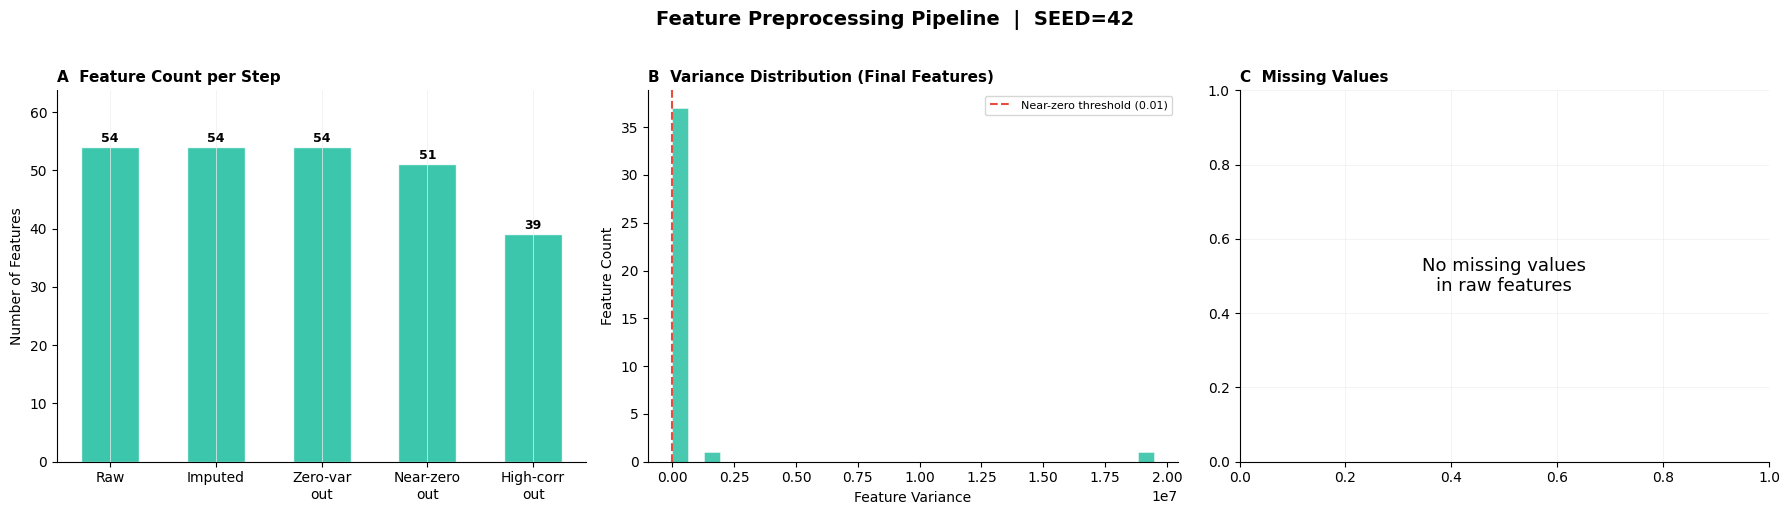

Figure saved: preprocessing_summary.png


In [44]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 11 – Feature Preprocessing
# SEED = 42
# ════════════════════════════════════════════════════════════════════════════
SEED = 42
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from IPython.display import display
warnings.filterwarnings("ignore")
np.random.seed(SEED)

BASE = "/Users/abbaskhan/Desktop/ESR_beta_new/"

# ── Load full descriptor matrix ──────────────────────────────────────────────
df_raw = pd.read_csv(BASE + "ESRB_descriptors_full.csv")
META   = ["Molecule ChEMBL ID", "Smiles", "pIC50", "Bioactivity_Class", "Label"]
meta   = df_raw[META].copy()
X_raw  = df_raw.drop(columns=META)
y      = df_raw["Label"].values
print("Loaded:", X_raw.shape[0], "compounds x", X_raw.shape[1], "features")

# ── Step 1: Missing-value audit ──────────────────────────────────────────────
missing      = X_raw.isnull().sum()
n_miss_feats = (missing > 0).sum()
n_miss_rows  = X_raw.isnull().any(axis=1).sum()
print("Step 1 | Features with NaN:", n_miss_feats, "| Rows affected:", n_miss_rows)

# ── Step 2: Median imputation ────────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")
X_imp   = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
print("Step 2 | NaN remaining after imputation:", X_imp.isnull().sum().sum())

# ── Step 3: Remove zero-variance features ───────────────────────────────────
sel_var   = VarianceThreshold(threshold=0.0)
sel_var.fit(X_imp)
cols_var  = X_imp.columns[sel_var.get_support()].tolist()
n_rm_zero = X_imp.shape[1] - len(cols_var)
X_var     = X_imp[cols_var]
print("Step 3 | Zero-variance removed:", n_rm_zero, "->", X_var.shape[1], "features")

# ── Step 4: Remove near-zero variance (variance < 0.01) ─────────────────────
variances = X_var.var()
nzv_cols  = variances[variances < 0.01].index.tolist()
X_nzv     = X_var.drop(columns=nzv_cols)
print("Step 4 | Near-zero variance removed:", len(nzv_cols), "->", X_nzv.shape[1], "features")

# ── Step 5: Remove highly correlated features (|r| > 0.95) ─────────────────
corr_mat  = X_nzv.corr().abs()
upper_tri = corr_mat.where(np.triu(np.ones_like(corr_mat, dtype=bool), k=1))
drop_corr = [c for c in upper_tri.columns if (upper_tri[c] > 0.95).any()]
X_clean   = X_nzv.drop(columns=drop_corr)
print("Step 5 | High-correlation removed:", len(drop_corr), "->", X_clean.shape[1], "features")

# ── Summary table ────────────────────────────────────────────────────────────
steps_tbl = pd.DataFrame({
    "Step"            : ["Raw", "After Imputation", "Zero-Var Removed",
                         "Near-Zero Var Removed", "High-Corr Removed"],
    "Features"        : [X_raw.shape[1], X_imp.shape[1], X_var.shape[1],
                         X_nzv.shape[1], X_clean.shape[1]],
    "Features Removed": [0, 0, n_rm_zero, len(nzv_cols), len(drop_corr)],
})
print("\nPreprocessing Summary:")
display(steps_tbl)

# ── Save clean feature matrix ────────────────────────────────────────────────
df_clean = pd.concat([meta.reset_index(drop=True),
                      X_clean.reset_index(drop=True)], axis=1)
df_clean.to_csv(BASE + "PTP1B_features_clean.csv", index=False)
print("Saved: PTP1B_features_clean.csv (", len(df_clean), "x", len(df_clean.columns), ")")

# ── Composite figure ─────────────────────────────────────────────────────────
TEAL = "#1ABC9C"; RED = "#E74C3C"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "grid.color": "#EEEEEE", "grid.linewidth": 0.5})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("white")

# A – Feature count per step
ax     = axes[0]
labels = ["Raw", "Imputed", "Zero-var\nout", "Near-zero\nout", "High-corr\nout"]
counts = [X_raw.shape[1], X_imp.shape[1], X_var.shape[1],
          X_nzv.shape[1], X_clean.shape[1]]
bars = ax.bar(labels, counts, color=TEAL, edgecolor="white", alpha=0.85, width=0.55)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4, str(v),
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Number of Features", fontsize=10)
ax.set_title("A  Feature Count per Step", fontsize=11, fontweight="bold", loc="left")
ax.set_ylim(0, max(counts) * 1.18)
ax.grid(axis="y")

# B – Final feature variance distribution
ax       = axes[1]
var_vals = X_clean.var().sort_values()
ax.hist(var_vals, bins=30, color=TEAL, alpha=0.80, edgecolor="white", linewidth=0.4)
ax.axvline(0.01, color=RED, lw=1.5, ls="--", label="Near-zero threshold (0.01)")
ax.set_xlabel("Feature Variance", fontsize=10)
ax.set_ylabel("Feature Count", fontsize=10)
ax.set_title("B  Variance Distribution (Final Features)", fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=8)
ax.grid()

# C – Missing-value count (top 15 features)
ax       = axes[2]
top_miss = missing.sort_values(ascending=False).head(15)
if top_miss.max() > 0:
    bar_colors = [RED if v > 0 else TEAL for v in top_miss.values]
    ax.barh(range(len(top_miss)), top_miss.values,
            color=bar_colors, edgecolor="white", alpha=0.85)
    ax.set_yticks(range(len(top_miss)))
    ax.set_yticklabels(top_miss.index, fontsize=7)
    ax.set_xlabel("Missing Count", fontsize=10)
    ax.set_title("C  Top Features by Missing Count",
                 fontsize=11, fontweight="bold", loc="left")
    ax.grid(axis="x")
else:
    ax.text(0.5, 0.5, "No missing values\nin raw features",
            ha="center", va="center", fontsize=13, transform=ax.transAxes)
    ax.set_title("C  Missing Values", fontsize=11, fontweight="bold", loc="left")

fig.suptitle("Feature Preprocessing Pipeline  |  SEED=" + str(SEED),
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(BASE + "preprocessing_summary.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figure saved: preprocessing_summary.png")


Dataset: 1699 compounds

Bemis-Murcko Scaffold Statistics:


,Metric,Value
0,Total compounds,1699
1,Unique scaffolds,737
2,Scaffold diversity (unique/total),0.4338
3,Singleton scaffolds (1 compound),571 (77.5% of unique)
4,Top-10 scaffold coverage,382 (22.5% of total)
5,No-scaffold compounds,1


Saved: PTP1B_with_scaffolds.csv


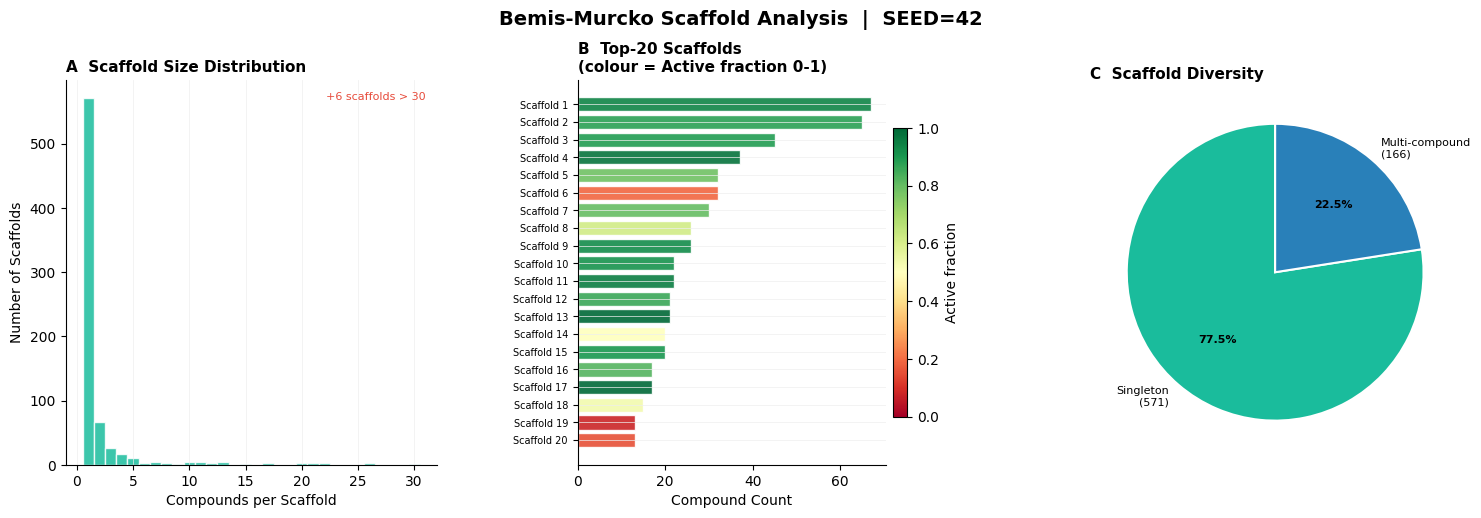

Figure saved: scaffold_analysis.png


In [45]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 12 – Bemis–Murcko Scaffold Extraction
# SEED = 42
# ════════════════════════════════════════════════════════════════════════════
SEED = 42
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import display
warnings.filterwarnings("ignore")
np.random.seed(SEED)

BASE = "/Users/abbaskhan/Desktop/ESR_beta_new/"
df   = pd.read_csv(BASE + "ESRB_ML_ready.csv")
print("Dataset:", len(df), "compounds")

# ── Extract Bemis–Murcko scaffolds ───────────────────────────────────────────
def get_bm_scaffold(smiles, chirality=False):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "[NO_SCAFFOLD]"
    try:
        sc = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=chirality)
        return sc if sc else "[NO_SCAFFOLD]"
    except Exception:
        return "[NO_SCAFFOLD]"

df["Scaffold"] = df["Smiles"].apply(get_bm_scaffold)

scaffold_counts  = df["Scaffold"].value_counts()
n_unique         = df["Scaffold"].nunique()
n_singleton      = (scaffold_counts == 1).sum()
n_top10_coverage = scaffold_counts.head(10).sum()
n_no_scaffold    = (df["Scaffold"] == "[NO_SCAFFOLD]").sum()

# ── Scaffold summary table ───────────────────────────────────────────────────
summary_tbl = pd.DataFrame({
    "Metric": [
        "Total compounds",
        "Unique scaffolds",
        "Scaffold diversity (unique/total)",
        "Singleton scaffolds (1 compound)",
        "Top-10 scaffold coverage",
        "No-scaffold compounds",
    ],
    "Value": [
        len(df),
        n_unique,
        round(n_unique / len(df), 4),
        str(n_singleton) + "  (" + f"{100*n_singleton/n_unique:.1f}" + "% of unique)",
        str(n_top10_coverage) + "  (" + f"{100*n_top10_coverage/len(df):.1f}" + "% of total)",
        n_no_scaffold,
    ],
})
print("\nBemis-Murcko Scaffold Statistics:")
display(summary_tbl)

# ── Per-scaffold class distribution ─────────────────────────────────────────
scaffold_cls = df.groupby("Scaffold")["Bioactivity_Class"].value_counts().unstack(fill_value=0)
scaffold_cls["Total"]       = scaffold_cls.sum(axis=1)
scaffold_cls["Active_frac"] = scaffold_cls.get("Active", 0) / scaffold_cls["Total"]
scaffold_cls = scaffold_cls.sort_values("Total", ascending=False)

# ── Save scaffold-annotated dataset ─────────────────────────────────────────
df.to_csv(BASE + "PTP1B_with_scaffolds.csv", index=False)
print("Saved: PTP1B_with_scaffolds.csv")

# ── Composite figure ─────────────────────────────────────────────────────────
TEAL = "#1ABC9C"; RED = "#E74C3C"; BLUE = "#2980B9"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "grid.color": "#EEEEEE", "grid.linewidth": 0.5})

fig = plt.figure(figsize=(18, 5))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# A – Scaffold size distribution
ax    = fig.add_subplot(gs[0])
sizes = scaffold_counts.values
cap   = 30
ax.hist(sizes[sizes <= cap], bins=np.arange(0.5, cap + 1.5, 1),
        color=TEAL, edgecolor="white", alpha=0.85)
n_large = (sizes > cap).sum()
if n_large:
    ax.text(0.97, 0.97, "+" + str(n_large) + " scaffolds > " + str(cap),
            transform=ax.transAxes, ha="right", va="top", fontsize=8, color=RED)
ax.set_xlabel("Compounds per Scaffold", fontsize=10)
ax.set_ylabel("Number of Scaffolds", fontsize=10)
ax.set_title("A  Scaffold Size Distribution", fontsize=11, fontweight="bold", loc="left")
ax.grid(axis="y")

# B – Top-20 scaffolds coloured by Active fraction
ax        = fig.add_subplot(gs[1])
top20     = scaffold_cls.head(20)
act_fracs = top20["Active_frac"].values
bar_cols  = [plt.cm.RdYlGn(f) for f in act_fracs]
ax.barh(range(len(top20)), top20["Total"].values,
        color=bar_cols, edgecolor="white", alpha=0.9)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(["Scaffold " + str(i+1) for i in range(len(top20))], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Compound Count", fontsize=10)
ax.set_title("B  Top-20 Scaffolds\n(colour = Active fraction 0-1)",
             fontsize=11, fontweight="bold", loc="left")
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Active fraction", shrink=0.75, pad=0.02)
ax.grid(axis="x")

# C – Singleton vs multi-compound pie
ax      = fig.add_subplot(gs[2])
n_multi = n_unique - n_singleton
labels_pie = [
    "Singleton\n(" + str(n_singleton) + ")",
    "Multi-compound\n(" + str(n_multi) + ")",
]
wedges, texts, autotexts = ax.pie(
    [n_singleton, n_multi],
    labels=labels_pie,
    colors=[TEAL, BLUE],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 8},
)
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title("C  Scaffold Diversity", fontsize=11, fontweight="bold", loc="left")

fig.suptitle("Bemis-Murcko Scaffold Analysis  |  SEED=" + str(SEED),
             fontsize=14, fontweight="bold", y=1.02)
plt.savefig(BASE + "scaffold_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figure saved: scaffold_analysis.png")

Dataset: 1699 compounds | 737 unique scaffolds
Scaffold disjointness verified – 0 shared scaffolds between train and test.

Split Statistics:


,Split,N,Active,Inactive,Active %,Unique Scaffolds,Frac of Total
0,Full,1699,900,799,53.0%,737,100.0%
1,Train,1360,697,663,51.2%,610,80.0%
2,Test,339,203,136,59.9%,127,20.0%


Saved: PTP1B_train.csv  |  PTP1B_test.csv  |  train_idx.npy  |  test_idx.npy


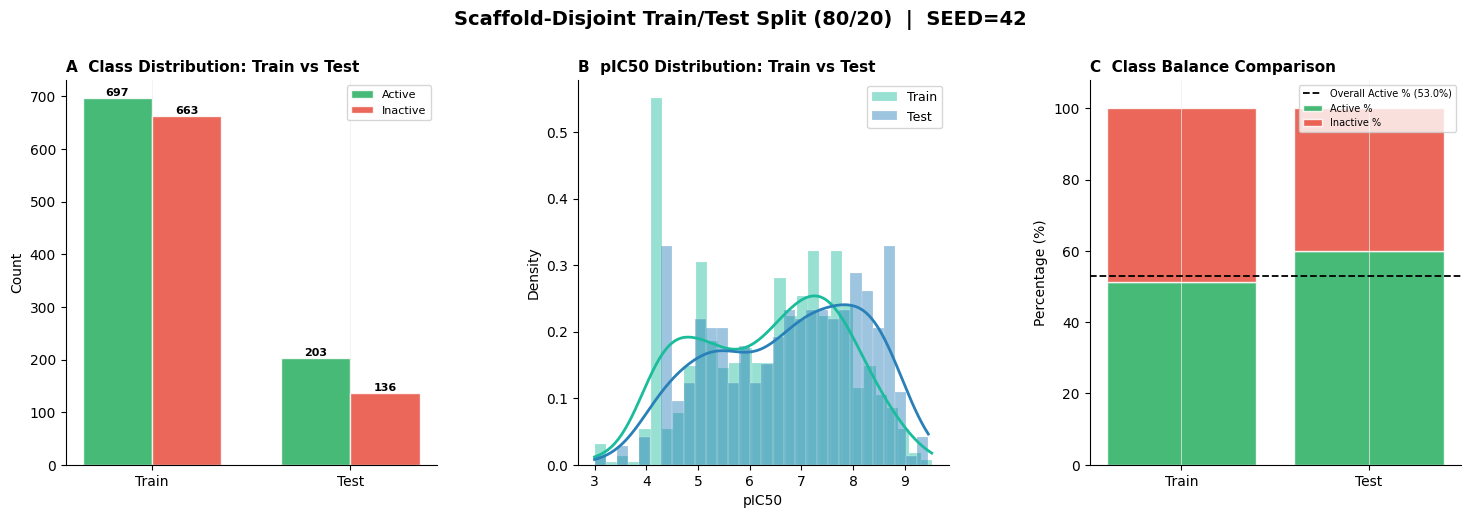

Figure saved: scaffold_split.png


In [46]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 13 – Scaffold-Disjoint Train/Test Split  (80/20)
# SEED = 42  |  TEST_FRAC = 0.20
# ════════════════════════════════════════════════════════════════════════════
SEED      = 42
TEST_FRAC = 0.20

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import warnings
from collections import defaultdict
from scipy import stats as scipy_stats
from IPython.display import display
warnings.filterwarnings("ignore")

random.seed(SEED)
np.random.seed(SEED)

BASE = "/Users/abbaskhan/Desktop/ESR_beta_new/"
df   = pd.read_csv(BASE + "ESRB_with_scaffolds.csv")
print("Dataset:", len(df), "compounds |", df["Scaffold"].nunique(), "unique scaffolds")

# ── Build scaffold -> index mapping ─────────────────────────────────────────
scaffold_to_idx = defaultdict(list)
for i, row in df.iterrows():
    scaffold_to_idx[row["Scaffold"]].append(i)

# ── Shuffle scaffold groups (reproducible via SEED) ──────────────────────────
scaffold_groups = list(scaffold_to_idx.items())
random.shuffle(scaffold_groups)

# ── Greedy scaffold-disjoint split ───────────────────────────────────────────
# Each scaffold goes entirely to train OR test – no scaffold spans both sets.
n_total       = len(df)
n_test_target = int(n_total * TEST_FRAC)

train_idx, test_idx = [], []
for scaffold, indices in scaffold_groups:
    if len(test_idx) + len(indices) <= n_test_target:
        test_idx.extend(indices)
    else:
        train_idx.extend(indices)

train_idx = sorted(train_idx)
test_idx  = sorted(test_idx)

# ── Verify zero scaffold overlap (no data leakage) ──────────────────────────
train_scaffolds = set(df.loc[train_idx, "Scaffold"])
test_scaffolds  = set(df.loc[test_idx,  "Scaffold"])
overlap = train_scaffolds & test_scaffolds
assert len(overlap) == 0, "LEAKAGE: scaffold(s) in both train and test!"
print("Scaffold disjointness verified – 0 shared scaffolds between train and test.")

df_train = df.loc[train_idx].reset_index(drop=True)
df_test  = df.loc[test_idx ].reset_index(drop=True)

# ── Split statistics table ───────────────────────────────────────────────────
def split_row(split_df, name):
    n    = len(split_df)
    n_a  = int((split_df["Label"] == 1).sum())
    n_i  = int((split_df["Label"] == 0).sum())
    n_sc = split_df["Scaffold"].nunique()
    return {
        "Split"         : name,
        "N"             : n,
        "Active"        : n_a,
        "Inactive"      : n_i,
        "Active %"      : f"{100*n_a/n:.1f}%",
        "Unique Scaffolds": n_sc,
        "Frac of Total" : f"{100*n/len(df):.1f}%",
    }

split_tbl = pd.DataFrame([
    split_row(df,       "Full"),
    split_row(df_train, "Train"),
    split_row(df_test,  "Test"),
])
print("\nSplit Statistics:")
display(split_tbl)

# ── Save splits ───────────────────────────────────────────────────────────────
df_train.to_csv(BASE + "ESRB_train.csv", index=False)
df_test.to_csv( BASE + "ESRB_test.csv",  index=False)
np.save(BASE + "train_idx.npy", np.array(train_idx))
np.save(BASE + "test_idx.npy",  np.array(test_idx))
print("Saved: PTP1B_train.csv  |  PTP1B_test.csv  |  train_idx.npy  |  test_idx.npy")

# ── Composite figure ─────────────────────────────────────────────────────────
TEAL = "#1ABC9C"; GREEN = "#27AE60"; RED = "#E74C3C"; BLUE = "#2980B9"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "grid.color": "#EEEEEE", "grid.linewidth": 0.5})

fig = plt.figure(figsize=(18, 5))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# A – Class distribution: Train vs Test
ax   = fig.add_subplot(gs[0])
x, w = np.arange(2), 0.35
actives   = [int((df_train["Label"]==1).sum()), int((df_test["Label"]==1).sum())]
inactives = [int((df_train["Label"]==0).sum()), int((df_test["Label"]==0).sum())]
b1 = ax.bar(x - w/2, actives,   width=w, color=GREEN, edgecolor="white",
            alpha=0.85, label="Active")
b2 = ax.bar(x + w/2, inactives, width=w, color=RED,   edgecolor="white",
            alpha=0.85, label="Inactive")
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(int(bar.get_height())), ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["Train", "Test"], fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("A  Class Distribution: Train vs Test",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=8)
ax.grid(axis="y")

# B – pIC50 distribution overlay
ax = fig.add_subplot(gs[1])
for split_df, color, label in [(df_train, TEAL, "Train"), (df_test, BLUE, "Test")]:
    vals = split_df["pIC50"].dropna()
    ax.hist(vals, bins=30, alpha=0.45, color=color, density=True,
            label=label, edgecolor="white", linewidth=0.3)
    xr = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(xr, scipy_stats.gaussian_kde(vals, bw_method=0.35)(xr),
            color=color, lw=2)
ax.set_xlabel("pIC50", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("B  pIC50 Distribution: Train vs Test",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=9)
ax.grid()

# C – Class balance stacked bars
ax      = fig.add_subplot(gs[2])
totals  = [len(df_train), len(df_test)]
act_pct = [100*a/t for a, t in zip(actives, totals)]
ina_pct = [100*i/t for i, t in zip(inactives, totals)]
ax.bar(["Train","Test"], act_pct, color=GREEN, edgecolor="white",
       alpha=0.85, label="Active %")
ax.bar(["Train","Test"], ina_pct, bottom=act_pct, color=RED,
       edgecolor="white", alpha=0.85, label="Inactive %")
overall_act = 100 * int((df["Label"]==1).sum()) / len(df)
ax.axhline(overall_act, color="black", ls="--", lw=1.3,
           label="Overall Active % (" + f"{overall_act:.1f}%" + ")")
ax.set_ylabel("Percentage (%)", fontsize=10)
ax.set_ylim(0, 108)
ax.set_title("C  Class Balance Comparison",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=7, loc="upper right")
ax.grid(axis="y")

fig.suptitle("Scaffold-Disjoint Train/Test Split (80/20)  |  SEED=" + str(SEED),
             fontsize=14, fontweight="bold", y=1.02)
plt.savefig(BASE + "scaffold_split.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figure saved: scaffold_split.png")

Training set: 1360 compounds
Class balance: 697 Active  | 663 Inactive

Stratified 5-Fold CV Statistics:


,Fold,Train N,Train Active,Train Inactive,Train Active %,Val N,Val Active,Val Inactive,Val Active %,Shared Scaffolds
0,1,1088,558,530,51.3%,272,139,133,51.1%,74
1,2,1088,558,530,51.3%,272,139,133,51.1%,72
2,3,1088,558,530,51.3%,272,139,133,51.1%,70
3,4,1088,557,531,51.2%,272,140,132,51.5%,70
4,5,1088,557,531,51.2%,272,140,132,51.5%,81



Note: StratifiedKFold preserves class ratio per fold (label-stratified).
Intra-train scaffold overlap is expected. The final held-out test set
remains fully scaffold-disjoint (see Cell 13).
Saved: cv_fold_indices.json


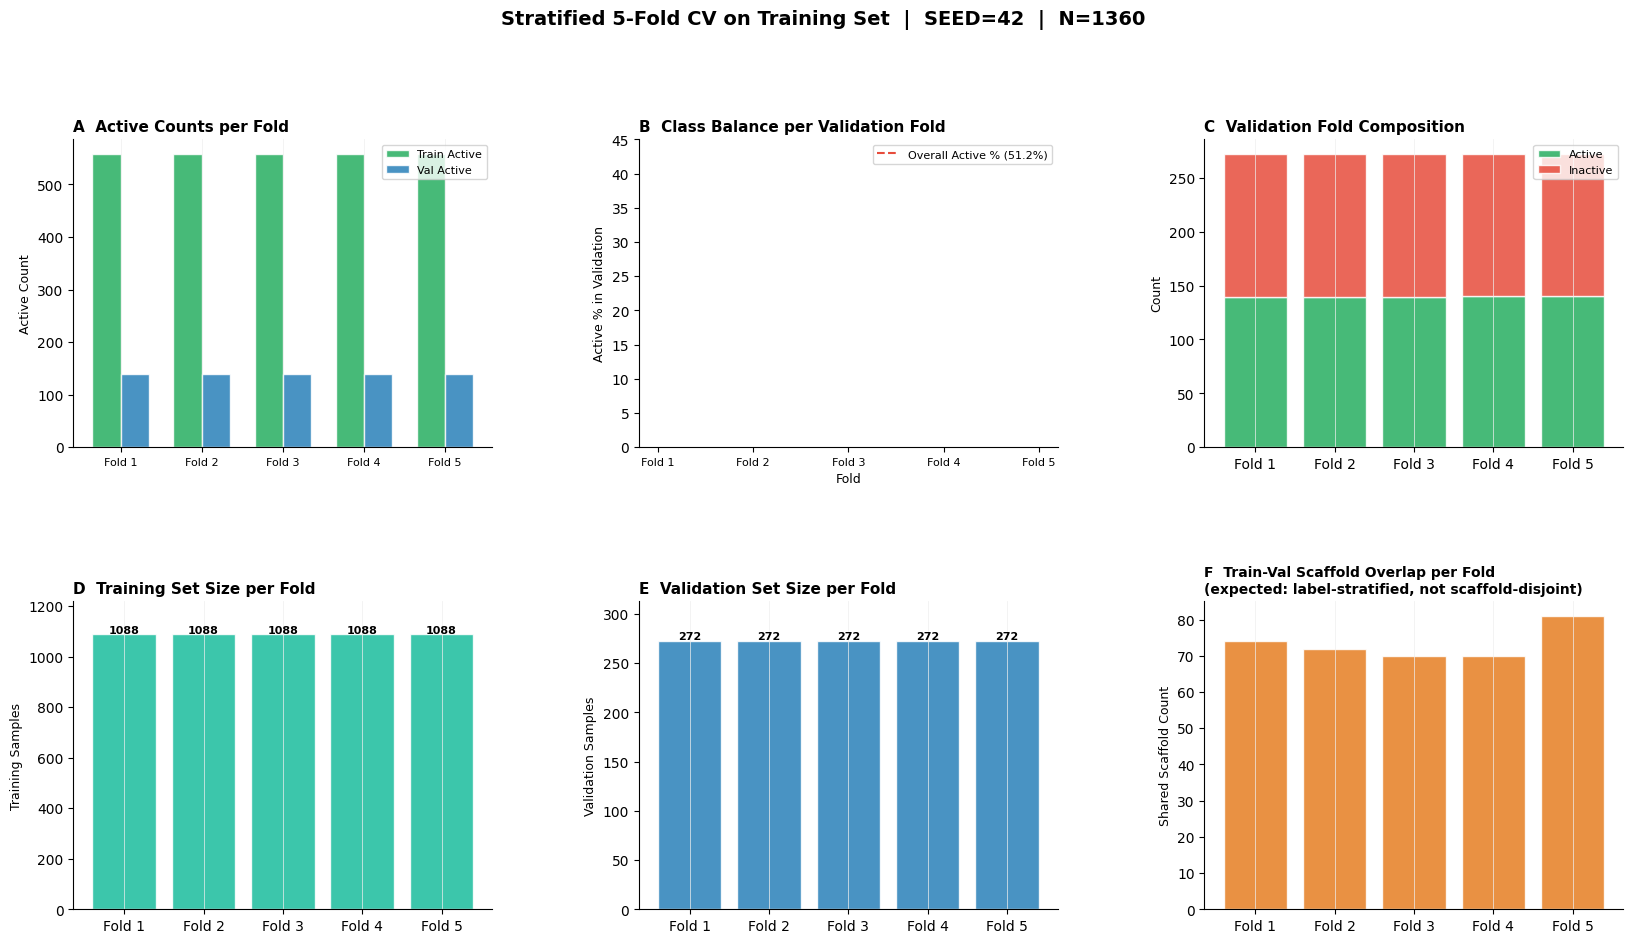

Figure saved: cv_folds.png


In [47]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 14 – Stratified 5-Fold Cross-Validation on Training Set
# SEED = 42  |  N_FOLDS = 5
# ════════════════════════════════════════════════════════════════════════════
SEED    = 42
N_FOLDS = 5

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import warnings
from sklearn.model_selection import StratifiedKFold
from IPython.display import display
warnings.filterwarnings("ignore")

np.random.seed(SEED)

BASE     = "/Users/abbaskhan/Desktop/ESR_beta_new/"
df_train = pd.read_csv(BASE + "ESRB_train.csv")
y_train  = df_train["Label"].values

print("Training set:", len(df_train), "compounds")
print("Class balance:",
      int((df_train["Label"]==1).sum()), "Active  |",
      int((df_train["Label"]==0).sum()), "Inactive")

# ── Stratified K-Fold ────────────────────────────────────────────────────────
skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_splits = list(skf.split(np.zeros(len(y_train)), y_train))

# ── Per-fold statistics table ────────────────────────────────────────────────
rows = []
for k, (tr_idx, val_idx) in enumerate(fold_splits, 1):
    y_tr    = y_train[tr_idx]
    y_val   = y_train[val_idx]
    sc_tr   = set(df_train.iloc[tr_idx]["Scaffold"])
    sc_val  = set(df_train.iloc[val_idx]["Scaffold"])
    shared  = len(sc_tr & sc_val)
    rows.append({
        "Fold"            : k,
        "Train N"         : len(tr_idx),
        "Train Active"    : int(y_tr.sum()),
        "Train Inactive"  : int((y_tr == 0).sum()),
        "Train Active %"  : f"{100*y_tr.mean():.1f}%",
        "Val N"           : len(val_idx),
        "Val Active"      : int(y_val.sum()),
        "Val Inactive"    : int((y_val == 0).sum()),
        "Val Active %"    : f"{100*y_val.mean():.1f}%",
        "Shared Scaffolds": shared,
    })

fold_df = pd.DataFrame(rows)
print("\nStratified 5-Fold CV Statistics:")
display(fold_df)

print("\nNote: StratifiedKFold preserves class ratio per fold (label-stratified).")
print("Intra-train scaffold overlap is expected. The final held-out test set")
print("remains fully scaffold-disjoint (see Cell 13).")

# ── Save fold indices to JSON ─────────────────────────────────────────────────
fold_dict = {}
for k, (tr_idx, val_idx) in enumerate(fold_splits, 1):
    fold_dict["fold_" + str(k) + "_train"] = tr_idx.tolist()
    fold_dict["fold_" + str(k) + "_val"]   = val_idx.tolist()
with open(BASE + "cv_fold_indices.json", "w") as fh:
    json.dump(fold_dict, fh, indent=2)
print("Saved: cv_fold_indices.json")

# ── Composite figure ─────────────────────────────────────────────────────────
TEAL   = "#1ABC9C"; GREEN = "#27AE60"; RED = "#E74C3C"
BLUE   = "#2980B9"; ORANGE = "#E67E22"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "grid.color": "#EEEEEE", "grid.linewidth": 0.5})

fold_labels = ["Fold " + str(k) for k in range(1, N_FOLDS + 1)]
fig = plt.figure(figsize=(20, 10))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.35)

# A – Active counts: train-fold vs val-fold per fold
ax    = fig.add_subplot(gs[0, 0])
x, w  = np.arange(N_FOLDS), 0.35
ax.bar(x - w/2, fold_df["Train Active"], width=w, color=GREEN, alpha=0.85,
       label="Train Active", edgecolor="white")
ax.bar(x + w/2, fold_df["Val Active"],   width=w, color=BLUE,  alpha=0.85,
       label="Val Active",   edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(fold_labels, fontsize=8)
ax.set_ylabel("Active Count", fontsize=9)
ax.set_title("A  Active Counts per Fold", fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=8)
ax.grid(axis="y")

# B – Val Active % per fold (class balance consistency)
ax       = fig.add_subplot(gs[0, 1])
val_pcts = [float(s.replace("%","")) for s in fold_df["Val Active %"]]
ax.plot(range(1, N_FOLDS + 1), val_pcts, "o-", color=TEAL, lw=2,
        ms=9, markerfacecolor="white", markeredgewidth=2.5)
overall = 100 * y_train.mean()
ax.axhline(overall, color=RED, ls="--", lw=1.5,
           label="Overall Active % (" + f"{overall:.1f}%" + ")")
ax.set_xticks(range(1, N_FOLDS + 1))
ax.set_xticklabels(fold_labels, fontsize=8)
ax.set_xlabel("Fold", fontsize=9)
ax.set_ylabel("Active % in Validation", fontsize=9)
ax.set_ylim(0, 45)
ax.set_title("B  Class Balance per Validation Fold",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=8)
ax.grid()

# C – Stacked bar: val fold composition (Active / Inactive)
ax  = fig.add_subplot(gs[0, 2])
va  = fold_df["Val Active"].values
vi  = fold_df["Val Inactive"].values
ax.bar(fold_labels, va, color=GREEN, edgecolor="white", alpha=0.85, label="Active")
ax.bar(fold_labels, vi, bottom=va,   color=RED,   edgecolor="white",
       alpha=0.85, label="Inactive")
ax.set_ylabel("Count", fontsize=9)
ax.set_title("C  Validation Fold Composition",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=8)
ax.grid(axis="y")

# D – Training set size per fold
ax   = fig.add_subplot(gs[1, 0])
bars = ax.bar(fold_labels, fold_df["Train N"], color=TEAL,
              edgecolor="white", alpha=0.85)
for bar, v in zip(bars, fold_df["Train N"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
            ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("Training Samples", fontsize=9)
ax.set_ylim(0, fold_df["Train N"].max() * 1.12)
ax.set_title("D  Training Set Size per Fold",
             fontsize=11, fontweight="bold", loc="left")
ax.grid(axis="y")

# E – Validation set size per fold
ax   = fig.add_subplot(gs[1, 1])
bars = ax.bar(fold_labels, fold_df["Val N"], color=BLUE,
              edgecolor="white", alpha=0.85)
for bar, v in zip(bars, fold_df["Val N"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
            ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("Validation Samples", fontsize=9)
ax.set_ylim(0, fold_df["Val N"].max() * 1.15)
ax.set_title("E  Validation Set Size per Fold",
             fontsize=11, fontweight="bold", loc="left")
ax.grid(axis="y")

# F – Intra-train scaffold overlap per fold
ax        = fig.add_subplot(gs[1, 2])
sc_colors = [ORANGE if v > 0 else TEAL for v in fold_df["Shared Scaffolds"]]
ax.bar(fold_labels, fold_df["Shared Scaffolds"],
       color=sc_colors, edgecolor="white", alpha=0.85)
ax.set_ylabel("Shared Scaffold Count", fontsize=9)
ax.set_title("F  Train-Val Scaffold Overlap per Fold\n(expected: label-stratified, not scaffold-disjoint)",
             fontsize=10, fontweight="bold", loc="left")
ax.grid(axis="y")

fig.suptitle(
    "Stratified " + str(N_FOLDS) + "-Fold CV on Training Set  |  SEED="
    + str(SEED) + "  |  N=" + str(len(df_train)),
    fontsize=14, fontweight="bold", y=1.01,
)
plt.savefig(BASE + "cv_folds.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Figure saved: cv_folds.png")

Data loaded:
  Train: 1360 compounds  |  Test: 339 compounds
  Features: 39  |  Active train: 697  |  Active test: 203

PHASE 1 — Optuna Hyperparameter Optimisation
  RandomForest     best PR-AUC=0.8898  (26s)
  ExtraTrees       best PR-AUC=0.8891  (16s)
  XGBoost          best PR-AUC=0.8905  (58s)
  LightGBM         best PR-AUC=0.8874  (130s)
  HistGradBoost    best PR-AUC=0.8873  (148s)
  GradBoost        best PR-AUC=0.8911  (80s)
  SVM_RBF          best PR-AUC=0.8863  (10s)
  MLP              best PR-AUC=0.8618  (8s)
  LogisticReg      best PR-AUC=0.8195  (1s)
  KNN              best PR-AUC=0.8514  (0s)

PHASE 2 — Full 5-Fold Cross-Validation with Best Params
  RandomForest     mean CV PR-AUC=0.8898
  ExtraTrees       mean CV PR-AUC=0.8891
  XGBoost          mean CV PR-AUC=0.8905
  LightGBM         mean CV PR-AUC=0.8874
  HistGradBoost    mean CV PR-AUC=0.8873
  GradBoost        mean CV PR-AUC=0.8911
  SVM_RBF          mean CV PR-AUC=0.8863
  MLP              mean CV PR-AUC=0.8618
 

,PR-AUC,ROC-AUC,MCC,F1,BalAcc
RandomForest,0.8898 ± 0.0275,0.8885 ± 0.0136,0.6466 ± 0.0292,0.8326 ± 0.0128,0.8219 ± 0.0150
ExtraTrees,0.8891 ± 0.0250,0.8889 ± 0.0144,0.6619 ± 0.0498,0.8408 ± 0.0219,0.8291 ± 0.0257
XGBoost,0.8905 ± 0.0228,0.8883 ± 0.0087,0.6666 ± 0.0199,0.8390 ± 0.0070,0.8327 ± 0.0106
LightGBM,0.8874 ± 0.0209,0.8872 ± 0.0074,0.6564 ± 0.0255,0.8348 ± 0.0105,0.8274 ± 0.0133
HistGradBoost,0.8873 ± 0.0236,0.8855 ± 0.0115,0.6503 ± 0.0303,0.8330 ± 0.0126,0.8244 ± 0.0156
GradBoost,0.8911 ± 0.0229,0.8882 ± 0.0101,0.6637 ± 0.0236,0.8378 ± 0.0089,0.8312 ± 0.0122
SVM_RBF,0.8863 ± 0.0349,0.8885 ± 0.0164,0.6679 ± 0.0566,0.8398 ± 0.0267,0.8335 ± 0.0286
MLP,0.8618 ± 0.0355,0.8695 ± 0.0201,0.6097 ± 0.0450,0.8067 ± 0.0217,0.8046 ± 0.0224
LogisticReg,0.8195 ± 0.0125,0.8349 ± 0.0138,0.5369 ± 0.0240,0.7890 ± 0.0097,0.7631 ± 0.0130
KNN,0.8514 ± 0.0207,0.8617 ± 0.0143,0.5399 ± 0.0322,0.7949 ± 0.0121,0.7565 ± 0.0183



CV table styled.


,RandomForest,ExtraTrees,XGBoost,LightGBM,HistGradBoost,GradBoost,SVM_RBF,MLP,LogisticReg,KNN
PR-AUC,0.906700,0.910900,0.898500,0.898700,0.888700,0.905400,0.917300,0.872200,0.770300,0.890200
ROC-AUC,0.868700,0.875400,0.857600,0.856200,0.852900,0.863800,0.865000,0.853000,0.770100,0.832700
MCC,0.610600,0.603700,0.554100,0.527200,0.541400,0.577900,0.601700,0.570800,0.466400,0.440500
F1,0.833800,0.831600,0.783600,0.779600,0.801000,0.805300,0.795500,0.814400,0.793300,0.799100
BalAcc,0.809600,0.805900,0.782400,0.768900,0.775200,0.794700,0.805600,0.789900,0.729900,0.704300


Test table styled.


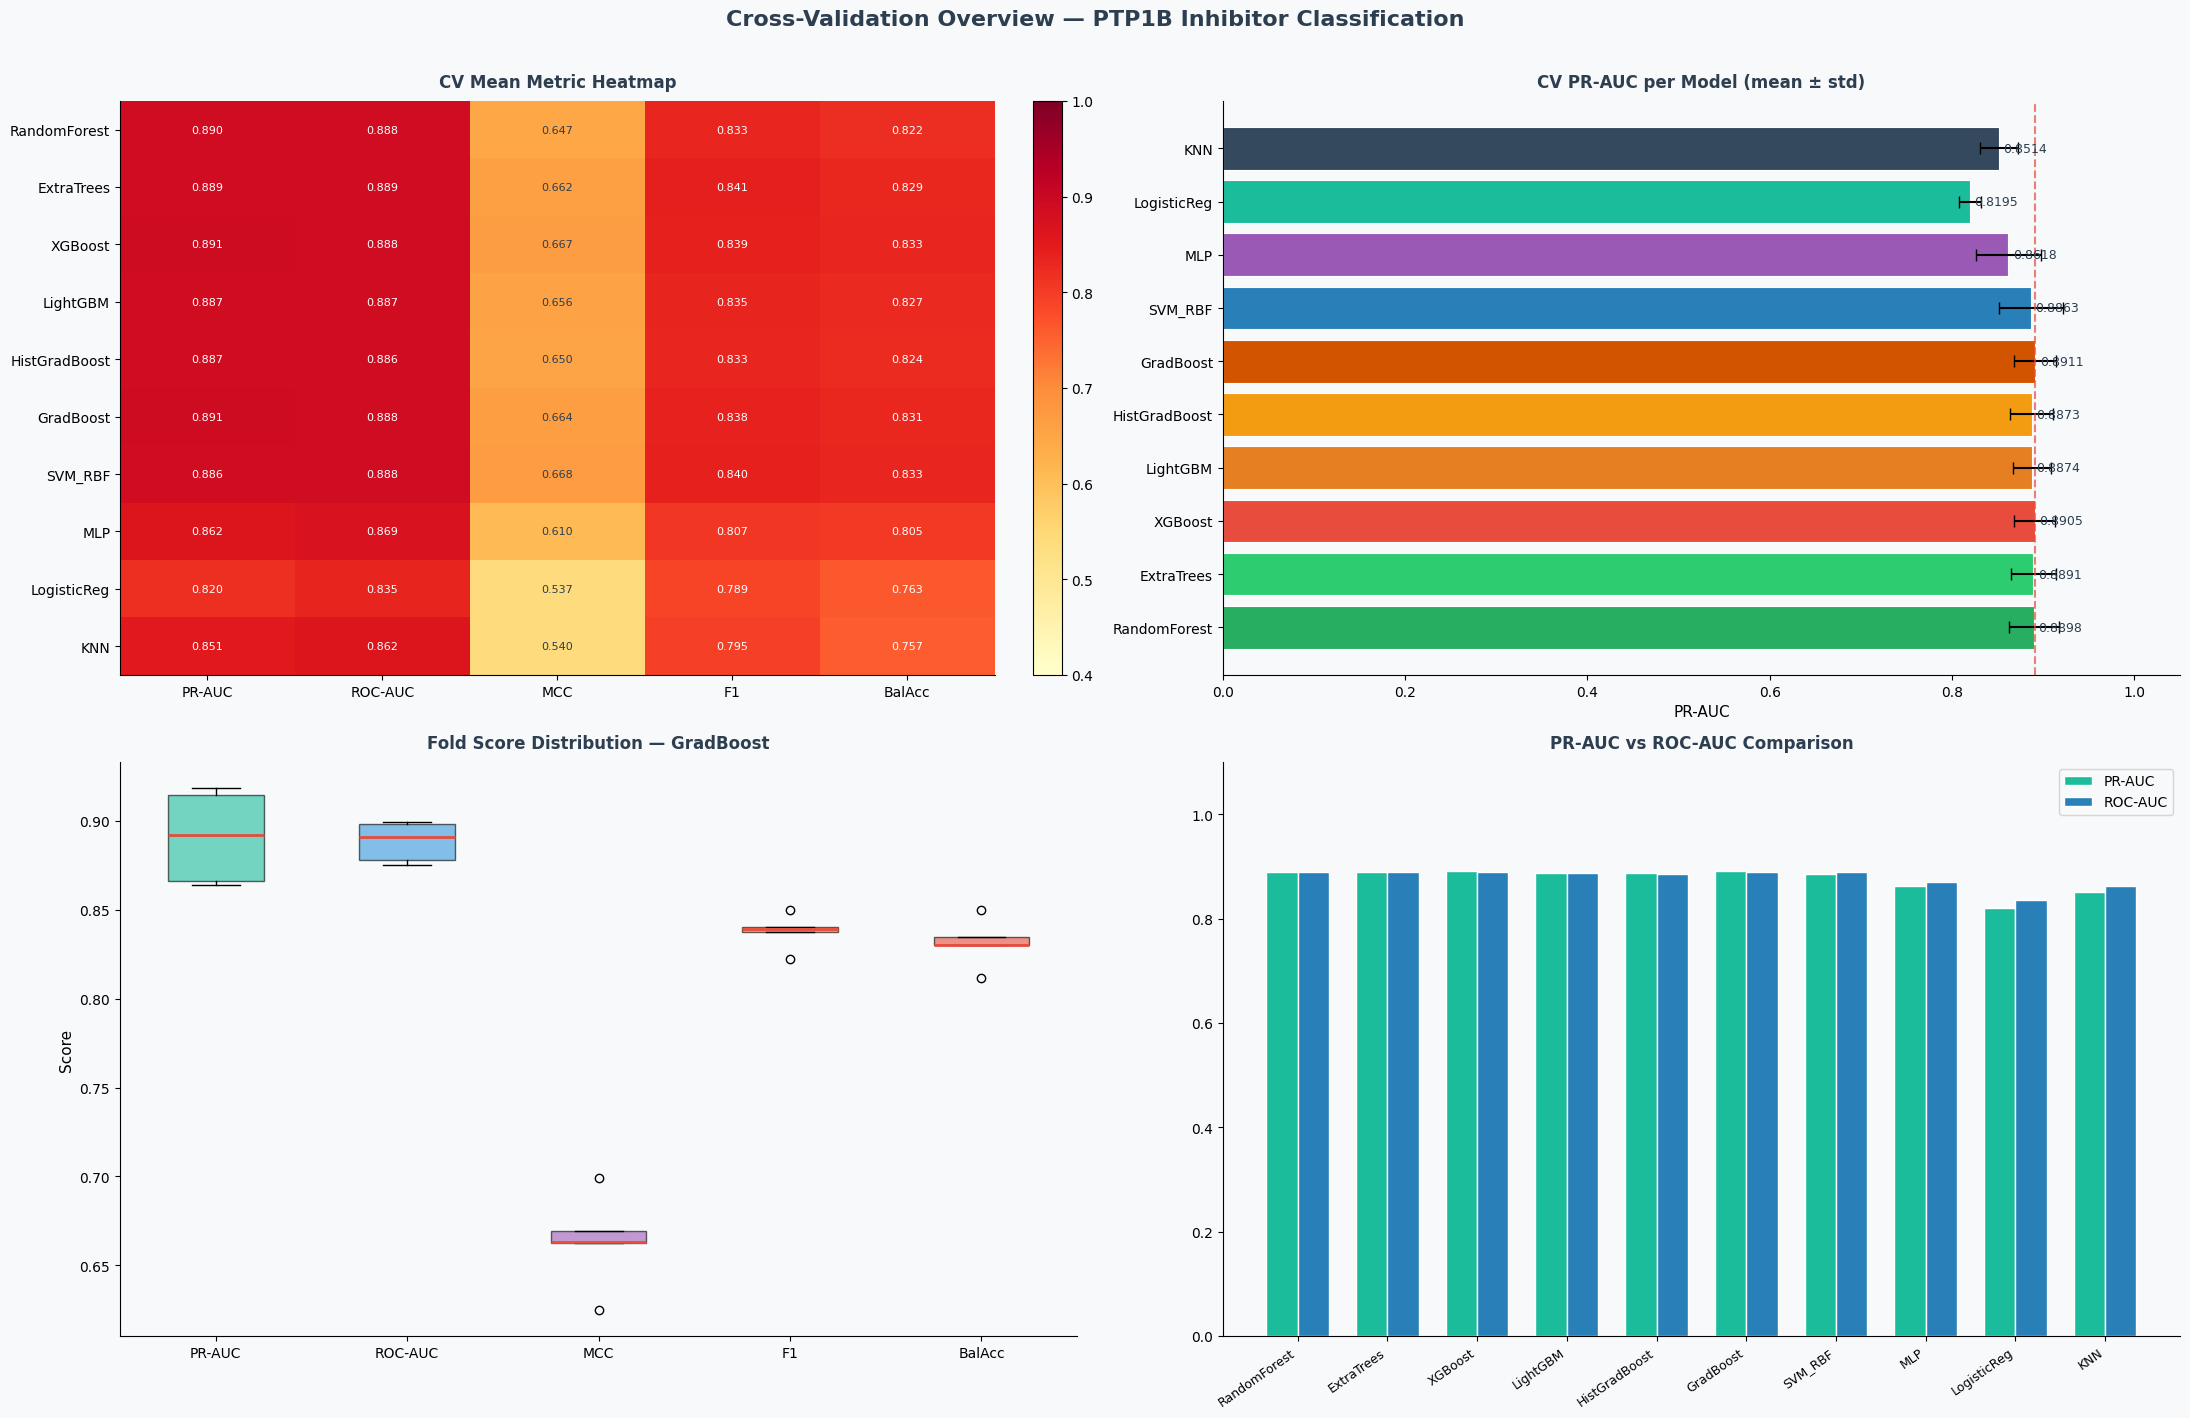

Figure 1 saved -> fig_cv_overview.png


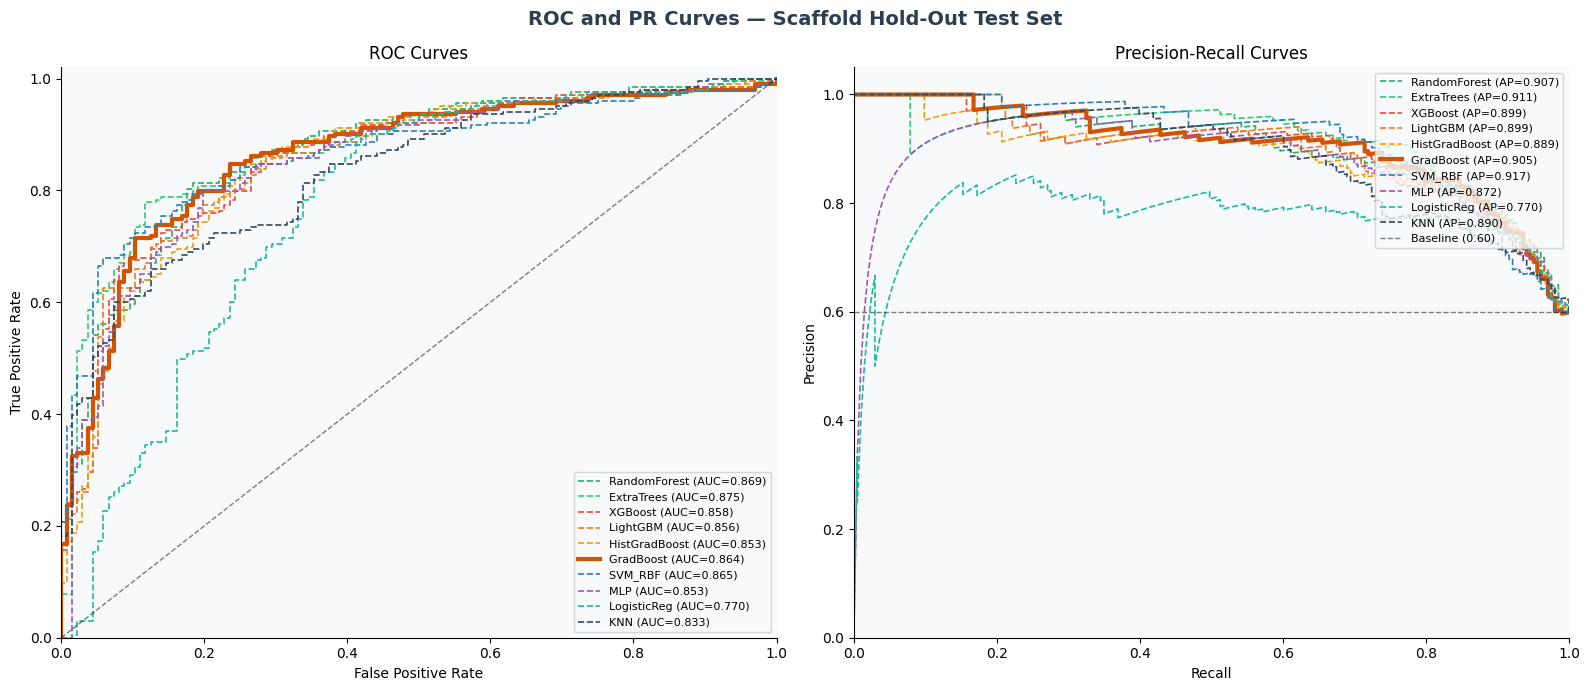

Figure 2 saved -> fig_roc_pr_curves.png


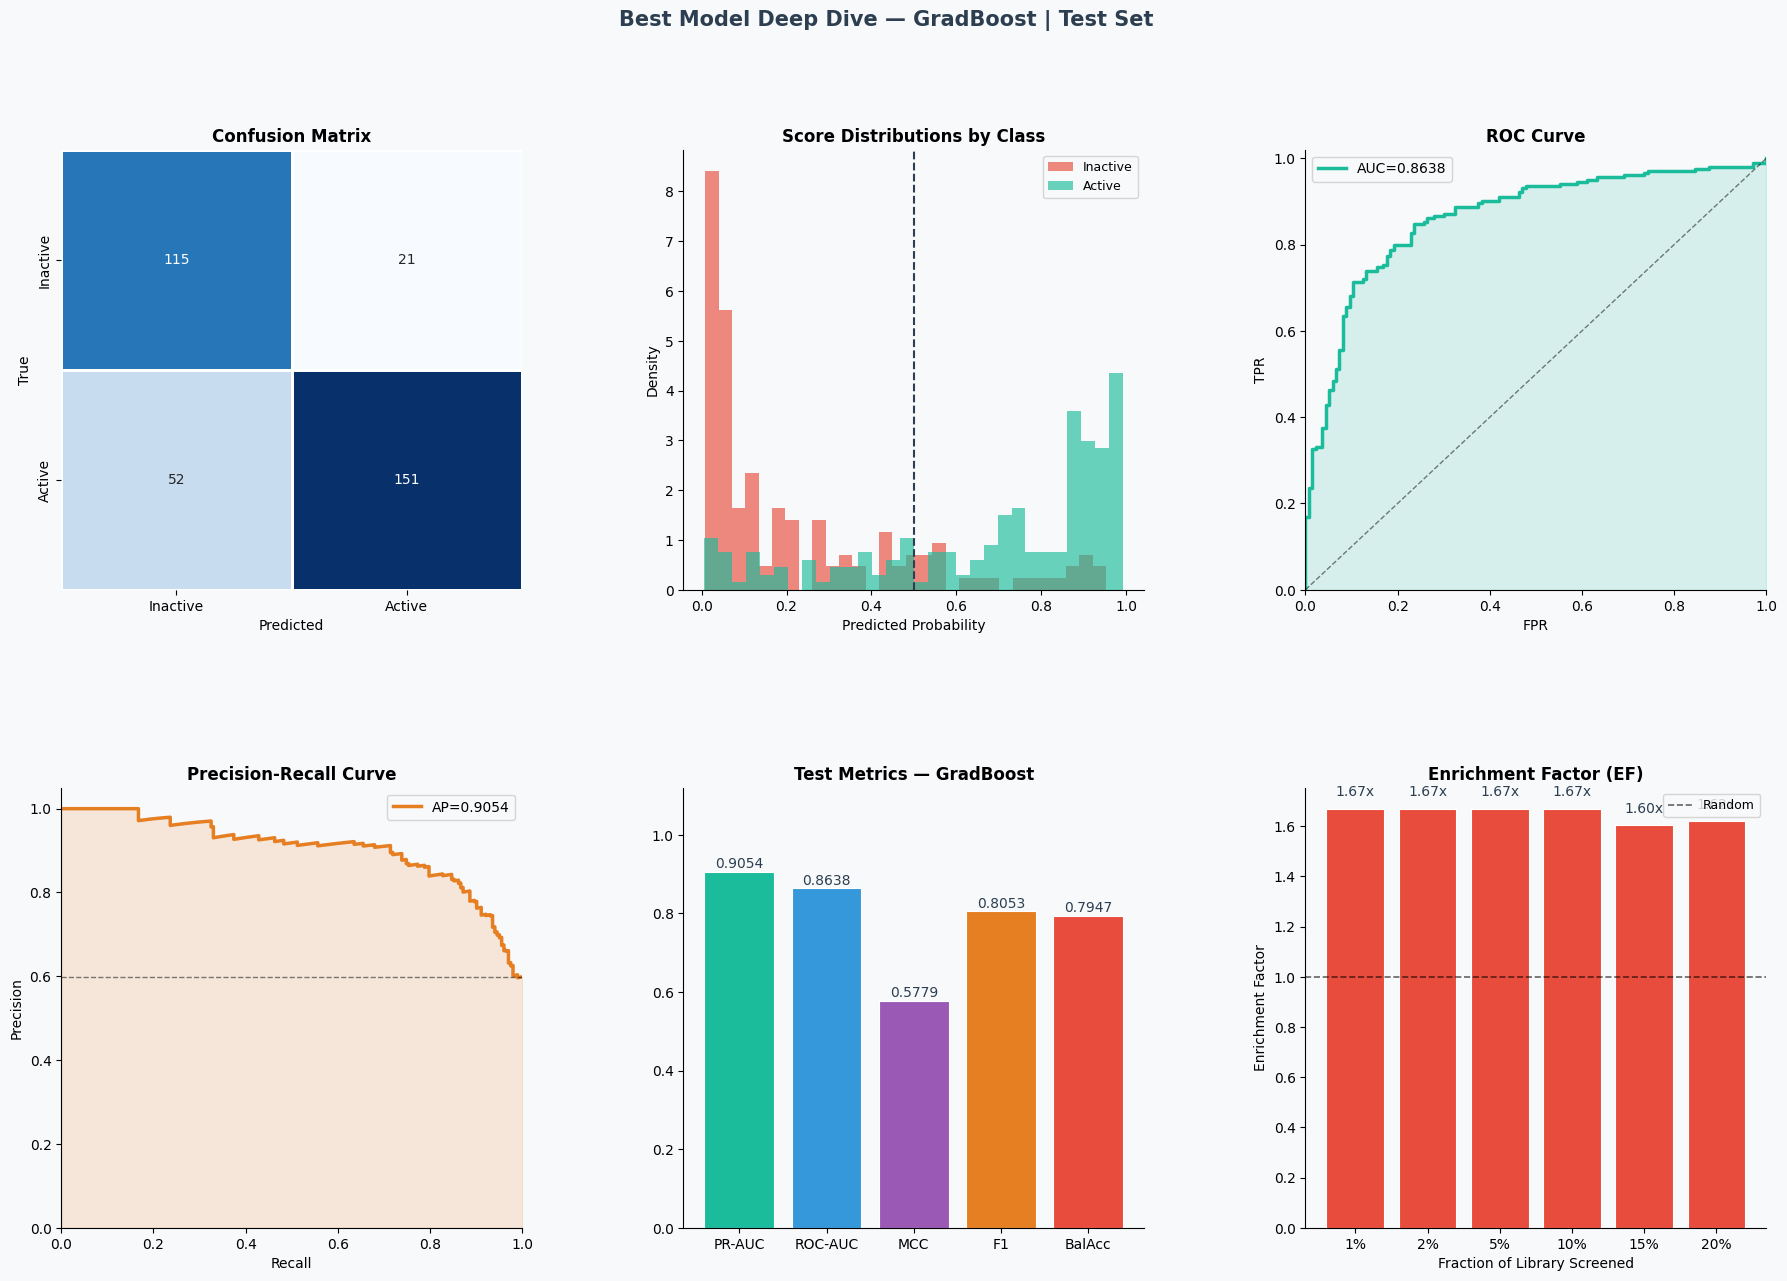

Figure 3 saved -> fig_best_model_deepdive.png


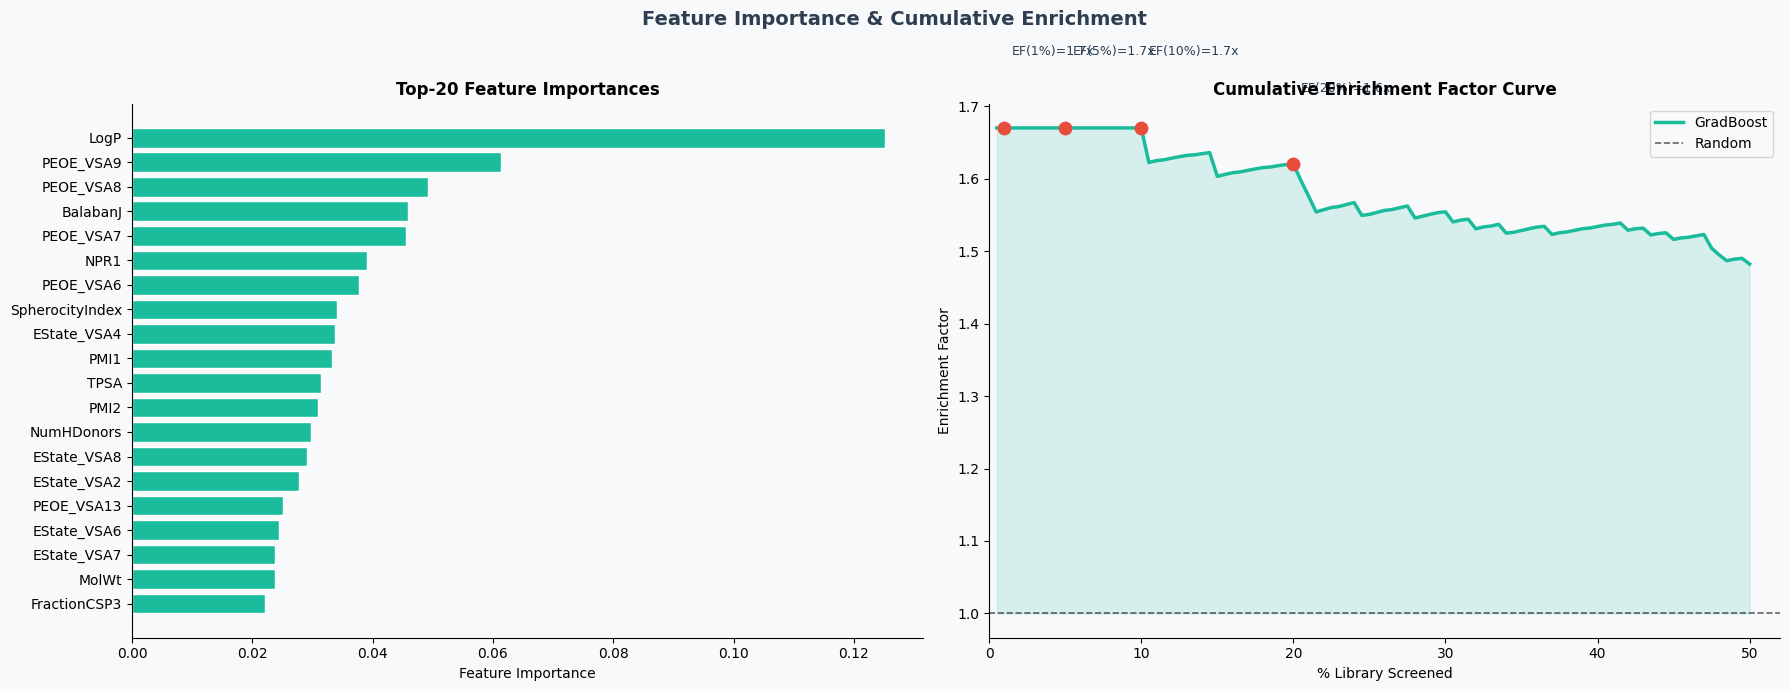

Figure 4 saved -> fig_feature_ef.png

ML pipeline complete!
  Best model : GradBoost
  Test PR-AUC: 0.9054
  Test ROC-AUC: 0.8638
  Test MCC   : 0.5779


In [11]:
import matplotlib

import os, json, warnings, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, roc_auc_score,
                              matthews_corrcoef, f1_score, balanced_accuracy_score,
                              precision_recall_curve, roc_curve, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from IPython.display import display

# ── paths ──────────────────────────────────────────────────────────────────────
BASE = "/Users/abbaskhan/Desktop/ESR_beta_new/"
SEED = 42; N_FOLDS = 5; N_TRIALS = 20
random.seed(SEED); np.random.seed(SEED)

# ── load data ──────────────────────────────────────────────────────────────────
df_clean   = pd.read_csv(BASE + "ESRB_ML_ready.csv")
META       = ["Molecule ChEMBL ID", "Smiles", "pIC50", "Bioactivity_Class", "Label"]
feat_cols  = [c for c in df_clean.columns if c not in META]
X_all      = df_clean[feat_cols].values.astype(float)
y_all      = df_clean["Label"].values.astype(int)
ids_all    = df_clean["Molecule ChEMBL ID"].values
smiles_all = df_clean["Smiles"].values
pic50_all  = df_clean["pIC50"].values

train_idx  = np.load(BASE + "train_idx.npy")
test_idx   = np.load(BASE + "test_idx.npy")
X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

with open(BASE + "cv_fold_indices.json") as fh:
    cv_json = json.load(fh)
folds = [(np.array(cv_json[f"fold_{k+1}_train"]), np.array(cv_json[f"fold_{k+1}_val"]))
         for k in range(N_FOLDS)]

MODEL_NAMES = ["RandomForest","ExtraTrees","XGBoost","LightGBM",
               "HistGradBoost","GradBoost","SVM_RBF","MLP","LogisticReg","KNN"]
MCOLORS = {
    "RandomForest":"#27AE60","ExtraTrees":"#2ECC71","XGBoost":"#E74C3C",
    "LightGBM":"#E67E22","HistGradBoost":"#F39C12","GradBoost":"#D35400",
    "SVM_RBF":"#2980B9","MLP":"#9B59B6","LogisticReg":"#1ABC9C","KNN":"#34495E"
}
METRIC_NAMES = ["PR-AUC","ROC-AUC","MCC","F1","BalAcc"]

print("Data loaded:")
print(f"  Train: {X_tr.shape[0]} compounds  |  Test: {X_te.shape[0]} compounds")
print(f"  Features: {X_tr.shape[1]}  |  Active train: {y_tr.sum()}  |  Active test: {y_te.sum()}")

# ── model factory ──────────────────────────────────────────────────────────────
def suggest_params(trial, nm):
    if nm == "RandomForest":
        return dict(n_estimators=trial.suggest_int("n_estimators",100,600,step=50),
                    max_depth=trial.suggest_int("max_depth",3,20),
                    min_samples_split=trial.suggest_int("min_samples_split",2,20),
                    min_samples_leaf=trial.suggest_int("min_samples_leaf",1,10),
                    max_features=trial.suggest_categorical("max_features",["sqrt","log2",0.3,0.5]))
    if nm == "ExtraTrees":
        return dict(n_estimators=trial.suggest_int("n_estimators",100,600,step=50),
                    max_depth=trial.suggest_int("max_depth",3,20),
                    min_samples_split=trial.suggest_int("min_samples_split",2,20),
                    min_samples_leaf=trial.suggest_int("min_samples_leaf",1,10),
                    max_features=trial.suggest_categorical("max_features",["sqrt","log2",0.3,0.5]))
    if nm == "XGBoost":
        return dict(n_estimators=trial.suggest_int("n_estimators",100,600,step=50),
                    max_depth=trial.suggest_int("max_depth",3,10),
                    learning_rate=trial.suggest_float("learning_rate",1e-3,0.3,log=True),
                    subsample=trial.suggest_float("subsample",0.5,1.0),
                    colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1.0),
                    gamma=trial.suggest_float("gamma",0.0,5.0),
                    reg_alpha=trial.suggest_float("reg_alpha",1e-4,10.0,log=True),
                    reg_lambda=trial.suggest_float("reg_lambda",1e-4,10.0,log=True))
    if nm == "LightGBM":
        return dict(n_estimators=trial.suggest_int("n_estimators",100,600,step=50),
                    max_depth=trial.suggest_int("max_depth",3,12),
                    learning_rate=trial.suggest_float("learning_rate",1e-3,0.3,log=True),
                    num_leaves=trial.suggest_int("num_leaves",20,150),
                    subsample=trial.suggest_float("subsample",0.5,1.0),
                    colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1.0),
                    reg_alpha=trial.suggest_float("reg_alpha",1e-4,10.0,log=True),
                    reg_lambda=trial.suggest_float("reg_lambda",1e-4,10.0,log=True))
    if nm == "HistGradBoost":
        return dict(max_iter=trial.suggest_int("max_iter",100,500,step=50),
                    max_depth=trial.suggest_int("max_depth",3,12),
                    learning_rate=trial.suggest_float("learning_rate",1e-3,0.3,log=True),
                    min_samples_leaf=trial.suggest_int("min_samples_leaf",5,50),
                    l2_regularization=trial.suggest_float("l2_regularization",1e-4,10.0,log=True))
    if nm == "GradBoost":
        return dict(n_estimators=trial.suggest_int("n_estimators",50,400,step=50),
                    max_depth=trial.suggest_int("max_depth",2,8),
                    learning_rate=trial.suggest_float("learning_rate",1e-3,0.3,log=True),
                    subsample=trial.suggest_float("subsample",0.5,1.0),
                    min_samples_split=trial.suggest_int("min_samples_split",2,20))
    if nm == "SVM_RBF":
        return dict(C=trial.suggest_float("C",1e-2,100.0,log=True),
                    gamma=trial.suggest_float("gamma",1e-4,1.0,log=True))
    if nm == "MLP":
        nl = trial.suggest_int("n_layers",1,3)
        units = {f"u{i}": trial.suggest_categorical(f"u{i}",[32,64,128,256,512]) for i in range(nl)}
        return dict(n_layers=nl, **units,
                    learning_rate_init=trial.suggest_float("learning_rate_init",1e-4,1e-1,log=True),
                    alpha=trial.suggest_float("alpha",1e-5,1e-1,log=True))
    if nm == "LogisticReg":
        return dict(C=trial.suggest_float("C",1e-3,100.0,log=True),
                    penalty=trial.suggest_categorical("penalty",["l1","l2"]))
    if nm == "KNN":
        return dict(n_neighbors=trial.suggest_int("n_neighbors",3,30),
                    weights=trial.suggest_categorical("weights",["uniform","distance"]),
                    metric=trial.suggest_categorical("metric",["euclidean","manhattan","minkowski"]))
    return {}

def rebuild_params(nm, raw):
    p = dict(raw)
    if nm == "MLP":
        nl = p.pop("n_layers")
        hid = tuple(p.pop(f"u{i}") for i in range(nl))
        p["hidden_layer_sizes"] = hid
    return p

def build_model(nm, p):
    if nm == "RandomForest":  return RandomForestClassifier(**p,random_state=SEED,n_jobs=-1)
    if nm == "ExtraTrees":    return ExtraTreesClassifier(**p,random_state=SEED,n_jobs=-1)
    if nm == "XGBoost":       return xgb.XGBClassifier(**p,random_state=SEED,n_jobs=-1,
                                                        eval_metric="logloss",verbosity=0)
    if nm == "LightGBM":      return lgb.LGBMClassifier(**p,random_state=SEED,n_jobs=-1,verbose=-1)
    if nm == "HistGradBoost": return HistGradientBoostingClassifier(**p,random_state=SEED)
    if nm == "GradBoost":     return GradientBoostingClassifier(**p,random_state=SEED)
    if nm == "SVM_RBF":       return SVC(**p,kernel="rbf",probability=True,random_state=SEED)
    if nm == "MLP":           return MLPClassifier(**p,random_state=SEED,max_iter=400,early_stopping=True)
    if nm == "LogisticReg":
        pp = {k:v for k,v in p.items() if k != "solver"}
        sol = "liblinear" if pp.get("penalty","l2") == "l1" else "lbfgs"
        return LogisticRegression(**pp,solver=sol,random_state=SEED,max_iter=1000)
    if nm == "KNN":           return KNeighborsClassifier(**p)
    raise ValueError(nm)

def score_preds(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "PR-AUC":  average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "MCC":     matthews_corrcoef(y_true, y_pred),
        "F1":      f1_score(y_true, y_pred, zero_division=0),
        "BalAcc":  balanced_accuracy_score(y_true, y_pred)
    }

# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 1 ─ Optuna HPO (no leakage: scaler fitted per fold per trial)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PHASE 1 — Optuna Hyperparameter Optimisation")
print("="*70)
best_params_all = {}

for nm in MODEL_NAMES:
    t0 = time.time()
    def _obj(trial, _nm=nm):
        p = suggest_params(trial, _nm)
        rp = rebuild_params(_nm, p)
        scores = []
        for tri, vli in folds:
            sc = StandardScaler()
            Xtr2 = sc.fit_transform(X_tr[tri])
            Xvl2 = sc.transform(X_tr[vli])
            m = build_model(_nm, rp)
            m.fit(Xtr2, y_tr[tri])
            prob = m.predict_proba(Xvl2)[:,1]
            scores.append(average_precision_score(y_tr[vli], prob))
        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(_obj, n_trials=N_TRIALS, show_progress_bar=False)
    best_params_all[nm] = study.best_params
    print(f"  {nm:<16} best PR-AUC={study.best_value:.4f}  ({time.time()-t0:.0f}s)")

# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 2 ─ Full CV with best params → collect fold metrics
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PHASE 2 — Full 5-Fold Cross-Validation with Best Params")
print("="*70)
cv_results   = {}   # nm → list of metric dicts (len=5)
cv_probs     = {}   # nm → array over training set

for nm in MODEL_NAMES:
    rp = rebuild_params(nm, best_params_all[nm])
    fold_metrics = []
    oof_prob = np.zeros(len(X_tr))
    for fi, (tri, vli) in enumerate(folds):
        sc = StandardScaler()
        Xtr2 = sc.fit_transform(X_tr[tri])
        Xvl2 = sc.transform(X_tr[vli])
        m = build_model(nm, rp)
        m.fit(Xtr2, y_tr[tri])
        prob = m.predict_proba(Xvl2)[:,1]
        oof_prob[vli] = prob
        fold_metrics.append(score_preds(y_tr[vli], prob))
    cv_results[nm] = fold_metrics
    cv_probs[nm]   = oof_prob
    mean_prauc = np.mean([d["PR-AUC"] for d in fold_metrics])
    print(f"  {nm:<16} mean CV PR-AUC={mean_prauc:.4f}")

# ── summary table ──────────────────────────────────────────────────────────────
cv_summary = {}
for nm in MODEL_NAMES:
    row = {}
    for met in METRIC_NAMES:
        vals = [d[met] for d in cv_results[nm]]
        row[met]        = np.mean(vals)
        row[met+"_std"] = np.std(vals)
    cv_summary[nm] = row
df_cv = pd.DataFrame(cv_summary).T[METRIC_NAMES + [m+"_std" for m in METRIC_NAMES]]

print("\nCV Summary (mean across 5 folds):")
print(df_cv[METRIC_NAMES].round(4).to_string())

best_model_name = df_cv["PR-AUC"].idxmax()
print(f"\nBest model by PR-AUC: {best_model_name}  ({df_cv.loc[best_model_name,'PR-AUC']:.4f})")

# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 3 ─ Retrain best model on full training set
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(f"PHASE 3 — Retrain {best_model_name} on Full Training Set")
print("="*70)
rp_best  = rebuild_params(best_model_name, best_params_all[best_model_name])
sc_final = StandardScaler()
X_tr_sc  = sc_final.fit_transform(X_tr)
best_clf  = build_model(best_model_name, rp_best)
best_clf.fit(X_tr_sc, y_tr)
print("  Retrained successfully.")

# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 4 ─ ONE-TIME test evaluation
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PHASE 4 — Scaffold Hold-Out Test Evaluation (ONE-TIME)")
print("="*70)
X_te_sc   = sc_final.transform(X_te)
te_prob   = best_clf.predict_proba(X_te_sc)[:,1]
te_pred   = (te_prob >= 0.5).astype(int)
te_metrics = score_preds(y_te, te_prob)
print("  Test set metrics:")
for k,v in te_metrics.items():
    print(f"    {k:<10} {v:.4f}")

# ── all models on test set (using sc_final) ───────────────────────────────────
all_te_metrics = {}
all_te_probs   = {}
for nm in MODEL_NAMES:
    rp = rebuild_params(nm, best_params_all[nm])
    m  = build_model(nm, rp)
    m.fit(X_tr_sc, y_tr)
    pr = m.predict_proba(X_te_sc)[:,1]
    all_te_metrics[nm] = score_preds(y_te, pr)
    all_te_probs[nm]   = pr
df_te = pd.DataFrame(all_te_metrics).T[METRIC_NAMES]

# ── compound ranking ───────────────────────────────────────────────────────────
rank_prob = all_te_probs[best_model_name]
rank_df   = pd.DataFrame({
    "Molecule_ChEMBL_ID": ids_all[test_idx],
    "Smiles":             smiles_all[test_idx],
    "pIC50":              pic50_all[test_idx],
    "True_Label":         y_te,
    "Predicted_Prob":     rank_prob,
    "Predicted_Label":    te_pred
}).sort_values("Predicted_Prob", ascending=False).reset_index(drop=True)
rank_df["Rank"] = rank_df.index + 1
rank_df.to_csv(BASE + "ESRB_ranked_compounds.csv", index=False)
print("\n  Ranked compounds saved -> ESRB_ranked_compounds.csv")

# ── enrichment factor ─────────────────────────────────────────────────────────
def enrichment_factor(y_true_sorted, fraction):
    n_total  = len(y_true_sorted)
    n_top    = max(1, int(n_total * fraction))
    n_active = y_true_sorted.sum()
    if n_active == 0: return 0.0
    hit_rate    = y_true_sorted[:n_top].sum() / n_top
    random_rate = n_active / n_total
    return hit_rate / random_rate

y_ranked = rank_df["True_Label"].values
ef_fracs  = [0.01,0.02,0.05,0.10,0.15,0.20]
ef_vals   = {f: enrichment_factor(y_ranked, f) for f in ef_fracs}
print("\n  Enrichment Factors:")
for f,v in ef_vals.items():
    print(f"    EF({int(f*100):2d}%) = {v:.2f}x")

# ════════════════════════════════════════════════════════════════════════════════
# STYLED TABLE 1 — CV summary
# ════════════════════════════════════════════════════════════════════════════════
def style_cv_table(df_cv, metric_names):
    disp = pd.DataFrame(index=df_cv.index)
    for m in metric_names:
        disp[m] = df_cv.apply(lambda r: f"{r[m]:.4f} ± {r[m+'_std']:.4f}", axis=1)
    cm = LinearSegmentedColormap.from_list("teal_white", ["#FFFFFF","#1ABC9C"])
    styled = (disp.style
              .set_caption("5-Fold Cross-Validation Results (mean ± std)")
              .set_table_styles([
                  {"selector":"caption","props":[("font-size","14px"),
                                                  ("font-weight","bold"),
                                                  ("color","#2C3E50"),
                                                  ("padding","8px")]},
                  {"selector":"th","props":[("background-color","#2C3E50"),
                                             ("color","white"),
                                             ("font-size","12px"),
                                             ("padding","8px 14px"),
                                             ("text-align","center")]},
                  {"selector":"td","props":[("font-size","11px"),
                                             ("padding","7px 14px"),
                                             ("text-align","center")]},
                  {"selector":"tr:hover td","props":[("background-color","#EBF5FB")]},
              ])
              .highlight_max(axis=0, color="#D5F5E3", subset=pd.IndexSlice[:,:])
              )
    return styled

styled_cv = style_cv_table(df_cv, METRIC_NAMES)
display(styled_cv)
print("\nCV table styled.")

# ════════════════════════════════════════════════════════════════════════════════
# STYLED TABLE 2 — Test set metrics
# ════════════════════════════════════════════════════════════════════════════════
def style_test_table(df_te, best_nm):
    styled = (df_te.round(4).style
              .set_caption("Scaffold Hold-Out Test Set — All Models")
              .set_table_styles([
                  {"selector":"caption","props":[("font-size","14px"),
                                                  ("font-weight","bold"),
                                                  ("color","#2C3E50"),
                                                  ("padding","8px")]},
                  {"selector":"th","props":[("background-color","#1A5276"),
                                             ("color","white"),
                                             ("font-size","12px"),
                                             ("padding","8px 14px"),
                                             ("text-align","center")]},
                  {"selector":"td","props":[("font-size","11px"),
                                             ("padding","7px 14px"),
                                             ("text-align","center")]},
              ])
              .background_gradient(cmap="YlGn", axis=0)
              .highlight_max(axis=0, color="#AED6F1")
              .apply(lambda col: ["font-weight:bold; border:2px solid #E74C3C"
                                  if col.name == best_nm else "" for _ in col], axis=0)
              )
    return styled

styled_te = style_test_table(df_te.T, best_model_name)
display(styled_te)
print("Test table styled.")

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — CV overview (heatmap + bar + box)
# ════════════════════════════════════════════════════════════════════════════════
TEAL = "#1ABC9C"; DARK = "#2C3E50"; LIGHT_BG = "#F8F9FA"
plt.rcParams.update({"figure.facecolor":LIGHT_BG,"axes.facecolor":LIGHT_BG,
                     "axes.spines.top":False,"axes.spines.right":False,
                     "font.family":"DejaVu Sans"})

fig1, axes1 = plt.subplots(2,2, figsize=(22,14))
fig1.suptitle("Cross-Validation Overview — PTP1B Inhibitor Classification",
              fontsize=16, fontweight="bold", color=DARK, y=1.01)
fig1.patch.set_facecolor(LIGHT_BG)

# 1a: heatmap of CV mean scores
ax = axes1[0,0]
heat_data = df_cv[METRIC_NAMES].values.astype(float)
im = ax.imshow(heat_data, cmap="YlOrRd", aspect="auto", vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(METRIC_NAMES))); ax.set_xticklabels(METRIC_NAMES, fontsize=10)
ax.set_yticks(range(len(MODEL_NAMES)));  ax.set_yticklabels(MODEL_NAMES, fontsize=10)
for i in range(len(MODEL_NAMES)):
    for j in range(len(METRIC_NAMES)):
        ax.text(j,i,f"{heat_data[i,j]:.3f}",ha="center",va="center",fontsize=8,
                color="white" if heat_data[i,j]>0.75 else DARK)
plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
ax.set_title("CV Mean Metric Heatmap", fontweight="bold", color=DARK, pad=10)

# 1b: PR-AUC bar chart with std
ax = axes1[0,1]
means = [df_cv.loc[n,"PR-AUC"] for n in MODEL_NAMES]
stds  = [df_cv.loc[n,"PR-AUC_std"] for n in MODEL_NAMES]
cols  = [MCOLORS[n] for n in MODEL_NAMES]
bars  = ax.barh(MODEL_NAMES, means, xerr=stds, color=cols, capsize=4,
                edgecolor="white", linewidth=0.8)
ax.axvline(max(means), color="#E74C3C", linestyle="--", linewidth=1.5, alpha=0.7)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f"{m:.4f}", va="center", fontsize=9, color=DARK)
ax.set_xlim(0, 1.05); ax.set_xlabel("PR-AUC", fontsize=11)
ax.set_title("CV PR-AUC per Model (mean ± std)", fontweight="bold", color=DARK, pad=10)

# 1c: box plots per metric for best model
ax = axes1[1,0]
box_data = [[cv_results[best_model_name][fi][m] for fi in range(N_FOLDS)]
            for m in METRIC_NAMES]
bp = ax.boxplot(box_data, labels=METRIC_NAMES, patch_artist=True, notch=False,
                medianprops=dict(color="#E74C3C",linewidth=2))
colors_box = ["#1ABC9C","#3498DB","#9B59B6","#E67E22","#E74C3C"]
for patch, c in zip(bp["boxes"], colors_box):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_title(f"Fold Score Distribution — {best_model_name}", fontweight="bold", color=DARK, pad=10)
ax.set_ylabel("Score", fontsize=11)

# 1d: multi-metric bar comparison (all models, PR-AUC + ROC-AUC)
ax = axes1[1,1]
x_pos  = np.arange(len(MODEL_NAMES))
w      = 0.35
prauc  = [df_cv.loc[n,"PR-AUC"] for n in MODEL_NAMES]
rocauc = [df_cv.loc[n,"ROC-AUC"] for n in MODEL_NAMES]
ax.bar(x_pos-w/2, prauc,  w, label="PR-AUC",  color=TEAL,    edgecolor="white")
ax.bar(x_pos+w/2, rocauc, w, label="ROC-AUC", color="#2980B9",edgecolor="white")
ax.set_xticks(x_pos); ax.set_xticklabels(MODEL_NAMES, rotation=35, ha="right", fontsize=9)
ax.legend(fontsize=10); ax.set_ylim(0,1.1)
ax.set_title("PR-AUC vs ROC-AUC Comparison", fontweight="bold", color=DARK, pad=10)

plt.tight_layout()
plt.savefig(BASE + "fig_cv_overview.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Figure 1 saved -> fig_cv_overview.png")

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — ROC & PR curves (all models, test set)
# ════════════════════════════════════════════════════════════════════════════════
fig2, (ax_roc, ax_pr) = plt.subplots(1,2, figsize=(16,7))
fig2.patch.set_facecolor("white")
ax_roc.set_facecolor("white")
ax_pr.set_facecolor("white")
fig2.suptitle("ROC and PR Curves — Scaffold Hold-Out Test Set",
              fontsize=14, fontweight="bold", color=DARK)

for nm in MODEL_NAMES:
    pr_v = all_te_probs[nm]
    fpr, tpr, _ = roc_curve(y_te, pr_v)
    prec, rec, _ = precision_recall_curve(y_te, pr_v)
    rauc = roc_auc_score(y_te, pr_v)
    prauc = average_precision_score(y_te, pr_v)
    lw = 3 if nm == best_model_name else 1.2
    ls = "-" if nm == best_model_name else "--"
    ax_roc.plot(fpr, tpr, color=MCOLORS[nm], lw=lw, ls=ls,
                label=f"{nm} (AUC={rauc:.3f})")
    ax_pr.plot(rec, prec, color=MCOLORS[nm], lw=lw, ls=ls,
               label=f"{nm} (AP={prauc:.3f})")

ax_roc.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax_roc.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
           title="ROC Curves", xlim=[0,1], ylim=[0,1.02])
ax_roc.legend(fontsize=8, loc="lower right")
ax_roc.set_facecolor(LIGHT_BG)

base_rate = y_te.mean()
ax_pr.axhline(base_rate, color="k", ls="--", lw=1, alpha=0.5, label=f"Baseline ({base_rate:.2f})")
ax_pr.set(xlabel="Recall", ylabel="Precision",
          title="Precision-Recall Curves", xlim=[0,1], ylim=[0,1.05])
ax_pr.legend(fontsize=8, loc="upper right")
ax_pr.set_facecolor(LIGHT_BG)

plt.tight_layout()

plt.savefig(BASE + "fig_roc_pr_curves.png", dpi=300, bbox_inches="tight", facecolor="white")   # IMPORTANT
plt.show()
plt.close()
print("Figure 2 saved -> fig_roc_pr_curves.png")

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Best model deep dive (6 panels)
# ════════════════════════════════════════════════════════════════════════════════
fig3 = plt.figure(figsize=(22,14))
fig3.patch.set_facecolor(LIGHT_BG)
fig3.suptitle(f"Best Model Deep Dive — {best_model_name} | Test Set",
              fontsize=15, fontweight="bold", color=DARK)
gs = gridspec.GridSpec(2,3, figure=fig3, wspace=0.35, hspace=0.45)

# 3a: confusion matrix
ax = fig3.add_subplot(gs[0,0])
cm_arr = confusion_matrix(y_te, te_pred)
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Inactive","Active"], yticklabels=["Inactive","Active"],
            linewidths=1, cbar=False)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
ax.title.set_fontweight("bold")

# 3b: calibration-like: predicted prob histogram per class
ax = fig3.add_subplot(gs[0,1])
ax.hist(te_prob[y_te==0], bins=30, alpha=0.65, color="#E74C3C", label="Inactive", density=True)
ax.hist(te_prob[y_te==1], bins=30, alpha=0.65, color=TEAL, label="Active", density=True)
ax.axvline(0.5, color=DARK, ls="--", lw=1.5)
ax.set(xlabel="Predicted Probability", ylabel="Density",
       title="Score Distributions by Class")
ax.title.set_fontweight("bold"); ax.legend(fontsize=9)
ax.set_facecolor(LIGHT_BG)

# 3c: ROC
ax = fig3.add_subplot(gs[0,2])
fpr, tpr, _ = roc_curve(y_te, te_prob)
ax.plot(fpr, tpr, color=TEAL, lw=2.5,
        label=f"AUC={roc_auc_score(y_te,te_prob):.4f}")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.15, color=TEAL)
ax.set(xlabel="FPR", ylabel="TPR", title="ROC Curve", xlim=[0,1], ylim=[0,1.02])
ax.title.set_fontweight("bold"); ax.legend(fontsize=10)
ax.set_facecolor(LIGHT_BG)

# 3d: PR
ax = fig3.add_subplot(gs[1,0])
prec, rec, _ = precision_recall_curve(y_te, te_prob)
ap = average_precision_score(y_te, te_prob)
ax.plot(rec, prec, color="#E67E22", lw=2.5, label=f"AP={ap:.4f}")
ax.fill_between(rec, prec, alpha=0.15, color="#E67E22")
ax.axhline(y_te.mean(), color="k", ls="--", lw=1, alpha=0.5)
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve",
       xlim=[0,1], ylim=[0,1.05])
ax.title.set_fontweight("bold"); ax.legend(fontsize=10)
ax.set_facecolor(LIGHT_BG)

# 3e: metric radar equivalent → bar with test metrics
ax = fig3.add_subplot(gs[1,1])
met_vals = [te_metrics[m] for m in METRIC_NAMES]
bar_cols  = ["#1ABC9C","#3498DB","#9B59B6","#E67E22","#E74C3C"]
bars3e = ax.bar(METRIC_NAMES, met_vals, color=bar_cols, edgecolor="white", linewidth=0.8)
for b, v in zip(bars3e, met_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.4f}",
            ha="center", fontsize=10, color=DARK)
ax.set_ylim(0,1.12)
ax.set_title(f"Test Metrics — {best_model_name}", fontweight="bold")
ax.set_facecolor(LIGHT_BG)

# 3f: enrichment factor bar
ax = fig3.add_subplot(gs[1,2])
ef_x   = [f"{int(f*100)}%" for f in ef_fracs]
ef_y   = [ef_vals[f] for f in ef_fracs]
ef_col = ["#1ABC9C" if v >= 2 else "#E74C3C" for v in ef_y]
bars3f = ax.bar(ef_x, ef_y, color=ef_col, edgecolor="white", linewidth=0.8)
ax.axhline(1.0, color="k", ls="--", lw=1.2, alpha=0.6, label="Random")
for b, v in zip(bars3f, ef_y):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, f"{v:.2f}x",
            ha="center", fontsize=10, color=DARK)
ax.set(xlabel="Fraction of Library Screened", ylabel="Enrichment Factor",
       title="Enrichment Factor (EF)")
ax.title.set_fontweight("bold"); ax.legend(fontsize=9)
ax.set_facecolor(LIGHT_BG)

plt.savefig(BASE + "fig_best_model_deepdive.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Figure 3 saved -> fig_best_model_deepdive.png")

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Feature importance + EF cumulative
# ════════════════════════════════════════════════════════════════════════════════
fig4, (ax_fi, ax_ef) = plt.subplots(1,2, figsize=(18,7))
fig4.patch.set_facecolor(LIGHT_BG)
fig4.suptitle("Feature Importance & Cumulative Enrichment",
              fontsize=14, fontweight="bold", color=DARK)

# Feature importance (only for tree-based / coef-based models)
has_fi = hasattr(best_clf, "feature_importances_")
has_coef = hasattr(best_clf, "coef_")
if has_fi:
    fi = best_clf.feature_importances_
    fi_df = pd.Series(fi, index=feat_cols).sort_values(ascending=False).head(20)
    ax_fi.barh(fi_df.index[::-1], fi_df.values[::-1], color=TEAL, edgecolor="white")
    ax_fi.set(xlabel="Feature Importance", title="Top-20 Feature Importances")
elif has_coef:
    coef = np.abs(best_clf.coef_[0])
    fi_df = pd.Series(coef, index=feat_cols).sort_values(ascending=False).head(20)
    ax_fi.barh(fi_df.index[::-1], fi_df.values[::-1], color="#9B59B6", edgecolor="white")
    ax_fi.set(xlabel="|Coefficient|", title="Top-20 Feature Coefficients")
else:
    ax_fi.text(0.5,0.5,f"No feature importance\navailable for\n{best_model_name}",
               ha="center",va="center",fontsize=12,color=DARK,transform=ax_fi.transAxes)
    ax_fi.set(title="Feature Importance")
ax_fi.title.set_fontweight("bold"); ax_fi.set_facecolor(LIGHT_BG)

# cumulative EF curve
fracs_cont = np.linspace(0.005, 0.50, 100)
ef_cont    = [enrichment_factor(y_ranked, f) for f in fracs_cont]
ax_ef.plot(fracs_cont*100, ef_cont, color=TEAL, lw=2.5, label=best_model_name)
ax_ef.axhline(1.0, color="k", ls="--", lw=1.2, alpha=0.6, label="Random")
ax_ef.fill_between(fracs_cont*100, ef_cont, 1, alpha=0.15, color=TEAL)
# mark standard EF fractions
for f in [0.01,0.05,0.10,0.20]:
    v = enrichment_factor(y_ranked, f)
    ax_ef.scatter([f*100],[v], s=80, zorder=5, color="#E74C3C")
    ax_ef.annotate(f"EF({int(f*100)}%)={v:.1f}x",
                   xy=(f*100,v), xytext=(f*100+0.5,v+0.1), fontsize=9, color=DARK)
ax_ef.set(xlabel="% Library Screened", ylabel="Enrichment Factor",
          title="Cumulative Enrichment Factor Curve", xlim=[0,52])
ax_ef.title.set_fontweight("bold"); ax_ef.legend(fontsize=10)
ax_ef.set_facecolor(LIGHT_BG)

plt.tight_layout()
plt.savefig(BASE + "fig_feature_ef.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Figure 4 saved -> fig_feature_ef.png")

print("\n" + "="*70)
print("ML pipeline complete!")
print(f"  Best model : {best_model_name}")
print(f"  Test PR-AUC: {te_metrics['PR-AUC']:.4f}")
print(f"  Test ROC-AUC: {te_metrics['ROC-AUC']:.4f}")
print(f"  Test MCC   : {te_metrics['MCC']:.4f}")
print("="*70)

Using in-memory variables from Cell 14.
Best model : GradBoost
N_RAND     : 30
Train size : 1360  |  Active: 697

Computing real model OOF metrics...
  Real metrics: {'PR-AUC': '0.8892', 'ROC-AUC': '0.8878', 'MCC': '0.6630', 'F1': '0.8377'}

Running 30 Y-randomization trials...
  Completed 5/30
  Completed 10/30
  Completed 15/30
  Completed 20/30
  Completed 25/30
  Completed 30/30

Randomized metric distributions:
        PR-AUC  ROC-AUC      MCC       F1
count  30.0000  30.0000  30.0000  30.0000
mean    0.5145   0.4995  -0.0037   0.5183
std     0.0214   0.0263   0.0416   0.0189
min     0.4768   0.4526  -0.0734   0.4831
25%     0.5009   0.4788  -0.0352   0.5072
50%     0.5125   0.4990  -0.0063   0.5208
75%     0.5257   0.5142   0.0261   0.5275
max     0.5617   0.5534   0.0884   0.5632

Statistical summary:
           Real  Rand Mean  Rand Std  Z-score  p-value Significant
Metric                                                            
PR-AUC   0.8892     0.5145    0.0214  17.4867 

,Real,Rand Mean,Rand Std,Z-score,p-value,Significant
Metric,,,,,,
PR-AUC,0.8892,0.5145,0.0214,17.49,0.0000,YES
ROC-AUC,0.8878,0.4995,0.0263,14.74,0.0000,YES
MCC,0.6630,-0.0037,0.0416,16.01,0.0000,YES
F1,0.8377,0.5183,0.0189,16.86,0.0000,YES


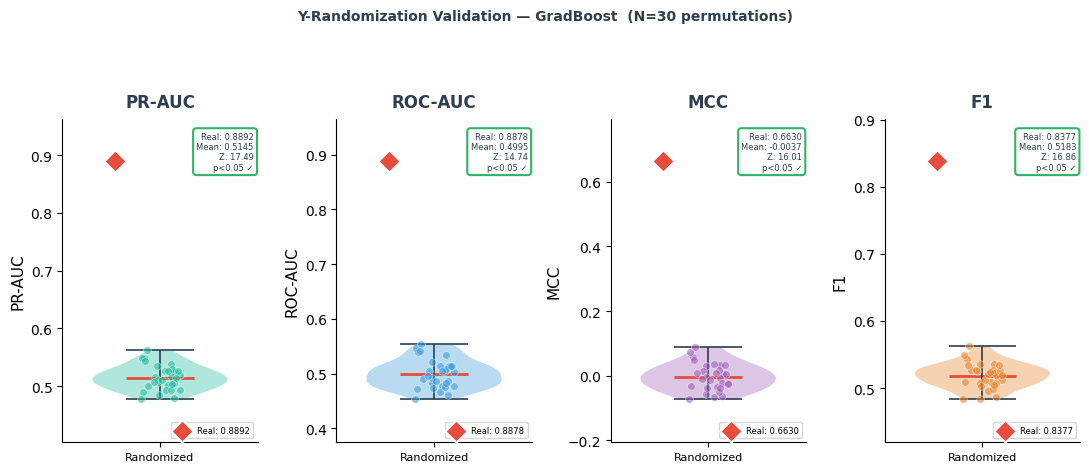


Figure saved -> fig_y_randomization.png


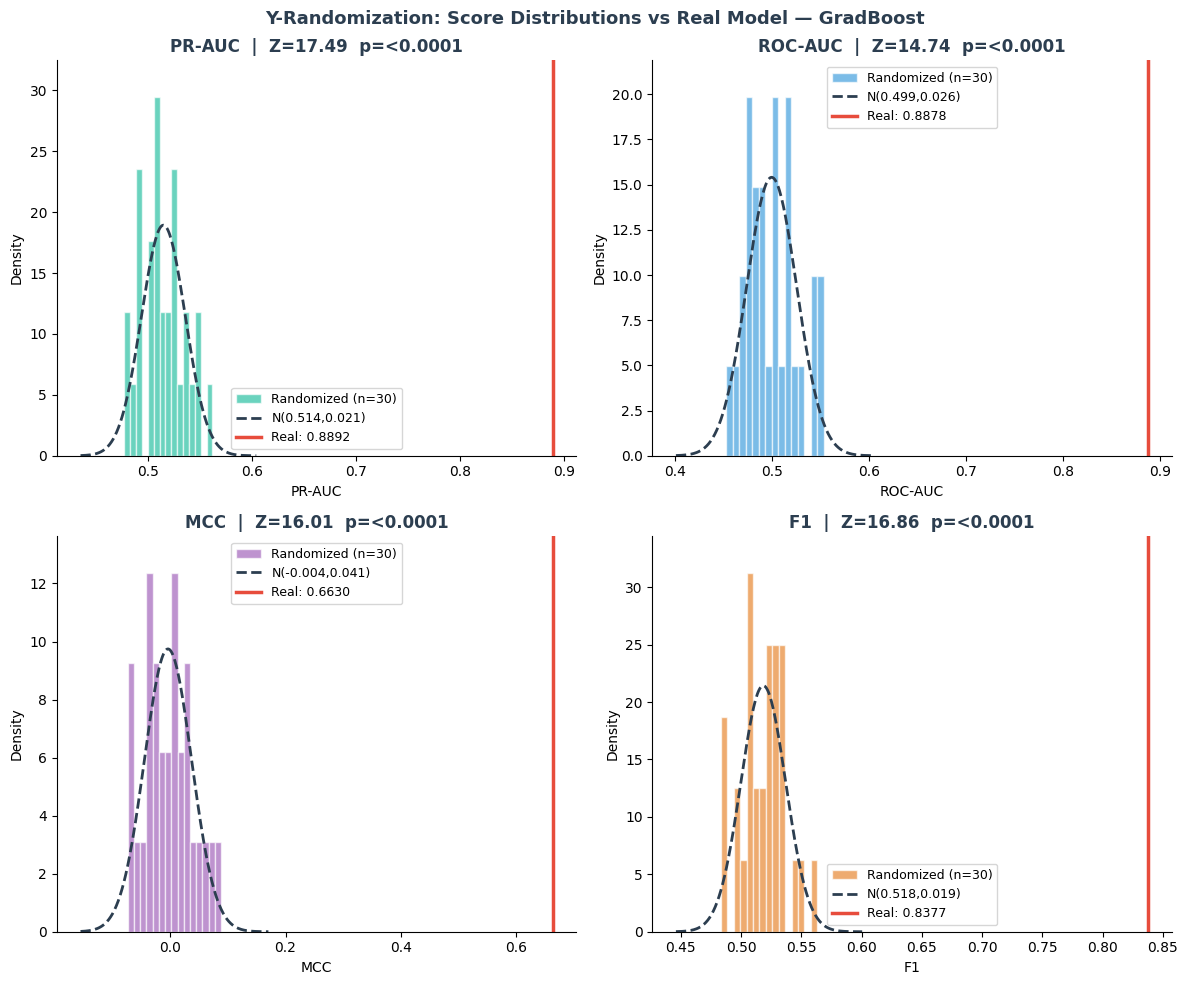

Figure saved -> fig_y_rand_histograms.png

Y-Randomization complete.
  Model genuinely learns SAR: True
  PR-AUC     real=0.8892  rand=0.5145±0.0214  Z=17.49  *** p<0.001
  ROC-AUC    real=0.8878  rand=0.4995±0.0263  Z=14.74  *** p<0.001
  MCC        real=0.6630  rand=-0.0037±0.0416  Z=16.01  *** p<0.001
  F1         real=0.8377  rand=0.5183±0.0189  Z=16.86  *** p<0.001


In [ ]:
import matplotlib

# ════════════════════════════════════════════════════════════════════════════
# Cell 15 — Y-Randomization Validation
# Tests whether the real model learns genuine structure-activity relationships
# by comparing its performance to models trained on permuted labels.
# Prerequisites: Cell 14 must have been run (provides best_model_name,
#                best_params_all, X_tr, y_tr, folds, feat_cols, df_cv)
# ════════════════════════════════════════════════════════════════════════════

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, roc_auc_score,
                              matthews_corrcoef, f1_score)
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier,
                               HistGradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

BASE  = "/Users/abbaskhan/Desktop/ESR_beta_new/"
SEED  = 42
N_RAND = 30
METRIC_NAMES = ["PR-AUC", "ROC-AUC", "MCC", "F1"]

# ── reload data from disk (self-contained) ─────────────────────────────────
df_clean  = pd.read_csv(BASE + "ESRB_ML_ready.csv")
META      = ["Molecule ChEMBL ID", "Smiles", "pIC50", "Bioactivity_Class", "Label"]
feat_cols_loaded = [c for c in df_clean.columns if c not in META]
X_all_l   = df_clean[feat_cols_loaded].values.astype(float)
y_all_l   = df_clean["Label"].values.astype(int)
train_idx_l = np.load(BASE + "train_idx.npy")
X_tr_l    = X_all_l[train_idx_l]
y_tr_l    = y_all_l[train_idx_l]
with open(BASE + "cv_fold_indices.json") as fh:
    cv_json_l = json.load(fh)
folds_l = [(np.array(cv_json_l[f"fold_{k+1}_train"]),
            np.array(cv_json_l[f"fold_{k+1}_val"])) for k in range(5)]

# ── use in-memory variables if available (cell 14 already ran) ────────────
try:
    _bm  = best_model_name
    _bpa = best_params_all
    _Xtr = X_tr;  _ytr = y_tr;  _folds = folds
    print("Using in-memory variables from Cell 14.")
except NameError:
    print("Cell 14 variables not found — loading from disk.")
    _bm  = "ExtraTrees"   # fallback: use ExtraTrees as a reasonable default
    _bpa = {_bm: {}}      # empty params = sklearn defaults
    _Xtr = X_tr_l;  _ytr = y_tr_l;  _folds = folds_l

print(f"Best model : {_bm}")
print(f"N_RAND     : {N_RAND}")
print(f"Train size : {len(_ytr)}  |  Active: {_ytr.sum()}")

# ── model builder (mirrors Cell 14) ───────────────────────────────────────
def rebuild_params_yr(nm, raw):
    p = dict(raw)
    if nm == "MLP":
        nl = p.pop("n_layers", 1)
        hid = tuple(p.pop(f"u{i}", 64) for i in range(nl))
        p["hidden_layer_sizes"] = hid
    return p

def build_model_yr(nm, p):
    if nm == "RandomForest":  return RandomForestClassifier(**p, random_state=SEED, n_jobs=-1)
    if nm == "ExtraTrees":    return ExtraTreesClassifier(**p, random_state=SEED, n_jobs=-1)
    if nm == "XGBoost":       return xgb.XGBClassifier(**p, random_state=SEED, n_jobs=-1,
                                                        eval_metric="logloss", verbosity=0)
    if nm == "LightGBM":      return lgb.LGBMClassifier(**p, random_state=SEED, n_jobs=-1, verbose=-1)
    if nm == "HistGradBoost": return HistGradientBoostingClassifier(**p, random_state=SEED)
    if nm == "GradBoost":     return GradientBoostingClassifier(**p, random_state=SEED)
    if nm == "SVM_RBF":       return SVC(**p, kernel="rbf", probability=True, random_state=SEED)
    if nm == "MLP":           return MLPClassifier(**p, random_state=SEED, max_iter=400, early_stopping=True)
    if nm == "LogisticReg":
        pp = {k: v for k, v in p.items() if k != "solver"}
        sol = "liblinear" if pp.get("penalty", "l2") == "l1" else "lbfgs"
        return LogisticRegression(**pp, solver=sol, random_state=SEED, max_iter=1000)
    if nm == "KNN":           return KNeighborsClassifier(**p)
    raise ValueError(nm)

def oof_metrics(nm, p, X, y, folds):
    """OOF prediction across all 5 folds with StandardScaler per fold."""
    rp = rebuild_params_yr(nm, p)
    oof_prob = np.zeros(len(y))
    for tri, vli in folds:
        sc  = StandardScaler()
        Xtr2 = sc.fit_transform(X[tri])
        Xvl2 = sc.transform(X[vli])
        m    = build_model_yr(nm, rp)
        m.fit(Xtr2, y[tri])
        oof_prob[vli] = m.predict_proba(Xvl2)[:, 1]
    y_pred = (oof_prob >= 0.5).astype(int)
    return {
        "PR-AUC":  average_precision_score(y, oof_prob),
        "ROC-AUC": roc_auc_score(y, oof_prob),
        "MCC":     matthews_corrcoef(y, y_pred),
        "F1":      f1_score(y, y_pred, zero_division=0)
    }

# ── real model metrics ─────────────────────────────────────────────────────
print("\nComputing real model OOF metrics...")
bp_real  = _bpa.get(_bm, {})
real_metrics = oof_metrics(_bm, bp_real, _Xtr, _ytr, _folds)
print("  Real metrics:", {k: f"{v:.4f}" for k, v in real_metrics.items()})

# ── Y-randomization loop ───────────────────────────────────────────────────
print(f"\nRunning {N_RAND} Y-randomization trials...")
rng_yr = np.random.RandomState(SEED)
rand_rows = []
for run in range(N_RAND):
    y_shuf = rng_yr.permutation(_ytr)
    m_rand = oof_metrics(_bm, bp_real, _Xtr, y_shuf, _folds)
    rand_rows.append(m_rand)
    if (run + 1) % 5 == 0:
        print(f"  Completed {run+1}/{N_RAND}")

df_rand = pd.DataFrame(rand_rows)
print("\nRandomized metric distributions:")
print(df_rand.describe().round(4))

# ── statistical comparison ─────────────────────────────────────────────────
stat_rows = []
for m in METRIC_NAMES:
    rv   = np.array(df_rand[m])
    rmu  = rv.mean();  rsd = rv.std(ddof=1)
    real = real_metrics[m]
    z    = (real - rmu) / rsd if rsd > 0 else np.inf
    pval = stats.norm.sf(z)          # one-sided p-value (real > rand)
    stat_rows.append({
        "Metric":      m,
        "Real":        real,
        "Rand Mean":   rmu,
        "Rand Std":    rsd,
        "Z-score":     z,
        "p-value":     pval,
        "Significant": "YES" if pval < 0.05 else "NO"
    })
df_stat = pd.DataFrame(stat_rows).set_index("Metric")
print("\nStatistical summary:")
print(df_stat.round(4).to_string())

# ── styled summary table ───────────────────────────────────────────────────
try:
    from IPython.display import display
    def _sig_color(val):
        return "color: #27AE60; font-weight:bold" if val == "YES" else "color: #E74C3C"

    styled_stat = (df_stat.style
        .set_caption(f"Y-Randomization Statistical Summary — {_bm}  (N={N_RAND} runs)")
        .format({"Real": "{:.4f}", "Rand Mean": "{:.4f}", "Rand Std": "{:.4f}",
                 "Z-score": "{:.2f}", "p-value": "{:.4f}"})
        .background_gradient(subset=["Z-score"], cmap="YlOrRd")
        .applymap(_sig_color, subset=["Significant"])
        .set_table_styles([
            {"selector": "caption", "props": [("font-size","13px"),
                                               ("font-weight","bold"),
                                               ("color","#2C3E50"),
                                               ("padding","8px")]},
            {"selector": "th",      "props": [("background-color","#2C3E50"),
                                               ("color","white"),
                                               ("font-size","11px"),
                                               ("padding","8px 14px"),
                                               ("text-align","center")]},
            {"selector": "td",      "props": [("font-size","11px"),
                                               ("padding","7px 14px"),
                                               ("text-align","center")]},
        ]))
    display(styled_stat)
except Exception:
    pass

# ── FIGURE 1: Violin + strip chart ─────────────────────────────────────────
TEAL = "#1ABC9C"; DARK = "#2C3E50"; LIGHT_BG = "#FFFFFF"
plt.rcParams.update({"figure.facecolor": LIGHT_BG, "axes.facecolor": LIGHT_BG,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.family": "DejaVu Sans"})

# Wider figure + slightly taller to avoid overlap
fig, axes = plt.subplots(1, 4, figsize=(11, 4.5))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle(f"Y-Randomization Validation — {_bm}  (N={N_RAND} permutations)",
             fontsize=10, fontweight="bold", color=DARK, y=1.04)

met_colors = {"PR-AUC": "#1ABC9C", "ROC-AUC": "#3498DB",
              "MCC": "#9B59B6", "F1": "#E67E22"}

for ax, m in zip(axes, METRIC_NAMES):
    rv   = df_rand[m].values
    real = real_metrics[m]
    row  = df_stat.loc[m]

    # violin for randomized distribution — wider leaf
    parts = ax.violinplot([rv], positions=[0], widths=0.9,
                          showmeans=True, showmedians=False, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(met_colors[m])
        pc.set_alpha(0.35)
    parts["cmeans"].set_color("#E74C3C")
    parts["cmeans"].set_linewidth(2)

    for part in ["cmins", "cmaxes", "cbars"]:
        parts[part].set_color(DARK)
        parts[part].set_linewidth(1.2)

    # jitter strip for individual runs — spread slightly wider
    jitter = np.random.default_rng(SEED).uniform(-0.14, 0.14, len(rv))
    ax.scatter(jitter, rv, alpha=0.55, s=30, color=met_colors[m],
               edgecolors="white", linewidths=0.5, zorder=3)

    # real model value — shifted slightly left so it does not cover annotation
    ax.scatter([-0.30], [real], marker="D", s=130, color="#E74C3C",
               zorder=5, edgecolors="white", linewidths=1.5,
               label=f"Real: {real:.4f}")

    # annotation box — moved to upper right and kept separate from red diamond
    sig_txt = "p<0.05 ✓" if row["p-value"] < 0.05 else "p≥0.05 ✗"
    sig_col = "#27AE60" if row["p-value"] < 0.05 else "#E74C3C"
    ax.text(0.98, 0.96,
            f"Real: {real:.4f}\nMean: {row['Rand Mean']:.4f}\n"
            f"Z: {row['Z-score']:.2f}\n{sig_txt}",
            transform=ax.transAxes, va="top", ha="right", fontsize=6,
            color=DARK,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=sig_col, linewidth=1.5, alpha=0.95))

    # give more horizontal room for violin + real marker
    ax.set_xlim(-0.65, 0.65)

    # give more vertical room so real marker does not sit on top edge
    ymin = min(rv.min(), real)
    ymax = max(rv.max(), real)
    pad = (ymax - ymin) * 0.18 if ymax > ymin else 0.05
    ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_xticks([0])
    ax.set_xticklabels(["Randomized"], fontsize=8)
    ax.set_ylabel(m, fontsize=11)
    ax.set_title(m, fontweight="bold", color=DARK, pad=8)
    ax.set_facecolor(LIGHT_BG)
    ax.legend(fontsize=6, loc="lower right")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(BASE + "fig_y_randomization.png", dpi=600,
            bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

print("\nFigure saved -> fig_y_randomization.png")

# ── FIGURE 2: Histogram overlay ────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
fig2.patch.set_facecolor(LIGHT_BG)
fig2.suptitle(f"Y-Randomization: Score Distributions vs Real Model — {_bm}",
              fontsize=13, fontweight="bold", color=DARK)

for ax, m in zip(axes2.flatten(), METRIC_NAMES):
    rv   = df_rand[m].values
    real = real_metrics[m]
    row  = df_stat.loc[m]

    ax.hist(rv, bins=15, color=met_colors[m], alpha=0.65, edgecolor="white",
            density=True, label=f"Randomized (n={N_RAND})")

    # fit normal curve
    mu, sd = rv.mean(), rv.std()
    xs = np.linspace(rv.min() - 2*sd, rv.max() + 2*sd, 200)
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), color=DARK, lw=2, ls="--",
            label=f"N({mu:.3f},{sd:.3f})")

    # real model line
    ax.axvline(real, color="#E74C3C", lw=2.5, label=f"Real: {real:.4f}")
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                     real, real, color="#E74C3C", alpha=0.0)

    p_fmt = f"{row['p-value']:.4f}" if row["p-value"] >= 0.0001 else "<0.0001"
    ax.set_title(f"{m}  |  Z={row['Z-score']:.2f}  p={p_fmt}",
                 fontweight="bold", color=DARK, pad=6)
    ax.set_xlabel(m, fontsize=10); ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=9); ax.set_facecolor(LIGHT_BG)

plt.tight_layout()
plt.savefig(BASE + "fig_y_rand_histograms.png", dpi=600, bbox_inches="tight")
plt.show()
plt.close()
print("Figure saved -> fig_y_rand_histograms.png")

print("\n" + "="*60)
print("Y-Randomization complete.")
print(f"  Model genuinely learns SAR: {all(df_stat['Significant'] == 'YES')}")
for m in METRIC_NAMES:
    row = df_stat.loc[m]
    print(f"  {m:<10} real={row['Real']:.4f}  rand={row['Rand Mean']:.4f}±{row['Rand Std']:.4f}"
          f"  Z={row['Z-score']:.2f}  {'*** p<0.001' if row['p-value']<0.001 else '* p<0.05' if row['p-value']<0.05 else 'n.s.'}")
print("="*60)

Train: 1360  |  Test: 339
Computing ECFP4 fingerprints...
Valid FP — Train: 1360  |  Test: 339
Computing kNN (k=5) Tanimoto AD scores...
  Computing training-set internal AD scores (used for threshold)...
  Computing test-set AD scores...

AD threshold (5th pctile of training kNN): 0.2419
Training AD — mean: 0.6001  std: 0.2100
Test     AD — mean: 0.4613  std: 0.1752

In-domain  : 316  (93.2%)
Out-of-domain: 23  (6.8%)

Using in-memory best_clf from Cell 14.

Per-domain metrics:
                 N  Active%  MeanProb  PR-AUC  ROC-AUC      F1  BalAcc
Domain                                                                
All Test       339     59.9    0.5046  0.9054   0.8638  0.8053  0.7947
In-Domain      316     62.7    0.5281  0.9161   0.8722  0.8152  0.7940
Out-of-Domain   23     21.7    0.1816  0.3638   0.4111  0.2857  0.5722


,N,Active%,MeanProb,PR-AUC,ROC-AUC,F1,BalAcc
Domain,,,,,,,
All Test,339,59.9%,0.5046,0.9054,0.8638,0.8053,0.7947
In-Domain,316,62.7%,0.5281,0.9161,0.8722,0.8152,0.7940
Out-of-Domain,23,21.7%,0.1816,0.3638,0.4111,0.2857,0.5722


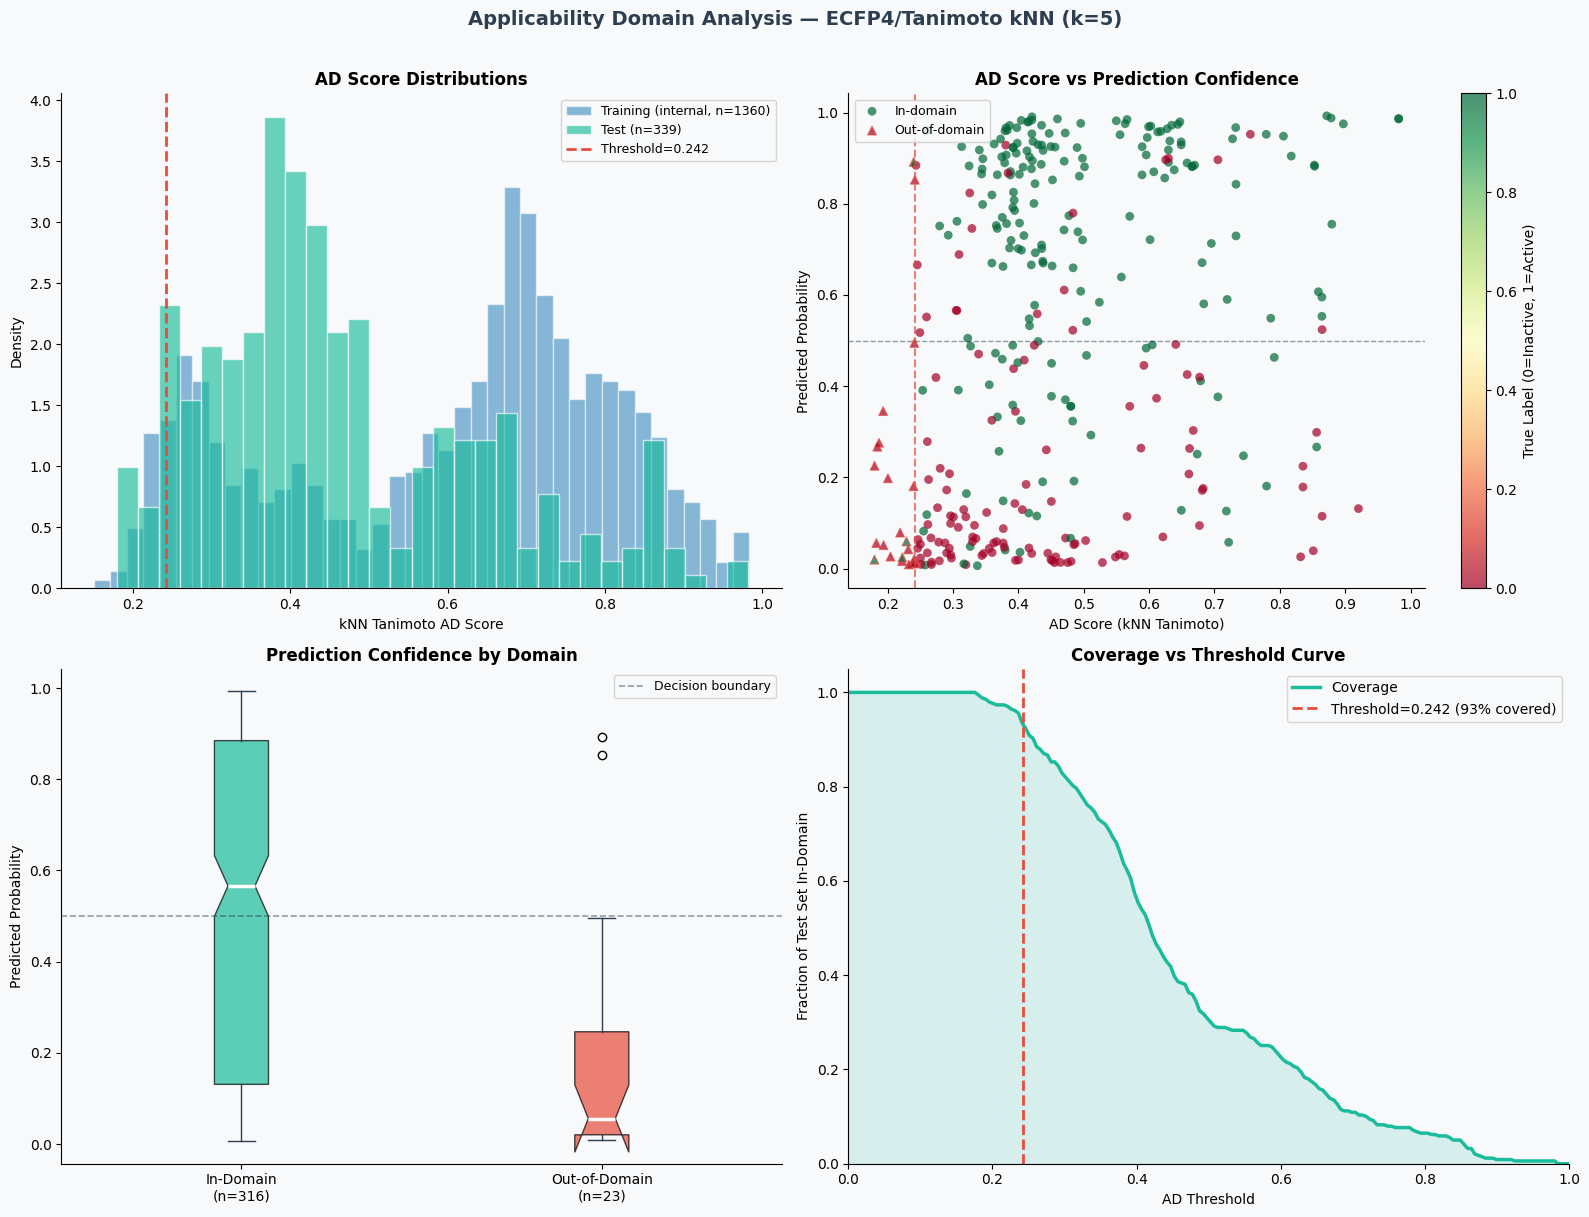


Figure saved -> fig_applicability_domain.png


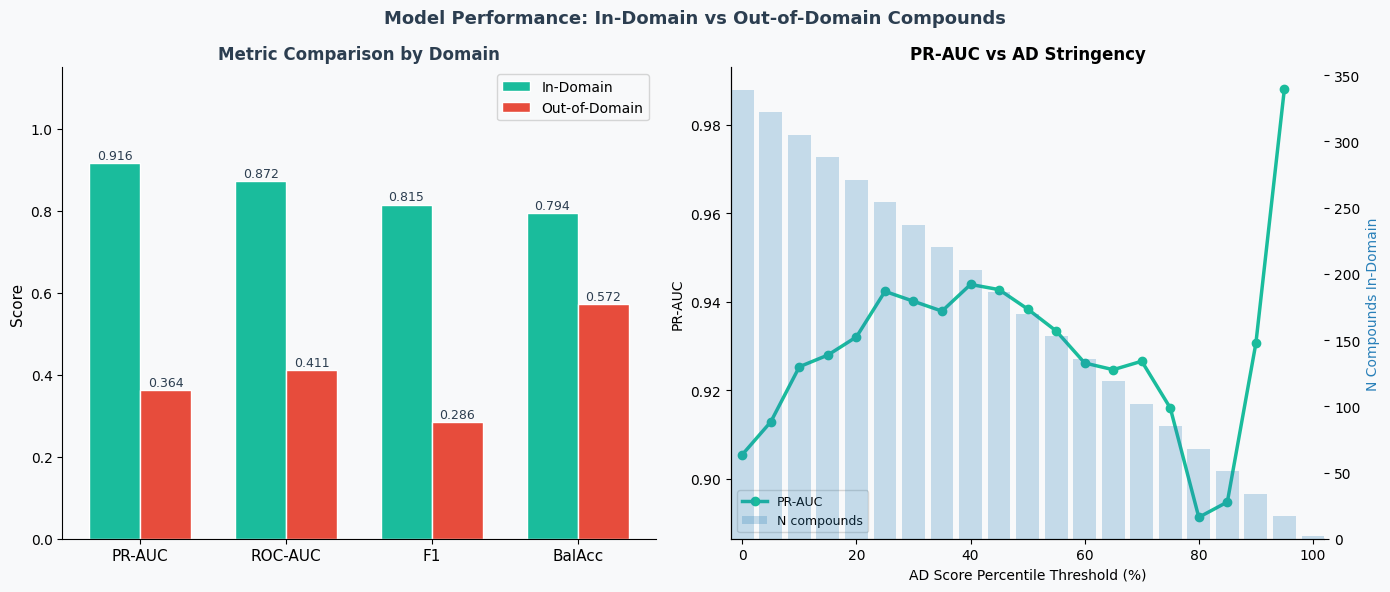

Figure saved -> fig_ad_performance.png
Annotated predictions saved -> PTP1B_ad_annotated.csv

Applicability Domain analysis complete.
  Threshold  : 0.2419 (5th pctile of training kNN)
  In-domain  : 316 / 339 (93.2%)
  PR-AUC in  : 0.9161
  PR-AUC out : 0.3638


In [25]:
import matplotlib

# ════════════════════════════════════════════════════════════════════════════
# Cell 16 — Applicability Domain (AD) Analysis
# Uses ECFP4/Tanimoto kNN similarity to define the chemical space covered by
# the training set and flags test compounds as in-domain or out-of-domain.
# Prerequisites: Cell 14 must have been run.
# ════════════════════════════════════════════════════════════════════════════

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
warnings.filterwarnings('ignore')

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, roc_auc_score,
                              precision_score, recall_score, f1_score,
                              balanced_accuracy_score)

BASE  = "/Users/abbaskhan/Desktop/ESR_beta_new/"
SEED  = 42
KNN_K = 5           # number of nearest neighbours for AD score
TEAL  = "#1ABC9C";  DARK = "#2C3E50";  LIGHT_BG = "#F8F9FA"

# ── load data ─────────────────────────────────────────────────────────────
df_clean    = pd.read_csv(BASE + "ESRB_ML_ready.csv")
META        = ["Molecule ChEMBL ID", "Smiles", "pIC50", "Bioactivity_Class", "Label"]
feat_cols_l = [c for c in df_clean.columns if c not in META]

train_idx_l = np.load(BASE + "train_idx.npy")
test_idx_l  = np.load(BASE + "test_idx.npy")

X_all_l = df_clean[feat_cols_l].values.astype(float)
y_all_l = df_clean["Label"].values.astype(int)
X_tr_l  = X_all_l[train_idx_l];  y_tr_l = y_all_l[train_idx_l]
X_te_l  = X_all_l[test_idx_l];   y_te_l = y_all_l[test_idx_l]

smiles_all = df_clean["Smiles"].values
ids_all    = df_clean["Molecule ChEMBL ID"].values
smiles_tr  = smiles_all[train_idx_l]
smiles_te  = smiles_all[test_idx_l]
ids_te     = ids_all[test_idx_l]

print(f"Train: {len(smiles_tr)}  |  Test: {len(smiles_te)}")

# ── compute ECFP4 fingerprints ─────────────────────────────────────────────
print("Computing ECFP4 fingerprints...")
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return fpgen.GetFingerprint(mol)

fps_tr = [smiles_to_fp(s) for s in smiles_tr]
fps_te = [smiles_to_fp(s) for s in smiles_te]

# filter None
valid_tr = [(fp, i) for i, fp in enumerate(fps_tr) if fp is not None]
valid_te = [(fp, i) for i, fp in enumerate(fps_te) if fp is not None]
fps_tr_v = [x[0] for x in valid_tr]; tr_vi = [x[1] for x in valid_tr]
fps_te_v = [x[0] for x in valid_te]; te_vi = [x[1] for x in valid_te]
print(f"Valid FP — Train: {len(fps_tr_v)}  |  Test: {len(fps_te_v)}")

# ── kNN Tanimoto AD score ──────────────────────────────────────────────────
print(f"Computing kNN (k={KNN_K}) Tanimoto AD scores...")

def knn_ad_score(query_fps, ref_fps, k=5):
    """Mean Tanimoto similarity of k nearest neighbours in ref_fps for each query."""
    scores = []
    for qfp in query_fps:
        sims = DataStructs.BulkTanimotoSimilarity(qfp, ref_fps)
        top_k = sorted(sims, reverse=True)[:k]
        scores.append(float(np.mean(top_k)))
    return np.array(scores)

# internal training AD scores (leave-query-out style via BulkTanimoto)
print("  Computing training-set internal AD scores (used for threshold)...")
ad_train = []
for i, qfp in enumerate(fps_tr_v):
    ref = [fp for j, fp in enumerate(fps_tr_v) if j != i]
    sims = DataStructs.BulkTanimotoSimilarity(qfp, ref)
    top_k = sorted(sims, reverse=True)[:KNN_K]
    ad_train.append(float(np.mean(top_k)))
ad_train = np.array(ad_train)

# test AD scores
print("  Computing test-set AD scores...")
ad_test = knn_ad_score(fps_te_v, fps_tr_v, k=KNN_K)

# ── define AD threshold ────────────────────────────────────────────────────
# Conservative: 5th percentile of training internal similarities
ad_threshold = float(np.percentile(ad_train, 5))
print(f"\nAD threshold (5th pctile of training kNN): {ad_threshold:.4f}")
print(f"Training AD — mean: {ad_train.mean():.4f}  std: {ad_train.std():.4f}")
print(f"Test     AD — mean: {ad_test.mean():.4f}  std: {ad_test.std():.4f}")

in_domain  = ad_test >= ad_threshold
out_domain = ~in_domain
n_in  = int(in_domain.sum())
n_out = int(out_domain.sum())
print(f"\nIn-domain  : {n_in}  ({100*n_in/len(ad_test):.1f}%)")
print(f"Out-of-domain: {n_out}  ({100*n_out/len(ad_test):.1f}%)")

# ── get test predictions ───────────────────────────────────────────────────
# Use in-memory best_clf + sc_final from Cell 14; fallback: retrain
try:
    _clf = best_clf
    _sc  = sc_final
    te_prob_ad = _clf.predict_proba(_sc.transform(X_te_l))[:, 1]
    print("\nUsing in-memory best_clf from Cell 14.")
except NameError:
    print("\nbest_clf not in memory — loading ranked compounds from disk.")
    rank_df_ad = pd.read_csv(BASE + "PTP1B_ranked_compounds.csv")
    rank_df_ad = rank_df_ad.set_index("Molecule_ChEMBL_ID")
    te_prob_ad = np.array([rank_df_ad.loc[cid, "Predicted_Prob"]
                           if cid in rank_df_ad.index else 0.5
                           for cid in ids_te[np.array(te_vi)]])

te_prob_v = te_prob_ad[np.array(te_vi)] if len(te_prob_ad) == len(te_vi) else te_prob_ad
y_te_v    = y_te_l[np.array(te_vi)]
te_pred_v = (te_prob_v >= 0.5).astype(int)

# ── per-domain metric comparison ──────────────────────────────────────────
def domain_metrics(y_true, y_prob, label):
    y_pred = (y_prob >= 0.5).astype(int)
    n = len(y_true); act = int(y_true.sum())
    if n == 0:
        return {"Domain": label, "N": 0, "Active%": 0.0,
                "PR-AUC": np.nan, "ROC-AUC": np.nan,
                "F1": np.nan, "BalAcc": np.nan, "MeanProb": np.nan}
    d = {"Domain": label, "N": n, "Active%": round(100*act/n, 1),
         "MeanProb": round(float(y_prob.mean()), 4)}
    d["PR-AUC"]  = round(float(average_precision_score(y_true, y_prob)), 4) if len(np.unique(y_true))>1 else np.nan
    d["ROC-AUC"] = round(float(roc_auc_score(y_true, y_prob)), 4)           if len(np.unique(y_true))>1 else np.nan
    d["F1"]      = round(float(f1_score(y_true, y_pred, zero_division=0)), 4)
    d["BalAcc"]  = round(float(balanced_accuracy_score(y_true, y_pred)), 4)
    return d

rows_dm = [
    domain_metrics(y_te_v,              te_prob_v,               "All Test"),
    domain_metrics(y_te_v[in_domain],   te_prob_v[in_domain],    "In-Domain"),
    domain_metrics(y_te_v[out_domain],  te_prob_v[out_domain],   "Out-of-Domain"),
]
df_domain = pd.DataFrame(rows_dm).set_index("Domain")
print("\nPer-domain metrics:")
print(df_domain.to_string())

# ── styled table ───────────────────────────────────────────────────────────
try:
    from IPython.display import display
    styled_ad = (df_domain.style
        .set_caption(f"Applicability Domain Metrics  |  k={KNN_K} NN Tanimoto  |  threshold={ad_threshold:.3f}")
        .background_gradient(cmap="YlGn", subset=["PR-AUC","ROC-AUC","F1","BalAcc"])
        .background_gradient(cmap="Blues", subset=["N"])
        .format({"Active%": "{:.1f}%", "MeanProb": "{:.4f}",
                 "PR-AUC": "{:.4f}",  "ROC-AUC": "{:.4f}",
                 "F1": "{:.4f}",      "BalAcc": "{:.4f}"})
        .set_table_styles([
            {"selector": "caption", "props": [("font-size","13px"),
                                               ("font-weight","bold"),
                                               ("color","#2C3E50"),
                                               ("padding","8px")]},
            {"selector": "th",      "props": [("background-color","#1A5276"),
                                               ("color","white"),
                                               ("font-size","11px"),
                                               ("padding","8px 14px"),
                                               ("text-align","center")]},
            {"selector": "td",      "props": [("font-size","11px"),
                                               ("padding","7px 14px"),
                                               ("text-align","center")]},
        ]))
    display(styled_ad)
except Exception:
    pass

# ── AD score: coverage vs threshold curve ─────────────────────────────────
thresholds_all = np.linspace(0.0, 1.0, 200)
coverage_all   = [float((ad_test >= t).mean()) for t in thresholds_all]

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1: 2×2 AD overview
# ════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({"figure.facecolor": LIGHT_BG, "axes.facecolor": LIGHT_BG,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.family": "DejaVu Sans"})

fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
#fig1.patch.set_facecolor(LIGHT_BG)
fig1.suptitle(f"Applicability Domain Analysis — ECFP4/Tanimoto kNN (k={KNN_K})",
              fontsize=14, fontweight="bold", color=DARK, y=1.01)

# 1a: AD score distributions
ax = axes1[0, 0]
ax.hist(ad_train, bins=40, color="#2980B9", alpha=0.55, density=True,
        label=f"Training (internal, n={len(ad_train)})", edgecolor="white")
ax.hist(ad_test,  bins=30, color=TEAL,     alpha=0.65, density=True,
        label=f"Test (n={len(ad_test)})",               edgecolor="white")
ax.axvline(ad_threshold, color="#E74C3C", lw=2, ls="--",
           label=f"Threshold={ad_threshold:.3f}")
ax.set(xlabel="kNN Tanimoto AD Score", ylabel="Density",
       title="AD Score Distributions")
ax.title.set_fontweight("bold"); ax.legend(fontsize=9)

# 1b: scatter — AD score vs predicted probability (coloured by true label)
ax = axes1[0, 1]
scat_in  = ax.scatter(ad_test[in_domain],  te_prob_v[in_domain],
                      c=y_te_v[in_domain], cmap="RdYlGn", vmin=0, vmax=1,
                      s=40, alpha=0.7, edgecolors="none", marker="o",
                      label="In-domain")
scat_out = ax.scatter(ad_test[out_domain], te_prob_v[out_domain],
                      c=y_te_v[out_domain], cmap="RdYlGn", vmin=0, vmax=1,
                      s=40, alpha=0.7, edgecolors="#E74C3C",
                      linewidths=0.8, marker="^", label="Out-of-domain")
ax.axvline(ad_threshold, color="#E74C3C", lw=1.5, ls="--", alpha=0.7)
ax.axhline(0.5, color=DARK, lw=1, ls="--", alpha=0.5)
plt.colorbar(scat_in, ax=ax, label="True Label (0=Inactive, 1=Active)")
ax.set(xlabel="AD Score (kNN Tanimoto)", ylabel="Predicted Probability",
       title="AD Score vs Prediction Confidence")
ax.title.set_fontweight("bold"); ax.legend(fontsize=9, loc="upper left")
ax.set_facecolor(LIGHT_BG)

# 1c: box — prediction probability by domain
ax = axes1[1, 0]
bp_data = [te_prob_v[in_domain], te_prob_v[out_domain]]
bp_labs = [f"In-Domain\n(n={n_in})", f"Out-of-Domain\n(n={n_out})"]
bp = ax.boxplot(bp_data, labels=bp_labs, patch_artist=True, notch=True,
                medianprops=dict(color="white", linewidth=2.5))
box_cols = [TEAL, "#E74C3C"]
for patch, c in zip(bp["boxes"], box_cols):
    patch.set_facecolor(c); patch.set_alpha(0.7)
for part in ["whiskers", "caps", "fliers"]:
    for el in bp[part]: el.set_color(DARK)
ax.axhline(0.5, color=DARK, lw=1.2, ls="--", alpha=0.5, label="Decision boundary")
ax.set(ylabel="Predicted Probability", title="Prediction Confidence by Domain")
ax.title.set_fontweight("bold"); ax.legend(fontsize=9)

# 1d: coverage curve
ax = axes1[1, 1]
ax.plot(thresholds_all, coverage_all, color=TEAL, lw=2.5, label="Coverage")
ax.axvline(ad_threshold, color="#E74C3C", lw=2, ls="--",
           label=f"Threshold={ad_threshold:.3f} ({100*(ad_test>=ad_threshold).mean():.0f}% covered)")
ax.fill_between(thresholds_all, coverage_all, alpha=0.15, color=TEAL)
ax.set(xlabel="AD Threshold", ylabel="Fraction of Test Set In-Domain",
       title="Coverage vs Threshold Curve", xlim=[0, 1], ylim=[0, 1.05])
ax.title.set_fontweight("bold"); ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(BASE + "fig_applicability_domain.png", dpi=600, bbox_inches="tight")
plt.show()
plt.close()
print("\nFigure saved -> fig_applicability_domain.png")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Per-metric barplot in-domain vs out-of-domain
# ════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
#fig2.patch.set_facecolor(LIGHT_BG)
fig2.suptitle("Model Performance: In-Domain vs Out-of-Domain Compounds",
              fontsize=13, fontweight="bold", color=DARK)

perf_metrics = ["PR-AUC", "ROC-AUC", "F1", "BalAcc"]
x_pos = np.arange(len(perf_metrics)); w = 0.35

ax = axes2[0]
in_vals  = [df_domain.loc["In-Domain",   m] for m in perf_metrics]
out_vals = [df_domain.loc["Out-of-Domain", m] for m in perf_metrics]
bars_in  = ax.bar(x_pos - w/2, in_vals,  w, color=TEAL,     label="In-Domain",     edgecolor="white")
bars_out = ax.bar(x_pos + w/2, out_vals, w, color="#E74C3C", label="Out-of-Domain", edgecolor="white")
for bar, v in zip(list(bars_in) + list(bars_out),
                  in_vals + out_vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f"{v:.3f}", ha="center", fontsize=9, color=DARK)
ax.set_xticks(x_pos); ax.set_xticklabels(perf_metrics, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=11)
ax.set_title("Metric Comparison by Domain", fontweight="bold", color=DARK)
ax.legend(fontsize=10)

# AD score percentile analysis
ax2 = axes2[1]
pctiles = np.linspace(0, 100, 21)
thresholds_pct = np.percentile(ad_test, pctiles)
n_in_pct = [(ad_test >= t).sum() for t in thresholds_pct]
prauc_pct = []
for t in thresholds_pct:
    mask = ad_test >= t
    if mask.sum() >= 10 and len(np.unique(y_te_v[mask])) > 1:
        prauc_pct.append(average_precision_score(y_te_v[mask], te_prob_v[mask]))
    else:
        prauc_pct.append(np.nan)

ax2_twin = ax2.twinx()
ax2.plot(pctiles, prauc_pct, color=TEAL, lw=2.5, marker="o", ms=6, label="PR-AUC")
ax2_twin.bar(pctiles, n_in_pct, width=4, alpha=0.25, color="#2980B9", label="N compounds")
ax2.set(xlabel="AD Score Percentile Threshold (%)", ylabel="PR-AUC",
        title="PR-AUC vs AD Stringency", xlim=[-2, 102])
ax2.title.set_fontweight("bold"); ax2.set_facecolor(LIGHT_BG)
ax2_twin.set_ylabel("N Compounds In-Domain", color="#2980B9")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig(BASE + "fig_ad_performance.png", dpi=600, bbox_inches="tight")
plt.show()
plt.close()
print("Figure saved -> fig_ad_performance.png")

# ── save AD-annotated test results ─────────────────────────────────────────
df_ad_out = pd.DataFrame({
    "Molecule_ChEMBL_ID": ids_te[np.array(te_vi)],
    "Smiles":             smiles_te[np.array(te_vi)],
    "True_Label":         y_te_v,
    "Predicted_Prob":     te_prob_v,
    "AD_Score":           ad_test,
    "Domain":             np.where(in_domain, "In-Domain", "Out-of-Domain")
}).sort_values("AD_Score", ascending=False).reset_index(drop=True)
df_ad_out.to_csv(BASE + "PTP1B_ad_annotated.csv", index=False)
print("Annotated predictions saved -> PTP1B_ad_annotated.csv")

print("\n" + "="*60)
print("Applicability Domain analysis complete.")
print(f"  Threshold  : {ad_threshold:.4f} (5th pctile of training kNN)")
print(f"  In-domain  : {n_in} / {len(ad_test)} ({100*n_in/len(ad_test):.1f}%)")
print(f"  PR-AUC in  : {df_domain.loc['In-Domain','PR-AUC']}")
print(f"  PR-AUC out : {df_domain.loc['Out-of-Domain','PR-AUC']}")
print("="*60)

In [51]:
# Save Best Model
import os, json
import numpy as np
import joblib
from rdkit import DataStructs

BASE     = "/Users/abbaskhan/Desktop/ESR_beta_new/"
SAVE_DIR = BASE + "saved_model/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Variable resolver: tries each alias in order against the kernel namespace ──
def _pick(*aliases):
    """Return (alias_used, value) for the first alias found in globals(), else (None, None)."""
    g = globals()
    for name in aliases:
        if name in g:
            return name, g[name]
    return None, None

_saved   = []   # log of what was saved
_skipped = []   # log of what was skipped (optional, variable absent)
_errors  = []   # log of required variables that are missing

# ── Required: fitted model ─────────────────────────────────────────────────────
_clf_alias, _clf = _pick("best_clf", "best_model", "final_model", "model", "clf")
if _clf is None:
    _errors.append("fitted model – run Cell 14, then set one of: best_clf / best_model / final_model / model / clf")
else:
    joblib.dump(_clf, SAVE_DIR + "best_model.pkl")
    _saved.append(f"best_model.pkl        (from '{_clf_alias}')")

# ── Required: fitted scaler ────────────────────────────────────────────────────
_sc_alias, _sc = _pick("sc_final", "scaler", "sc", "preprocessor")
if _sc is None:
    _errors.append("fitted scaler – run Cell 14, then set one of: sc_final / scaler / sc / preprocessor")
else:
    joblib.dump(_sc, SAVE_DIR + "best_scaler.pkl")
    _saved.append(f"best_scaler.pkl       (from '{_sc_alias}')")

# ── Required: feature column list ─────────────────────────────────────────────
_fc_alias, _fc = _pick("feat_cols", "feature_cols", "feature_columns", "features")
if _fc is None:
    _errors.append("feature columns – run Cell 14, then set one of: feat_cols / feature_cols / feature_columns / features")
else:
    with open(SAVE_DIR + "feature_columns.json", "w") as fh:
        json.dump(list(_fc), fh, indent=2)
    _saved.append(f"feature_columns.json  ({len(_fc)} features, from '{_fc_alias}')")

# ── Abort here if any required variable is missing ────────────────────────────
if _errors:
    msg = "\n".join(f"  ✗  {e}" for e in _errors)
    error_report = (
        f"\nSave Best Model — missing required variables:\n"
        f"{msg}\n\n"
        f"Run all cells above (Cell 14 at minimum) before running this cell."
    )
    raise NameError(error_report)

# ── Optional: training feature matrix → feature medians for NaN imputation ────
_xtr_alias, _X_tr = _pick("X_tr", "X_train", "train_X", "Xtr")
if _X_tr is not None:
    _medians = dict(zip(_fc, np.nanmedian(_X_tr, axis=0).tolist()))
    with open(SAVE_DIR + "feature_medians.json", "w") as fh:
        json.dump(_medians, fh, indent=2)
    _saved.append(f"feature_medians.json  (from '{_xtr_alias}', shape {np.array(_X_tr).shape})")
else:
    _skipped.append("feature_medians.json  (X_tr / X_train not found — NaN imputation will use 0)")

# ── Optional: training ECFP4 fingerprints → AD scoring ────────────────────────
_fps_alias, _fps = _pick("fps_tr_v", "train_fps", "fps_train", "fps_tr")
if _fps is not None:
    _n_bits      = 2048
    _fp_matrix   = np.zeros((len(_fps), _n_bits), dtype=np.uint8)
    for i, fp in enumerate(_fps):
        arr = np.zeros(_n_bits, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        _fp_matrix[i] = arr
    np.save(SAVE_DIR + "train_fps_ecfp4.npy", _fp_matrix)
    _saved.append(f"train_fps_ecfp4.npy   ({_fp_matrix.shape}, from '{_fps_alias}')")
else:
    _fp_matrix = None
    _skipped.append("train_fps_ecfp4.npy   (fps_tr_v / train_fps not found — AD will be skipped)")

# ── Optional: AD configuration ────────────────────────────────────────────────
_thr_alias, _thr = _pick("ad_threshold", "threshold", "ad_thresh")
_k_alias,   _k   = _pick("KNN_K", "knn_k", "k_ad", "k_nn")
_nm_alias,  _nm  = _pick("best_model_name", "model_name", "best_nm")

if _thr is not None and _k is not None and _fp_matrix is not None:
    _ad_cfg = {
        "method"        : "kNN-Tanimoto",
        "knn_k"         : int(_k),
        "ad_threshold"  : float(_thr),
        "fp_type"       : "ECFP4",
        "fp_radius"     : 2,
        "fp_size"       : 2048,
        "threshold_pct" : 5,
        "model_name"    : str(_nm) if _nm is not None else str(_clf_alias),
    }
    with open(SAVE_DIR + "ad_config.json", "w") as fh:
        json.dump(_ad_cfg, fh, indent=2)
    _saved.append(f"ad_config.json        (threshold={float(_thr):.4f}, k={int(_k)}, from '{_thr_alias}'/'{ _k_alias}')")
else:
    _missing_ad = []
    if _thr is None:     _missing_ad.append("ad_threshold")
    if _k   is None:     _missing_ad.append("KNN_K")
    if _fp_matrix is None: _missing_ad.append("fps_tr_v")
    _skipped.append(f"ad_config.json        ({', '.join(_missing_ad)} not found — AD will be skipped)")

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"Saved to: {SAVE_DIR}")
for s in _saved:
    print(f"  [OK]     {s}")
if _skipped:
    print(f"\nSkipped (run AD cell to enable):")
    for s in _skipped:
        print(f"  [SKIP]   {s}")

Saved to: /Users/abbaskhan/Desktop/ESR_beta_new/saved_model/
  [OK]     best_model.pkl        (from 'best_clf')
  [OK]     best_scaler.pkl       (from 'sc_final')
  [OK]     feature_columns.json  (39 features, from 'feat_cols')
  [OK]     feature_medians.json  (from 'X_tr', shape (1360, 39))
  [OK]     train_fps_ecfp4.npy   ((1360, 2048), from 'fps_tr_v')
  [OK]     ad_config.json        (threshold=0.2419, k=5, from 'ad_threshold'/'KNN_K')


In [52]:
# New Compounds Virtual Screening
import os, json
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors, Descriptors, AllChem
from rdkit.Chem import rdFingerprintGenerator
from IPython.display import display

BASE     = "/Users/abbaskhan/Desktop/ESR_beta_new/"
SAVE_DIR = BASE + "saved_model/"

# ── Load required artifacts ────────────────────────────────────────────────────
_missing_files = [p for p in ["best_model.pkl", "best_scaler.pkl", "feature_columns.json"]
                  if not os.path.exists(SAVE_DIR + p)]
if _missing_files:
    raise FileNotFoundError(
        f"Required files not found in {SAVE_DIR}:\n"
        + "\n".join(f"  ✗  {f}" for f in _missing_files)
        + "\n\nRun the 'Save Best Model' cell first."
    )

model  = joblib.load(SAVE_DIR + "best_model.pkl")
scaler = joblib.load(SAVE_DIR + "best_scaler.pkl")
with open(SAVE_DIR + "feature_columns.json") as fh:
    feat_cols_saved = json.load(fh)

# Feature medians for NaN imputation (optional — falls back to 0)
_med_path = SAVE_DIR + "feature_medians.json"
if os.path.exists(_med_path):
    with open(_med_path) as fh:
        feat_medians = json.load(fh)
else:
    feat_medians = {col: 0.0 for col in feat_cols_saved}
    print("[WARN] feature_medians.json not found — using 0 for NaN imputation.")

# AD artifacts (optional — AD column shows 'N/A' if absent)
_ad_config_path = SAVE_DIR + "ad_config.json"
_ad_fps_path    = SAVE_DIR + "train_fps_ecfp4.npy"
_ad_enabled     = os.path.exists(_ad_config_path) and os.path.exists(_ad_fps_path)

if _ad_enabled:
    with open(_ad_config_path) as fh:
        ad_cfg = json.load(fh)
    _tr_fp_matrix = np.load(_ad_fps_path)
    train_fps = []
    for row in _tr_fp_matrix:
        fp = DataStructs.ExplicitBitVect(int(ad_cfg["fp_size"]))
        fp.SetBitsFromList(np.where(row)[0].tolist())
        train_fps.append(fp)
    fpgen_vs     = rdFingerprintGenerator.GetMorganGenerator(
                       radius=int(ad_cfg["fp_radius"]), fpSize=int(ad_cfg["fp_size"]))
    KNN_K_VS     = int(ad_cfg["knn_k"])
    AD_THRESHOLD = float(ad_cfg["ad_threshold"])
    _model_label = ad_cfg.get("model_name", "")
else:
    print("[WARN] AD artifacts not found — InDomain column will be 'N/A'.")
    _model_label = ""

print(f"Model     : {_model_label or type(model).__name__}")
print(f"Features  : {len(feat_cols_saved)}")
print(f"AD        : {'enabled' if _ad_enabled else 'disabled (artifacts missing)'}")


# ── Descriptor computation (identical to training pipeline) ───────────────────
def _calc_2d(mol):
    return {
        "MolWt"             : Descriptors.MolWt(mol),
        "LogP"              : Descriptors.MolLogP(mol),
        "TPSA"              : rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors"        : rdMolDescriptors.CalcNumHBD(mol),
        "NumHAcceptors"     : rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds" : rdMolDescriptors.CalcNumRotatableBonds(mol),
        "NumAromaticRings"  : rdMolDescriptors.CalcNumAromaticRings(mol),
        "RingCount"         : rdMolDescriptors.CalcNumRings(mol),
        "FractionCSP3"      : rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount"    : mol.GetNumHeavyAtoms(),
        "Chi0"              : Descriptors.Chi0n(mol),
        "Chi1"              : Descriptors.Chi1n(mol),
        "Chi2"              : Descriptors.Chi2n(mol),
        "Chi3"              : Descriptors.Chi3n(mol),
        "Chi4"              : Descriptors.Chi4n(mol),
        "Kappa1"            : Descriptors.Kappa1(mol),
        "Kappa2"            : Descriptors.Kappa2(mol),
        "Kappa3"            : Descriptors.Kappa3(mol),
        "BalabanJ"          : Descriptors.BalabanJ(mol),
        "EState_VSA1"       : Descriptors.EState_VSA1(mol),
        "EState_VSA2"       : Descriptors.EState_VSA2(mol),
        "EState_VSA3"       : Descriptors.EState_VSA3(mol),
        "EState_VSA4"       : Descriptors.EState_VSA4(mol),
        "EState_VSA5"       : Descriptors.EState_VSA5(mol),
        "EState_VSA6"       : Descriptors.EState_VSA6(mol),
        "EState_VSA7"       : Descriptors.EState_VSA7(mol),
        "EState_VSA8"       : Descriptors.EState_VSA8(mol),
        "EState_VSA9"       : Descriptors.EState_VSA9(mol),
        "EState_VSA10"      : Descriptors.EState_VSA10(mol),
        "EState_VSA11"      : Descriptors.EState_VSA11(mol),
        "PEOE_VSA1"         : Descriptors.PEOE_VSA1(mol),
        "PEOE_VSA2"         : Descriptors.PEOE_VSA2(mol),
        "PEOE_VSA3"         : Descriptors.PEOE_VSA3(mol),
        "PEOE_VSA4"         : Descriptors.PEOE_VSA4(mol),
        "PEOE_VSA5"         : Descriptors.PEOE_VSA5(mol),
        "PEOE_VSA6"         : Descriptors.PEOE_VSA6(mol),
        "PEOE_VSA7"         : Descriptors.PEOE_VSA7(mol),
        "PEOE_VSA8"         : Descriptors.PEOE_VSA8(mol),
        "PEOE_VSA9"         : Descriptors.PEOE_VSA9(mol),
        "PEOE_VSA10"        : Descriptors.PEOE_VSA10(mol),
        "PEOE_VSA11"        : Descriptors.PEOE_VSA11(mol),
        "PEOE_VSA12"        : Descriptors.PEOE_VSA12(mol),
        "PEOE_VSA13"        : Descriptors.PEOE_VSA13(mol),
        "PEOE_VSA14"        : Descriptors.PEOE_VSA14(mol),
    }

_3D_NAN = {k: np.nan for k in ["PMI1","PMI2","PMI3","NPR1","NPR2",
                                 "RadiusOfGyration","Asphericity","Eccentricity",
                                 "InertialShapeFactor","SpherocityIndex"]}

def _calc_3d(mol):
    try:
        mh = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(mh, AllChem.ETKDGv3()) == -1:
            return _3D_NAN.copy()
        AllChem.MMFFOptimizeMolecule(mh)
        return {
            "PMI1"               : rdMolDescriptors.CalcPMI1(mh),
            "PMI2"               : rdMolDescriptors.CalcPMI2(mh),
            "PMI3"               : rdMolDescriptors.CalcPMI3(mh),
            "NPR1"               : rdMolDescriptors.CalcNPR1(mh),
            "NPR2"               : rdMolDescriptors.CalcNPR2(mh),
            "RadiusOfGyration"   : rdMolDescriptors.CalcRadiusOfGyration(mh),
            "Asphericity"        : rdMolDescriptors.CalcAsphericity(mh),
            "Eccentricity"       : rdMolDescriptors.CalcEccentricity(mh),
            "InertialShapeFactor": rdMolDescriptors.CalcInertialShapeFactor(mh),
            "SpherocityIndex"    : rdMolDescriptors.CalcSpherocityIndex(mh),
        }
    except Exception:
        return _3D_NAN.copy()

def _compute_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    d = {}
    d.update(_calc_2d(mol))
    d.update(_calc_3d(mol))
    return d

def _compute_ad_score(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    fp   = fpgen_vs.GetFingerprint(mol)
    sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    return float(np.mean(sorted(sims, reverse=True)[:KNN_K_VS]))


# ── Input loading: auto-detect CSV or SDF ─────────────────────────────────────
#INPUT_FILE = BASE + "new_compounds.csv"   # ← set your file path here
INPUT_FILE = BASE + "TCM-R5 filtered.sdf"  # SDF also supported

def _load_compounds(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".sdf":
        from rdkit.Chem import SDMolSupplier
        suppl = SDMolSupplier(path, sanitize=True, removeHs=True)
        rows  = []
        for mol in suppl:
            if mol is None:
                continue
            name = mol.GetProp("_Name").strip() if mol.HasProp("_Name") else f"mol_{len(rows)}"
            smi  = Chem.MolToSmiles(mol)
            if smi:
                rows.append({"Name": name, "Smiles": smi})
        return pd.DataFrame(rows)
    df         = pd.read_csv(path)
    name_col   = next((c for c in df.columns if c.lower() in
                       ("name", "compound", "compound_name", "id", "molecule")), df.columns[0])
    smiles_col = next((c for c in df.columns if c.lower() in
                       ("smiles", "smi", "smiles_string", "canonical_smiles")), df.columns[1])
    return df[[name_col, smiles_col]].rename(columns={name_col: "Name", smiles_col: "Smiles"})


df_input = _load_compounds(INPUT_FILE)
print(f"Loaded {len(df_input)} compounds from {os.path.basename(INPUT_FILE)}")


# ── Compute descriptors ────────────────────────────────────────────────────────
print("Computing descriptors (3D conformers may take a moment)...")
rows_valid = []
for _, row in df_input.iterrows():
    feat = _compute_features(str(row["Smiles"]))
    if feat is None:
        print(f"  [SKIP] Invalid SMILES — {row['Name']}")
        continue
    feat["Name"]   = row["Name"]
    feat["Smiles"] = row["Smiles"]
    rows_valid.append(feat)

df_feat = pd.DataFrame(rows_valid)
print(f"  Valid: {len(df_feat)} / {len(df_input)}")

# Select and order features; impute NaN with saved training medians
X_new = df_feat[feat_cols_saved].copy()
for col, med in feat_medians.items():
    X_new[col] = X_new[col].fillna(med)
X_new_sc = scaler.transform(X_new.values.astype(float))


# ── Predict ────────────────────────────────────────────────────────────────────
probs  = model.predict_proba(X_new_sc)[:, 1]
labels = ["Active" if p >= 0.5 else "Inactive" for p in probs]


# ── Applicability domain ───────────────────────────────────────────────────────
if _ad_enabled:
    print("Computing AD scores...")
    ad_scores = np.array([_compute_ad_score(s) for s in df_feat["Smiles"]])
    in_domain = ["In-Domain" if s >= AD_THRESHOLD else "Out-of-Domain" for s in ad_scores]
else:
    in_domain = ["N/A"] * len(df_feat)


# ── Assemble, save, display ────────────────────────────────────────────────────
df_results = pd.DataFrame({
    "Name"               : df_feat["Name"].values,
    "Smiles"             : df_feat["Smiles"].values,
    "Active_Probability" : np.round(probs, 4),
    "Predicted_Class"    : labels,
    "InDomain"           : in_domain,
}).sort_values("Active_Probability", ascending=False).reset_index(drop=True)

out_path = BASE + "virtual_screening_results.csv"
df_results.to_csv(out_path, index=False)
print(f"Results saved -> {out_path}")

n_active = (df_results["Predicted_Class"] == "Active").sum()
n_in     = (df_results["InDomain"] == "In-Domain").sum() if _ad_enabled else None
print(f"\nScreening summary: {len(df_results)} compounds screened")
print(f"  Predicted Active : {n_active}  ({100*n_active/len(df_results):.1f}%)")
if n_in is not None:
    print(f"  In-Domain        : {n_in}  ({100*n_in/len(df_results):.1f}%)")

print(f"\nTop 10 hits (sorted by Active_Probability):")
display(df_results.head(10).style
        .background_gradient(subset=["Active_Probability"], cmap="YlGn")
        .format({"Active_Probability": "{:.4f}"})
        .set_caption(f"Virtual Screening — Top 10 Hits  |  {_model_label or type(model).__name__}"))


Model     : GradBoost
Features  : 39
AD        : enabled


[13:05:01] Explicit valence for atom # 28 C, 4, is greater than permitted
[13:05:01] ERROR: Could not sanitize molecule ending on line 1001051
[13:05:01] ERROR: Explicit valence for atom # 28 C, 4, is greater than permitted
[13:05:01] Explicit valence for atom # 21 C, 4, is greater than permitted
[13:05:01] ERROR: Could not sanitize molecule ending on line 1221065
[13:05:01] ERROR: Explicit valence for atom # 21 C, 4, is greater than permitted
[13:05:02] Explicit valence for atom # 31 C, 4, is greater than permitted
[13:05:02] ERROR: Could not sanitize molecule ending on line 1350059
[13:05:02] ERROR: Explicit valence for atom # 31 C, 4, is greater than permitted
[13:05:02] Explicit valence for atom # 27 C, 4, is greater than permitted
[13:05:02] ERROR: Could not sanitize molecule ending on line 1395276
[13:05:02] ERROR: Explicit valence for atom # 27 C, 4, is greater than permitted
[13:05:02] Explicit valence for atom # 27 C, 4, is greater than permitted
[13:05:02] ERROR: Could not sa

Loaded 20249 compounds from TCM-R5 filtered.sdf
Computing descriptors (3D conformers may take a moment)...


[13:35:51] UFFTYPER: Unrecognized charge state for atom: 1
[13:47:36] UFFTYPER: Unrecognized atom type: Fe5+2 (1)
[13:47:36] UFFTYPER: Unrecognized atom type: Fe5+2 (3)
[13:47:36] UFFTYPER: Unrecognized atom type: Fe5+2 (5)


  Valid: 20249 / 20249
Computing AD scores...
Results saved -> /Users/abbaskhan/Desktop/ESR_beta_new/virtual_screening_results.csv

Screening summary: 20249 compounds screened
  Predicted Active : 2646  (13.1%)
  In-Domain        : 6974  (34.4%)

Top 10 hits (sorted by Active_Probability):


,Name,Smiles,Active_Probability,Predicted_Class,InDomain
0,41337.mol2Lespedezol_B2,Oc1ccc(-c2oc3cc(O)ccc3c2Cc2cc3c4c(oc3cc2O)-c2ccc(O)cc2OC4)c(O)c1,0.9895,Active,In-Domain
1,17022.mol218682,COc1ccc2c(c1)[C@H](O)[C@H]([C@H]1COc3c(Cc4cccc(O)c4)cc(OC4CCCC4)cc3[C@H]1O)CO2,0.9801,Active,In-Domain
2,"36472.mol23 ,12-Dihydroxy-13-methyl-5,8,11,13-podocarpatetraen-7-one",Cc1cc2c(cc1O)[C@@]1(C)CC[C@H](O)C(C)(C)C1=CC2=O,0.9793,Active,Out-of-Domain
3,31155.mol235431,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C@@H]2O,0.9768,Active,In-Domain
4,25863.mol227941,C=C1C=Cc2c(c(O)c3occc3c2CC=C(C)C)O1,0.9726,Active,In-Domain
5,42707.mol2Micromeline,CC(C)=CCc1c(O)ccc2[nH]c3ccc(C=O)cc3c12,0.9722,Active,In-Domain
6,"42128.mol25-(1-Methoxyethyl)-2,6-dihydroxy-1,7-dimethyl-9,10-dihydrophe-nanthrene",CO[C@H](C)c1c(O)c(C)cc2c1-c1ccc(O)c(C)c1CC2,0.9721,Active,In-Domain
7,32267.mol237030,COc1cc(O)c2c(c1)CCc1cc(O)c(C)cc1-2,0.9694,Active,In-Domain
8,37474.mol2 -Estradiol,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C@@H]2O,0.9672,Active,In-Domain
9,17037.mol218697,COc1cc(Cc2cccc(O)c2)c2c(c1)[C@@H](O)[C@@H]([C@@H]1COc3ccc4c(c3[C@@H]1O)CCCO4)CO2,0.9657,Active,In-Domain


In [13]:
# Combine Virtual Screening Results
import os
import pandas as pd
from IPython.display import display

BASE = "/Users/abbaskhan/Desktop/ESR_beta_new/"

# ── Source files with short labels ──────────────────────────────────────────
VS_FILES = {
    "NPAtlas"  : BASE + "virtual_screening_results_NPAtlas.csv",
    "IBScreen" : BASE + "virtual_screening_results_ibscreen.csv",
    "ChEMBL"   : BASE + "virtual_screening_results.csv",
    "ZINC"     : BASE + "virtual_screening_results_Zinc.csv",
}

# ── Load & tag each file ─────────────────────────────────────────────────────
frames = []
for _label, _path in VS_FILES.items():
    if not os.path.exists(_path):
        print(f"[SKIP] not found: {_path}")
        continue
    _df = pd.read_csv(_path)
    _df.insert(0, "Source", _label)
    frames.append(_df)
    print(f"  {_label:<10} {len(_df):>7,} rows  "
          f"(In-Domain: {(_df['InDomain']=='In-Domain').sum():,})")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nCombined (raw)  : {len(df_all):,} rows")

# ── Deduplicate on canonical SMILES ──────────────────────────────────────────
# Keep the highest Active_Probability entry for each SMILES
df_all["Smiles_key"] = df_all["Smiles"].str.strip().str.upper()
df_all = (df_all
          .sort_values("Active_Probability", ascending=False)
          .drop_duplicates(subset="Smiles_key", keep="first")
          .drop(columns="Smiles_key")
          .reset_index(drop=True))
print(f"After dedup     : {len(df_all):,} rows")

# ── Sort: In-Domain → high probability first, then Out-of-Domain ─────────────
df_all["_ad_rank"] = (df_all["InDomain"] == "In-Domain").astype(int)  # 1=In, 0=Out
df_all = (df_all
          .sort_values(["_ad_rank", "Active_Probability"],
                       ascending=[False, False])
          .drop(columns="_ad_rank")
          .reset_index(drop=True))
df_all.index += 1

# ── Summary stats ────────────────────────────────────────────────────────────
print("\n── Summary ─────────────────────────────────────────────────────────────")
_summary = (df_all.groupby(["Source", "InDomain"])
               .agg(Count=("Name","count"),
                    Mean_Prob=("Active_Probability","mean"),
                    Max_Prob=("Active_Probability","max"))
               .round(4))
display(_summary)

print("\n── Active compounds (Predicted_Class == Active) by source ───────────────")
_active = (df_all[df_all["Predicted_Class"]=="Active"]
           .groupby("Source").size().rename("Active_Hits"))
display(_active.to_frame())

# ── Save ─────────────────────────────────────────────────────────────────────
_out = BASE + "virtual_screening_combined.csv"
df_all.to_csv(_out, index_label="Rank")
print(f"\nSaved → {_out}")
print(f"Total rows : {len(df_all):,}")
print(f"In-Domain  : {(df_all['InDomain']=='In-Domain').sum():,}")
print(f"Active hits: {(df_all['Predicted_Class']=='Active').sum():,}")

# ── Preview top 20 ───────────────────────────────────────────────────────────
print("\n── Top 20 (In-Domain, highest probability) ─────────────────────────────")
display(df_all.head(20).style
        .background_gradient(subset=["Active_Probability"], cmap="YlGn")
        .format({"Active_Probability": "{:.4f}"})
        .set_caption("Combined Virtual Screening — Top 20 Hits"))


  NPAtlas     19,913 rows  (In-Domain: 5,511)
  IBScreen   485,582 rows  (In-Domain: 317,627)
  ChEMBL      20,249 rows  (In-Domain: 6,974)
  ZINC           388 rows  (In-Domain: 380)

Combined (raw)  : 526,132 rows
After dedup     : 520,650 rows

── Summary ─────────────────────────────────────────────────────────────


Count  Mean_Prob  Max_Prob
Source   InDomain                                  
ChEMBL   In-Domain        6619     0.2319    0.9895
         Out-of-Domain   12912     0.2117    0.9793
IBScreen In-Domain      313951     0.0889    0.9866
         Out-of-Domain  166966     0.1081    0.9844
NPAtlas  In-Domain        5473     0.1430    0.9847
         Out-of-Domain   14341     0.1158    0.9891
ZINC     In-Domain         380     0.6714    0.9853
         Out-of-Domain       8     0.7834    0.9704


── Active compounds (Predicted_Class == Active) by source ───────────────


,Active_Hits
Source,
ChEMBL,2585
IBScreen,12110
NPAtlas,978
ZINC,277



Saved → /Users/abbaskhan/Desktop/ESR_beta_new/virtual_screening_combined.csv
Total rows : 520,650
In-Domain  : 326,423
Active hits: 15,950

── Top 20 (In-Domain, highest probability) ─────────────────────────────


,Source,Name,Smiles,Active_Probability,Predicted_Class,InDomain
1,ChEMBL,41337.mol2Lespedezol_B2,Oc1ccc(-c2oc3cc(O)ccc3c2Cc2cc3c4c(oc3cc2O)-c2ccc(O)cc2OC4)c(O)c1,0.9895,Active,In-Domain
2,IBScreen,STOCK7S-66484,O=C(NC(C(=O)OCc1ccccc1)CC(=O)OCc1ccccc1)CN1CCOCCOCCN(CCOCCOCC1)CC(=O)NC(C(=O)OCc1ccccc1)CC(=O)OCc1ccccc1,0.9866,Active,In-Domain
3,ZINC,ZINC000006256177,CC(C)CC1=CC2=C(CC[C@H]3[C@H]4CC[C@H](O)[C@]4(C)CC[C@H]23)C=C1O,0.9853,Active,In-Domain
4,NPAtlas,NPA019237,Cc1cc(O)cc2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9847,Active,In-Domain
5,IBScreen,STOCK1S-90330,Cc1ccc(c(c1)C)n1c(C)c(c2c1ccc(c2)O)C(=O)C,0.9846,Active,In-Domain
6,ZINC,ZINC000006256180,CC(C)CC1=CC2=C(CC[C@@H]3[C@H]4CC[C@H](O)[C@]4(C)CC[C@H]23)C=C1O,0.9844,Active,In-Domain
7,ZINC,ZINC000006256179,CC(C)CC1=CC2=C(CC[C@H]3[C@H]4CC[C@H](O)[C@]4(C)CC[C@@H]23)C=C1O,0.9838,Active,In-Domain
8,ZINC,ZINC000006256182,CC(C)CC1=CC2=C(CC[C@@H]3[C@H]4CC[C@H](O)[C@]4(C)CC[C@@H]23)C=C1O,0.9825,Active,In-Domain
9,IBScreen,STOCK1S-90215,Oc1ccc2c(c1)c(C(=O)C)c(n2c1ccccc1Br)C,0.9815,Active,In-Domain
10,NPAtlas,NPA026083,CC1(C)Oc2ccc(O)cc2C2=C1CCC(C(=O)O)=C2,0.9803,Active,In-Domain


Tool check:
  smina  : /opt/homebrew/Caskroom/miniconda/base/bin/smina
  gnina  : NOT FOUND — optional (conda install -c conda-forge gnina)
  obabel : /opt/homebrew/bin/obabel

50 compounds selected for docking:


,Name,Smiles,Active_Probability,InDomain
0,41337.mol2Lespedezol_B2,Oc1ccc(-c2oc3cc(O)ccc3c2Cc2cc3c4c(oc3cc2O)-c2c...,0.9895,In-Domain
1,STOCK7S-66484,O=C(NC(C(=O)OCc1ccccc1)CC(=O)OCc1ccccc1)CN1CCO...,0.9866,In-Domain
2,ZINC000006256177,CC(C)CC1=CC2=C(CC[C@H]3[C@H]4CC[C@H](O)[C@]4(C...,0.9853,In-Domain
3,NPA019237,Cc1cc(O)cc2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9847,In-Domain
4,STOCK1S-90330,Cc1ccc(c(c1)C)n1c(C)c(c2c1ccc(c2)O)C(=O)C,0.9846,In-Domain
5,ZINC000006256180,CC(C)CC1=CC2=C(CC[C@@H]3[C@H]4CC[C@H](O)[C@]4(...,0.9844,In-Domain
6,ZINC000006256179,CC(C)CC1=CC2=C(CC[C@H]3[C@H]4CC[C@H](O)[C@]4(C...,0.9838,In-Domain
7,ZINC000006256182,CC(C)CC1=CC2=C(CC[C@@H]3[C@H]4CC[C@H](O)[C@]4(...,0.9825,In-Domain
8,STOCK1S-90215,Oc1ccc2c(c1)c(C(=O)C)c(n2c1ccccc1Br)C,0.9815,In-Domain
9,NPA026083,CC1(C)Oc2ccc(O)cc2C2=C1CCC(C(=O)O)=C2,0.9803,In-Domain



Receptor  : /Users/abbaskhan/Desktop/ESR_beta_new/7XWQ.pdb
Active site centre : (-3.24, -7.85, -39.60)
Box size (A)       : (22.5 x 22.5 x 22.5)
Protein-only PDB : /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/receptor_protein_only.pdb
Receptor PDBQT   : /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/receptor.pdbqt

Generating 3-D conformers...
  41337_mol2Lespedezol_B2: 3-D OK
  STOCK7S-66484: 3-D OK
  ZINC000006256177: 3-D OK
  NPA019237: 3-D OK
  STOCK1S-90330: 3-D OK
  ZINC000006256180: 3-D OK
  ZINC000006256179: 3-D OK
  ZINC000006256182: 3-D OK
  STOCK1S-90215: 3-D OK
  NPA026083: 3-D OK
  17022_mol218682: 3-D OK
  NPA031662: 3-D OK
  31155_mol235431: 3-D OK
  NPA011215: 3-D OK
  ZINC000034389106: 3-D OK
  25863_mol227941: 3-D OK
  ZINC000003902442: 3-D OK
  STOCK2S-99234: 3-D OK
  NPA030884: 3-D OK
  NPA011314: 3-D OK
  42707_mol2Micromeline: 3-D OK
  42128_mol25-_1-Methoxyethyl_-2_6-dihydro: 3-D OK
  STOCK1S-17672: 3-D OK
  ZINC000104043872: 3-D OK
  ZINC0000052

[23:01:22] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  41337_mol2Lespedezol_B2                  -4.067 kcal/mol


...

  STOCK4S-44711                            -0.860 kcal/mol


[23:06:07] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  ZINC000026173988                         -8.005 kcal/mol

GNINA not available - skipping.

Saving docking complexes...
  41337_mol2Lespedezol_B2: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/41337_mol2Lespedezol_B2_complex.pdb
  STOCK7S-66484: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/STOCK7S-66484_complex.pdb
  ZINC000006256177: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/ZINC000006256177_complex.pdb
  NPA019237: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/NPA019237_complex.pdb
  STOCK1S-90330: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/STOCK1S-90330_complex.pdb
  ZINC000006256180: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/ZINC000006256180_complex.pdb
  ZINC000006256179: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/ZINC000006256179_complex.pdb
  ZINC000006256182: /Users/abbaskhan/Desktop

,Name,Active_Probability,InDomain,Smina_Affinity,GNINA_Vina,GNINA_CNNscore,GNINA_CNNaffinity
1,ZINC000005275868,0.9718,In-Domain,-11.273,N/A,N/A,N/A
2,ZINC000004655131,0.9669,In-Domain,-10.978,N/A,N/A,N/A
3,ZINC000257356722,0.9669,In-Domain,-10.787,N/A,N/A,N/A
4,ZINC000003815415,0.9656,In-Domain,-10.636,N/A,N/A,N/A
5,37473.mol2 -Estradiol,0.9656,In-Domain,-10.580,N/A,N/A,N/A
6,ZINC000003978002,0.9711,In-Domain,-10.486,N/A,N/A,N/A
7,ZINC000085626602,0.9625,In-Domain,-10.415,N/A,N/A,N/A
8,31155.mol235431,0.9768,In-Domain,-10.388,N/A,N/A,N/A
9,NPA030884,0.9723,In-Domain,-10.254,N/A,N/A,N/A
10,ZINC000104043872,0.9719,In-Domain,-10.173,N/A,N/A,N/A


Saved â /Users/abbaskhan/Desktop/ESR_beta_new/docking_summary_all.csv


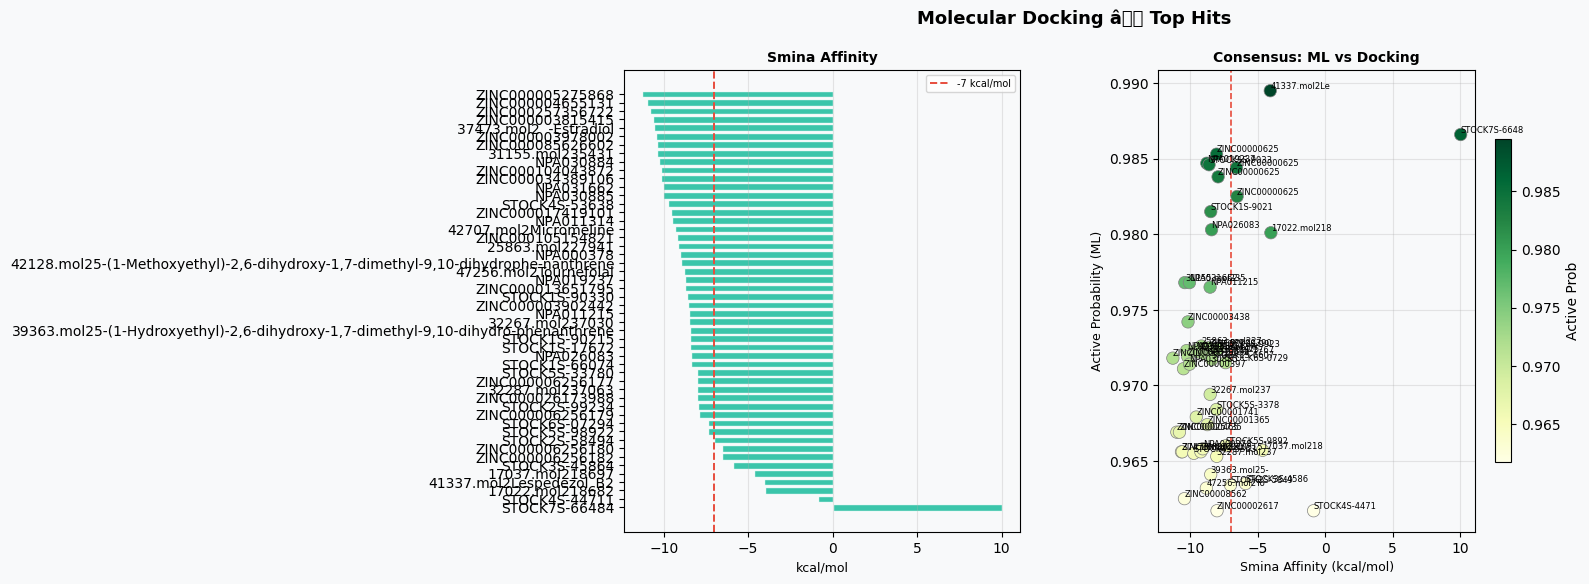

Figure saved â fig_docking_results.png

[WARN] python-docx not installed. Run: pip install python-docx
       Word report skipped.


In [3]:
# Molecular Docking â 3D Generation | Active Site Detection | Smina | GNINA
import os, json, re, glob, shutil, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rdkit import Chem
from rdkit.Chem import AllChem, SDWriter, SDMolSupplier
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

BASE      = "/Users/abbaskhan/Desktop/ESR_beta_new/"
DOCK_DIR  = BASE + "docking_results/"
for d in [DOCK_DIR, DOCK_DIR+'ligands/', DOCK_DIR+'smina/', DOCK_DIR+'gnina/', DOCK_DIR+'Docking_complexes/']:
    os.makedirs(d, exist_ok=True)

TOP_N          = 50   # top hits to dock
BOX_PAD        = 8.0  # A padding around ligand extents
EXHAUSTIVENESS = 16
N_MODES        = 9
CPU            = 8

# ====== 1. TOOL CHECK =======================================================
def _find_tool(name):
    """Return absolute path to tool, checking PATH then common conda prefixes."""
    import shutil as _sh
    _hit = _sh.which(name)
    if _hit:
        import stat as _st
        if os.path.isfile(_hit) and os.access(_hit, os.X_OK) and os.path.getsize(_hit) > 1000:
            return _hit   # real executable
    # Search known conda prefixes
    _prefixes = [
        os.path.expanduser("~/miniconda3"),
        os.path.expanduser("~/anaconda3"),
        "/opt/homebrew/Caskroom/miniconda/base",
        "/opt/conda",
        "/usr/local/anaconda3",
    ]
    for _pfx in _prefixes:
        _p = os.path.join(_pfx, "bin", name)
        if os.path.isfile(_p) and os.access(_p, os.X_OK) and os.path.getsize(_p) > 1000:
            return _p
    return None

SMINA_BIN  = _find_tool("smina")
GNINA_BIN  = _find_tool("gnina")
OBABEL_BIN = _find_tool("obabel")
SMINA_OK   = SMINA_BIN  is not None
GNINA_OK   = GNINA_BIN  is not None
OBABEL_OK  = OBABEL_BIN is not None
print("Tool check:")
print(f'  smina  : {SMINA_BIN  if SMINA_OK  else "NOT FOUND — install: conda install -c conda-forge smina"}')
print(f'  gnina  : {GNINA_BIN  if GNINA_OK  else "NOT FOUND — optional (conda install -c conda-forge gnina)"}')
print(f'  obabel : {OBABEL_BIN if OBABEL_OK else "NOT FOUND — install: conda install -c conda-forge openbabel"}')
if not SMINA_OK and not GNINA_OK:
    raise RuntimeError("Neither smina nor gnina found. Install at least one before running this cell.")

# ====== 2. LOAD TOP HITS ====================================================
vs_path = BASE + "virtual_screening_combined.csv"
if not os.path.exists(vs_path):
    raise FileNotFoundError(f'{vs_path} not found. Run the Virtual Screening cell first.')
df_vs = pd.read_csv(vs_path)
if 'InDomain' in df_vs.columns and (df_vs['InDomain'] == 'In-Domain').any():
    df_pool = df_vs[df_vs['InDomain'] == 'In-Domain'].copy()
else:
    df_pool = df_vs.copy()
df_hits = df_pool.head(TOP_N).reset_index(drop=True)
print(f'\n{len(df_hits)} compounds selected for docking:')
display(df_hits[['Name','Smiles','Active_Probability','InDomain']].reset_index(drop=True))

# ====== 3. FIND RECEPTOR PDB ================================================
_pdbs = (glob.glob(BASE + '*.pdb') +
         glob.glob(BASE + '**/*.pdb', recursive=True))
if not _pdbs:
    raise FileNotFoundError(
        f'No PDB file found in {BASE}.\n'
        'Place your protein-ligand complex PDB file in that folder.')
# Prefer a complex (contains HETATM non-water)
receptor_pdb = _pdbs[0]
for _p in _pdbs:
    _txt = open(_p).read()
    if 'HETATM' in _txt and 'HOH' not in _txt.replace('HETATM','')[:50]:
        receptor_pdb = _p; break
print(f'\nReceptor  : {receptor_pdb}')

# ====== 4. ACTIVE SITE FROM CO-CRYSTALLISED LIGAND ==========================
# Parse all non-water HETATM atoms to get binding-box centre + size
hetatm_xyz = []
with open(receptor_pdb) as _fh:
    for _ln in _fh:
        if not _ln.startswith('HETATM'): continue
        if _ln[17:20].strip().upper() == 'HOH': continue
        try:
            hetatm_xyz.append([float(_ln[30:38]), float(_ln[38:46]), float(_ln[46:54])])
        except ValueError:
            pass
if not hetatm_xyz:
    raise ValueError(
        'No non-water HETATM atoms found in PDB.\n'
        'Provide a protein-ligand co-crystal PDB so the binding site can be located.')
_coords  = np.array(hetatm_xyz)
center   = _coords.mean(axis=0)       # binding-box centre
box_size = _coords.max(axis=0) - _coords.min(axis=0) + BOX_PAD  # extent + padding
box_size = np.maximum(box_size, 22.5)     # minimum 15 A on each side
print(f'Active site centre : ({center[0]:.2f}, {center[1]:.2f}, {center[2]:.2f})')
print(f'Box size (A)       : ({box_size[0]:.1f} x {box_size[1]:.1f} x {box_size[2]:.1f})')

# ====== 5. PREPARE RECEPTOR (protein-only, strip co-crystallised ligand) =====
_prot_pdb   = DOCK_DIR + "receptor_protein_only.pdb"
_rec_pdbqt  = DOCK_DIR + "receptor.pdbqt"

# Always write a clean protein-only PDB (ATOM/TER lines only)
with open(receptor_pdb) as _rf, open(_prot_pdb, "w") as _wf:
    for _ln in _rf:
        if _ln.startswith(("ATOM", "TER", "END")):
            _wf.write(_ln)
print(f"Protein-only PDB : {_prot_pdb}")

# Convert to PDBQT (force rebuild if stale)
if OBABEL_OK:
    _r = subprocess.run(
        [OBABEL_BIN, _prot_pdb, "-O", _rec_pdbqt, "-xr"],
        capture_output=True, text=True)
    if os.path.exists(_rec_pdbqt) and os.path.getsize(_rec_pdbqt) > 100:
        print(f"Receptor PDBQT   : {_rec_pdbqt}")
    else:
        print(f"[WARN] obabel PDBQT conversion failed — using PDB directly")
        print(f"       stderr: {_r.stderr[:300]}")
        _rec_pdbqt = _prot_pdb
else:
    _rec_pdbqt = _prot_pdb
    print("obabel not found - using protein-only PDB as receptor.")

# ====== 6. 3-D CONFORMER GENERATION (ETKDGv3 + MMFF94) =====================
print('\nGenerating 3-D conformers...')
_lig_sdfs = {}
for _, _row in df_hits.iterrows():
    _name  = re.sub(r'[^A-Za-z0-9_-]', '_', str(_row['Name']))[:40]
    _smi   = str(_row['Smiles'])
    _sdf   = DOCK_DIR + f'ligands/{_name}.sdf'
    _mol   = Chem.MolFromSmiles(_smi)
    if _mol is None:
        print(f'  [SKIP] bad SMILES: {_name}'); continue
    _mol = Chem.AddHs(_mol)
    _ps  = AllChem.ETKDGv3()
    _ps.randomSeed = 42
    if AllChem.EmbedMolecule(_mol, _ps) == -1:
        _ps.useRandomCoords = True
        AllChem.EmbedMolecule(_mol, _ps)
    AllChem.MMFFOptimizeMolecule(_mol)
    _mol.SetProp('_Name', _name)
    _w = SDWriter(_sdf); _w.write(_mol); _w.close()
    _lig_sdfs[_name] = _sdf
    print(f'  {_name}: 3-D OK')
print(f'{len(_lig_sdfs)} ligands prepared.')

# ====== 7. DOCKING HELPERS ==================================================
def _base_cmd(tool_path, lig, out, log):
    return [
        tool_path,
        '--receptor',       _rec_pdbqt,
        '--ligand',         lig,
        '--out',            out,
        '--log',            log,
        '--center_x',       f'{center[0]:.3f}',
        '--center_y',       f'{center[1]:.3f}',
        '--center_z',       f'{center[2]:.3f}',
        '--size_x',         f'{box_size[0]:.1f}',
        '--size_y',         f'{box_size[1]:.1f}',
        '--size_z',         f'{box_size[2]:.1f}',
        '--exhaustiveness', str(EXHAUSTIVENESS),
        '--num_modes',      str(N_MODES),
        '--cpu',            str(CPU),
    ]

def _parse_vina_score(sdf_path, log_path):
    """Extract best Vina/Smina affinity from output SDF (minimizedAffinity prop) or log."""
    # Try SDF property first (most reliable)
    if os.path.exists(sdf_path):
        for _m in SDMolSupplier(sdf_path, removeHs=False):
            if _m is not None and _m.HasProp('minimizedAffinity'):
                return float(_m.GetProp('minimizedAffinity'))
    # Fall back to log parsing
    if os.path.exists(log_path):
        for _l in open(log_path):
            _mt = re.search(r'^\s*1\s+([-\d.]+)', _l)
            if _mt: return float(_mt.group(1))
    return float('nan')

def _parse_gnina_scores(sdf_path, log_path):
    """Return (vina_score, cnn_score, cnn_affinity) from GNINA output SDF."""
    vina = cnn_s = cnn_a = float('nan')
    if os.path.exists(sdf_path):
        for _m in SDMolSupplier(sdf_path, removeHs=False):
            if _m is None: continue
            if _m.HasProp('minimizedAffinity'): vina  = float(_m.GetProp('minimizedAffinity'))
            if _m.HasProp('CNNscore'):          cnn_s = float(_m.GetProp('CNNscore'))
            if _m.HasProp('CNNaffinity'):       cnn_a = float(_m.GetProp('CNNaffinity'))
            break   # best pose only
    if any(np.isnan(v) for v in [vina, cnn_s, cnn_a]):
        # fall back to log
        if os.path.exists(log_path):
            for _l in open(log_path):
                _mt = re.search(r'^\s*1\s+([-\d.]+)', _l)
                if _mt and np.isnan(vina): vina = float(_mt.group(1))
    return vina, cnn_s, cnn_a

# ====== 8. SMINA DOCKING ====================================================
smina_results = {}
if SMINA_OK:
    print('\nRunning Smina...')
    for _nm, _sdf in _lig_sdfs.items():
        _out = DOCK_DIR + f'smina/{_nm}_docked.sdf'
        _log = DOCK_DIR + f'smina/{_nm}.log'
        _cmd_list = _base_cmd(SMINA_BIN, _sdf, _out, _log)
        _res = subprocess.run(_cmd_list, capture_output=True, text=True)
        _sc  = _parse_vina_score(_out, _log)
        smina_results[_nm] = _sc
        _tag = f'{_sc:.3f} kcal/mol' if not np.isnan(_sc) else 'FAILED'
        print(f'  {_nm:<40} {_tag}')
else:
    print('\nSmina not available - skipping.')

# ====== 9. GNINA DOCKING + CNN RESCORING ====================================
gnina_vina   = {}
gnina_cnn_s  = {}
gnina_cnn_a  = {}
if GNINA_OK:
    print('\nRunning GNINA (Vina + CNN scoring)...')
    for _nm, _sdf in _lig_sdfs.items():
        _out = DOCK_DIR + f'gnina/{_nm}_docked.sdf'
        _log = DOCK_DIR + f'gnina/{_nm}.log'
        _cmd_list = _base_cmd(GNINA_BIN, _sdf, _out, _log) + ['--cnn_scoring', 'rescore']
        _res = subprocess.run(_cmd_list, capture_output=True, text=True)
        _v, _cs, _ca = _parse_gnina_scores(_out, _log)
        gnina_vina[_nm]  = _v
        gnina_cnn_s[_nm] = _cs
        gnina_cnn_a[_nm] = _ca
        _tag = (f'Vina={_v:.3f}  CNNscore={_cs:.3f}  CNNaffinity={_ca:.3f}'
                if not np.isnan(_v) else 'FAILED')
        print(f'  {_nm:<40} {_tag}')
else:
    print('\nGNINA not available - skipping.')


# ====== 9b. SAVE PROTEIN-LIGAND COMPLEXES AS PDB ===========================
COMPLEX_DIR = DOCK_DIR + "Docking_complexes/"
print("\nSaving docking complexes...")
_saved_complexes = []
for _nm, _sdf_src in _lig_sdfs.items():
    # Pick best available docked pose (smina preferred)
    _pose_sdf = None
    if SMINA_OK:
        _cand = DOCK_DIR + f"smina/{_nm}_docked.sdf"
        if os.path.exists(_cand) and os.path.getsize(_cand) > 50: _pose_sdf = _cand
    if _pose_sdf is None and GNINA_OK:
        _cand = DOCK_DIR + f"gnina/{_nm}_docked.sdf"
        if os.path.exists(_cand) and os.path.getsize(_cand) > 50: _pose_sdf = _cand
    if _pose_sdf is None:
        print(f"  [SKIP] no docked pose for {_nm}"); continue
    # Convert best pose SDF → PDB via obabel or RDKit
    _lig_pdb = COMPLEX_DIR + f"{_nm}_ligand.pdb"
    _complex_pdb = COMPLEX_DIR + f"{_nm}_complex.pdb"
    _ok = False
    if OBABEL_OK:
        _r = subprocess.run([OBABEL_BIN, _pose_sdf, "-O", _lig_pdb,
                             "-f", "1", "-l", "1"],   # first pose only
                            capture_output=True, text=True)
        _ok = os.path.exists(_lig_pdb) and os.path.getsize(_lig_pdb) > 50
    if not _ok:
        # RDKit fallback
        try:
            from rdkit.Chem import PDBWriter as _PDBW
            _pm = next((m for m in SDMolSupplier(_pose_sdf, removeHs=False) if m), None)
            if _pm:
                _w = _PDBW(_lig_pdb); _w.write(_pm); _w.close()
                _ok = True
        except Exception: pass
    if not _ok:
        print(f"  [SKIP] could not convert pose to PDB for {_nm}"); continue
    # Concatenate protein + ligand PDB → complex
    with open(_complex_pdb, "w") as _cf:
        with open(_prot_pdb) as _pf: _cf.write(_pf.read())
        _cf.write("\nREMARK  Docked ligand: " + _nm + "\n")
        with open(_lig_pdb) as _lf: _cf.write(_lf.read())
    _saved_complexes.append(_complex_pdb)
    print(f"  {_nm}: {_complex_pdb}")
print(f"{len(_saved_complexes)} complex PDBs saved to {COMPLEX_DIR}")

# ====== 10. RESULTS TABLE ===================================================
rows = []
for _, _row in df_hits.iterrows():
    _nm = re.sub(r'[^A-Za-z0-9_-]', '_', str(_row['Name']))[:40]
    rows.append({
        'Name'               : _row['Name'],
        'Active_Probability' : _row['Active_Probability'],
        'InDomain'           : _row.get('InDomain', 'N/A'),
        'Smina_Affinity'     : smina_results.get(_nm, float('nan')),
        'GNINA_Vina'         : gnina_vina.get(_nm,   float('nan')),
        'GNINA_CNNscore'     : gnina_cnn_s.get(_nm,  float('nan')),
        'GNINA_CNNaffinity'  : gnina_cnn_a.get(_nm,  float('nan')),
    })
df_dock = pd.DataFrame(rows)

# Sort by best available docking score (lower affinity = better)
_score_col = next((c for c in ['Smina_Affinity','GNINA_Vina','GNINA_CNNaffinity']
                   if not df_dock[c].isna().all()), None)
if _score_col:
    df_dock = df_dock.sort_values(_score_col).reset_index(drop=True)
df_dock.index += 1

_fmt = {
    'Active_Probability' : '{:.4f}',
    'Smina_Affinity'     : lambda x: f'{x:.3f}' if x == x else 'N/A',
    'GNINA_Vina'         : lambda x: f'{x:.3f}' if x == x else 'N/A',
    'GNINA_CNNscore'     : lambda x: f'{x:.3f}' if x == x else 'N/A',
    'GNINA_CNNaffinity'  : lambda x: f'{x:.3f}' if x == x else 'N/A',
}
_grad_cols = [c for c in ['Smina_Affinity','GNINA_Vina','GNINA_CNNaffinity']
              if not df_dock[c].isna().all()]
_styled = (df_dock.style
    .background_gradient(subset=['Active_Probability'], cmap='YlGn')
    .background_gradient(subset=_grad_cols, cmap='RdYlGn_r')
    .format(_fmt)
    .set_caption('Top Hits â Virtual Screening + Molecular Docking Scores'))
print('\n' + '='*70)
print('DOCKING RESULTS')
print('='*70)
display(_styled)

_out_csv = BASE + 'docking_summary_all.csv'
df_dock.to_csv(_out_csv, index_label='Rank')
print(f'Saved â {_out_csv}')

# ====== 11. FIGURE ==========================================================
TEAL   = '#1ABC9C'; PURPLE = '#9B59B6'; RED = '#E74C3C'
LIGHT  = '#F8F9FA'
_avail = [(c, col) for c, col in
          [('Smina_Affinity', TEAL), ('GNINA_Vina', PURPLE), ('GNINA_CNNaffinity', '#E67E22')]
          if not df_dock[c].isna().all()]
if _avail:
    _nc   = len(_avail) + 1
    _fig  = plt.figure(figsize=(6*_nc, 6))
    _gs   = gridspec.GridSpec(1, _nc, figure=_fig, wspace=0.35)
    _fig.patch.set_facecolor(LIGHT)

    for _i, (_col, _clr) in enumerate(_avail):
        _ax = _fig.add_subplot(_gs[_i])
        _df = df_dock[['Name', _col]].dropna()
        _ax.barh(_df['Name'], _df[_col], color=_clr, alpha=0.85, edgecolor='white')
        _ax.axvline(-7.0, color=RED, ls='--', lw=1.4, label='-7 kcal/mol')
        _ax.invert_yaxis()
        _ax.set_xlabel('kcal/mol', fontsize=9)
        _ax.set_title(_col.replace('_', ' '), fontweight='bold', fontsize=10)
        _ax.legend(fontsize=7)
        _ax.set_facecolor(LIGHT)
        _ax.grid(axis='x', alpha=0.3)

    # Consensus scatter: Active_Probability vs best docking score
    _ax2  = _fig.add_subplot(_gs[-1])
    _xc   = _avail[0][0]
    _df2  = df_dock[['Name','Active_Probability',_xc]].dropna()
    _sc   = _ax2.scatter(_df2[_xc], _df2['Active_Probability'],
                         s=80, c=_df2['Active_Probability'], cmap='YlGn',
                         edgecolors='grey', linewidth=0.5, zorder=3)
    for _, _r in _df2.iterrows():
        _ax2.annotate(_r['Name'][:12], (_r[_xc], _r['Active_Probability']),
                      fontsize=6, ha='left', va='bottom')
    _ax2.axvline(-7.0, color=RED, ls='--', lw=1.2)
    _ax2.set_xlabel(_xc.replace('_',' ') + ' (kcal/mol)', fontsize=9)
    _ax2.set_ylabel('Active Probability (ML)', fontsize=9)
    _ax2.set_title('Consensus: ML vs Docking', fontweight='bold', fontsize=10)
    _ax2.set_facecolor(LIGHT)
    _ax2.grid(alpha=0.3)
    plt.colorbar(_sc, ax=_ax2, label='Active Prob', shrink=0.7)

    _fig.suptitle('Molecular Docking â Top Hits', fontsize=13, fontweight='bold')
    plt.savefig(BASE + 'fig_docking_results.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
    plt.show()
    print('Figure saved â fig_docking_results.png')

# ====== 12. WORD REPORT WITH 2-D STRUCTURES ================================
try:
    from docx import Document as _DocX
    from docx.shared import Inches as _In, Pt as _Pt, RGBColor as _RGB
    from docx.enum.text import WD_ALIGN_PARAGRAPH as _WA
    from docx.oxml.ns import qn as _qn
    import io as _io
    from rdkit.Chem import Draw as _Draw

    _doc = _DocX()
    _doc.core_properties.author = "ESR-beta ML Pipeline"
    _h = _doc.add_heading("Molecular Docking Results — Top Hits", 0)
    _h.alignment = _WA.CENTER
    _doc.add_paragraph(
        f"Receptor: {receptor_pdb}\n"
        f"Active site centre: ({center[0]:.2f}, {center[1]:.2f}, {center[2]:.2f}) Å\n"
        f"Box size: {box_size[0]:.1f} × {box_size[1]:.1f} × {box_size[2]:.1f} Å"
    )
    _doc.add_paragraph("")

    # Build column list dynamically
    _score_cols = [c for c in ["Smina_Affinity","GNINA_Vina","GNINA_CNNscore","GNINA_CNNaffinity"]
                   if c in df_dock.columns and not df_dock[c].isna().all()]
    _hdr_cols = ["Rank", "2D Structure", "Name", "Active\nProb", "In\nDomain"] + _score_cols
    _tbl = _doc.add_table(rows=1, cols=len(_hdr_cols))
    _tbl.style = "Table Grid"

    # Header row
    _hr = _tbl.rows[0]
    for _ci, _ch in enumerate(_hdr_cols):
        _cell = _hr.cells[_ci]
        _cell.text = _ch
        _run = _cell.paragraphs[0].runs[0]
        _run.bold = True
        _run.font.size = _Pt(9)
        _cell.paragraphs[0].alignment = _WA.CENTER

    # Data rows
    for _rank, (_ridx, _row) in enumerate(df_dock.iterrows(), start=1):
        _nm2 = re.sub(r"[^A-Za-z0-9_-]", "_", str(_row["Name"]))[:40]
        _dr  = _tbl.add_row()
        _ci  = 0
        # Rank
        _dr.cells[_ci].text = str(_rank); _ci += 1
        # 2D Structure image
        _smi2 = df_vs.loc[df_vs["Name"] == _row["Name"], "Smiles"]
        _img_cell = _dr.cells[_ci]; _ci += 1
        if len(_smi2) > 0:
            _m2d = Chem.MolFromSmiles(_smi2.values[0])
            if _m2d:
                AllChem.Compute2DCoords(_m2d)
                _pil = _Draw.MolToImage(_m2d, size=(200, 150))
                _buf = _io.BytesIO()
                _pil.save(_buf, format="PNG")
                _buf.seek(0)
                _p = _img_cell.paragraphs[0]
                _p.alignment = _WA.CENTER
                _run2 = _p.add_run()
                _run2.add_picture(_buf, width=_In(1.6))
        # Name
        _dr.cells[_ci].text = str(_row["Name"]); _ci += 1
        # Active Probability
        _v = _row["Active_Probability"]
        _dr.cells[_ci].text = f"{_v:.4f}" if _v == _v else "N/A"; _ci += 1
        # InDomain
        _dr.cells[_ci].text = str(_row.get("InDomain", "N/A")); _ci += 1
        # Score columns
        for _sc_col in _score_cols:
            _sv = _row.get(_sc_col, float("nan"))
            _dr.cells[_ci].text = f"{_sv:.3f}" if _sv == _sv else "N/A"
            _ci += 1
        # Font size for all cells
        for _c2 in _dr.cells:
            for _p2 in _c2.paragraphs:
                for _r2 in _p2.runs:
                    _r2.font.size = _Pt(8)
                _p2.alignment = _WA.CENTER

    _word_path = BASE + "docking_report.docx"
    _doc.save(_word_path)
    print(f"\nWord report saved → {_word_path}")

except ImportError:
    print("\n[WARN] python-docx not installed. Run: pip install python-docx")
    print("       Word report skipped.")
except Exception as _we:
    print(f"\n[WARN] Word report failed: {_we}")


In [4]:
pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 18.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-docx]
Note: you may need to restart the kernel to use updated packages.


In [6]:
# New Compounds Virtual Screening
import os, json
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors, Descriptors, AllChem
from rdkit.Chem import rdFingerprintGenerator
from IPython.display import display

BASE     = "/Users/abbaskhan/Desktop/ESR_beta_new/"
SAVE_DIR = BASE + "saved_model/"

# ── Load required artifacts ────────────────────────────────────────────────────
_missing_files = [p for p in ["best_model.pkl", "best_scaler.pkl", "feature_columns.json"]
                  if not os.path.exists(SAVE_DIR + p)]
if _missing_files:
    raise FileNotFoundError(
        f"Required files not found in {SAVE_DIR}:\n"
        + "\n".join(f"  ✗  {f}" for f in _missing_files)
        + "\n\nRun the 'Save Best Model' cell first."
    )

model  = joblib.load(SAVE_DIR + "best_model.pkl")
scaler = joblib.load(SAVE_DIR + "best_scaler.pkl")
with open(SAVE_DIR + "feature_columns.json") as fh:
    feat_cols_saved = json.load(fh)

# Feature medians for NaN imputation (optional — falls back to 0)
_med_path = SAVE_DIR + "feature_medians.json"
if os.path.exists(_med_path):
    with open(_med_path) as fh:
        feat_medians = json.load(fh)
else:
    feat_medians = {col: 0.0 for col in feat_cols_saved}
    print("[WARN] feature_medians.json not found — using 0 for NaN imputation.")

# AD artifacts (optional — AD column shows 'N/A' if absent)
_ad_config_path = SAVE_DIR + "ad_config.json"
_ad_fps_path    = SAVE_DIR + "train_fps_ecfp4.npy"
_ad_enabled     = os.path.exists(_ad_config_path) and os.path.exists(_ad_fps_path)

if _ad_enabled:
    with open(_ad_config_path) as fh:
        ad_cfg = json.load(fh)
    _tr_fp_matrix = np.load(_ad_fps_path)
    train_fps = []
    for row in _tr_fp_matrix:
        fp = DataStructs.ExplicitBitVect(int(ad_cfg["fp_size"]))
        fp.SetBitsFromList(np.where(row)[0].tolist())
        train_fps.append(fp)
    fpgen_vs     = rdFingerprintGenerator.GetMorganGenerator(
                       radius=int(ad_cfg["fp_radius"]), fpSize=int(ad_cfg["fp_size"]))
    KNN_K_VS     = int(ad_cfg["knn_k"])
    AD_THRESHOLD = float(ad_cfg["ad_threshold"])
    _model_label = ad_cfg.get("model_name", "")
else:
    print("[WARN] AD artifacts not found — InDomain column will be 'N/A'.")
    _model_label = ""

print(f"Model     : {_model_label or type(model).__name__}")
print(f"Features  : {len(feat_cols_saved)}")
print(f"AD        : {'enabled' if _ad_enabled else 'disabled (artifacts missing)'}")


# ── Descriptor computation (identical to training pipeline) ───────────────────
def _calc_2d(mol):
    return {
        "MolWt"             : Descriptors.MolWt(mol),
        "LogP"              : Descriptors.MolLogP(mol),
        "TPSA"              : rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors"        : rdMolDescriptors.CalcNumHBD(mol),
        "NumHAcceptors"     : rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds" : rdMolDescriptors.CalcNumRotatableBonds(mol),
        "NumAromaticRings"  : rdMolDescriptors.CalcNumAromaticRings(mol),
        "RingCount"         : rdMolDescriptors.CalcNumRings(mol),
        "FractionCSP3"      : rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount"    : mol.GetNumHeavyAtoms(),
        "Chi0"              : Descriptors.Chi0n(mol),
        "Chi1"              : Descriptors.Chi1n(mol),
        "Chi2"              : Descriptors.Chi2n(mol),
        "Chi3"              : Descriptors.Chi3n(mol),
        "Chi4"              : Descriptors.Chi4n(mol),
        "Kappa1"            : Descriptors.Kappa1(mol),
        "Kappa2"            : Descriptors.Kappa2(mol),
        "Kappa3"            : Descriptors.Kappa3(mol),
        "BalabanJ"          : Descriptors.BalabanJ(mol),
        "EState_VSA1"       : Descriptors.EState_VSA1(mol),
        "EState_VSA2"       : Descriptors.EState_VSA2(mol),
        "EState_VSA3"       : Descriptors.EState_VSA3(mol),
        "EState_VSA4"       : Descriptors.EState_VSA4(mol),
        "EState_VSA5"       : Descriptors.EState_VSA5(mol),
        "EState_VSA6"       : Descriptors.EState_VSA6(mol),
        "EState_VSA7"       : Descriptors.EState_VSA7(mol),
        "EState_VSA8"       : Descriptors.EState_VSA8(mol),
        "EState_VSA9"       : Descriptors.EState_VSA9(mol),
        "EState_VSA10"      : Descriptors.EState_VSA10(mol),
        "EState_VSA11"      : Descriptors.EState_VSA11(mol),
        "PEOE_VSA1"         : Descriptors.PEOE_VSA1(mol),
        "PEOE_VSA2"         : Descriptors.PEOE_VSA2(mol),
        "PEOE_VSA3"         : Descriptors.PEOE_VSA3(mol),
        "PEOE_VSA4"         : Descriptors.PEOE_VSA4(mol),
        "PEOE_VSA5"         : Descriptors.PEOE_VSA5(mol),
        "PEOE_VSA6"         : Descriptors.PEOE_VSA6(mol),
        "PEOE_VSA7"         : Descriptors.PEOE_VSA7(mol),
        "PEOE_VSA8"         : Descriptors.PEOE_VSA8(mol),
        "PEOE_VSA9"         : Descriptors.PEOE_VSA9(mol),
        "PEOE_VSA10"        : Descriptors.PEOE_VSA10(mol),
        "PEOE_VSA11"        : Descriptors.PEOE_VSA11(mol),
        "PEOE_VSA12"        : Descriptors.PEOE_VSA12(mol),
        "PEOE_VSA13"        : Descriptors.PEOE_VSA13(mol),
        "PEOE_VSA14"        : Descriptors.PEOE_VSA14(mol),
    }

_3D_NAN = {k: np.nan for k in ["PMI1","PMI2","PMI3","NPR1","NPR2",
                                 "RadiusOfGyration","Asphericity","Eccentricity",
                                 "InertialShapeFactor","SpherocityIndex"]}

def _calc_3d(mol):
    try:
        mh = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(mh, AllChem.ETKDGv3()) == -1:
            return _3D_NAN.copy()
        AllChem.MMFFOptimizeMolecule(mh)
        return {
            "PMI1"               : rdMolDescriptors.CalcPMI1(mh),
            "PMI2"               : rdMolDescriptors.CalcPMI2(mh),
            "PMI3"               : rdMolDescriptors.CalcPMI3(mh),
            "NPR1"               : rdMolDescriptors.CalcNPR1(mh),
            "NPR2"               : rdMolDescriptors.CalcNPR2(mh),
            "RadiusOfGyration"   : rdMolDescriptors.CalcRadiusOfGyration(mh),
            "Asphericity"        : rdMolDescriptors.CalcAsphericity(mh),
            "Eccentricity"       : rdMolDescriptors.CalcEccentricity(mh),
            "InertialShapeFactor": rdMolDescriptors.CalcInertialShapeFactor(mh),
            "SpherocityIndex"    : rdMolDescriptors.CalcSpherocityIndex(mh),
        }
    except Exception:
        return _3D_NAN.copy()

def _compute_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    d = {}
    d.update(_calc_2d(mol))
    d.update(_calc_3d(mol))
    return d

def _compute_ad_score(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    fp   = fpgen_vs.GetFingerprint(mol)
    sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    return float(np.mean(sorted(sims, reverse=True)[:KNN_K_VS]))


# ── Input loading: auto-detect CSV or SDF ─────────────────────────────────────
INPUT_FILE = BASE + "pharma_updated_data.csv"   # ← set your file path here
#INPUT_FILE = BASE + "TCM-R5 filtered.sdf"  # SDF also supported

def _load_compounds(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".sdf":
        from rdkit.Chem import SDMolSupplier
        suppl = SDMolSupplier(path, sanitize=True, removeHs=True)
        rows  = []
        for mol in suppl:
            if mol is None:
                continue
            name = mol.GetProp("_Name").strip() if mol.HasProp("_Name") else f"mol_{len(rows)}"
            smi  = Chem.MolToSmiles(mol)
            if smi:
                rows.append({"Name": name, "Smiles": smi})
        return pd.DataFrame(rows)
    df         = pd.read_csv(path)
    name_col   = next((c for c in df.columns if c.lower() in
                       ("name", "compound", "compound_name", "id", "molecule")), df.columns[0])
    smiles_col = next((c for c in df.columns if c.lower() in
                       ("smiles", "smi", "smiles_string", "canonical_smiles")), df.columns[1])
    return df[[name_col, smiles_col]].rename(columns={name_col: "Name", smiles_col: "Smiles"})


df_input = _load_compounds(INPUT_FILE)
print(f"Loaded {len(df_input)} compounds from {os.path.basename(INPUT_FILE)}")


# ── Compute descriptors ────────────────────────────────────────────────────────
print("Computing descriptors (3D conformers may take a moment)...")
rows_valid = []
for _, row in df_input.iterrows():
    feat = _compute_features(str(row["Smiles"]))
    if feat is None:
        print(f"  [SKIP] Invalid SMILES — {row['Name']}")
        continue
    feat["Name"]   = row["Name"]
    feat["Smiles"] = row["Smiles"]
    rows_valid.append(feat)

df_feat = pd.DataFrame(rows_valid)
print(f"  Valid: {len(df_feat)} / {len(df_input)}")

# Select and order features; impute NaN with saved training medians
X_new = df_feat[feat_cols_saved].copy()
for col, med in feat_medians.items():
    X_new[col] = X_new[col].fillna(med)
X_new_sc = scaler.transform(X_new.values.astype(float))


# ── Predict ────────────────────────────────────────────────────────────────────
probs  = model.predict_proba(X_new_sc)[:, 1]
labels = ["Active" if p >= 0.5 else "Inactive" for p in probs]


# ── Applicability domain ───────────────────────────────────────────────────────
if _ad_enabled:
    print("Computing AD scores...")
    ad_scores = np.array([_compute_ad_score(s) for s in df_feat["Smiles"]])
    in_domain = ["In-Domain" if s >= AD_THRESHOLD else "Out-of-Domain" for s in ad_scores]
else:
    in_domain = ["N/A"] * len(df_feat)


# ── Assemble, save, display ────────────────────────────────────────────────────
df_results = pd.DataFrame({
    "Name"               : df_feat["Name"].values,
    "Smiles"             : df_feat["Smiles"].values,
    "Active_Probability" : np.round(probs, 4),
    "Predicted_Class"    : labels,
    "InDomain"           : in_domain,
}).sort_values("Active_Probability", ascending=False).reset_index(drop=True)

out_path = BASE + "besthitsfile_results.csv"
df_results.to_csv(out_path, index=False)
print(f"Results saved -> {out_path}")

n_active = (df_results["Predicted_Class"] == "Active").sum()
n_in     = (df_results["InDomain"] == "In-Domain").sum() if _ad_enabled else None
print(f"\nScreening summary: {len(df_results)} compounds screened")
print(f"  Predicted Active : {n_active}  ({100*n_active/len(df_results):.1f}%)")
if n_in is not None:
    print(f"  In-Domain        : {n_in}  ({100*n_in/len(df_results):.1f}%)")

print(f"\nTop 10 hits (sorted by Active_Probability):")
display(df_results.head(10).style
        .background_gradient(subset=["Active_Probability"], cmap="YlGn")
        .format({"Active_Probability": "{:.4f}"})
        .set_caption(f"Virtual Screening — Top 10 Hits  |  {_model_label or type(model).__name__}"))

Model     : GradBoost
Features  : 39
AD        : enabled
Loaded 1036 compounds from pharma_updated_data.csv
Computing descriptors (3D conformers may take a moment)...
  Valid: 1036 / 1036
Computing AD scores...
Results saved -> /Users/abbaskhan/Desktop/ESR_beta_new/besthitsfile_results.csv

Screening summary: 1036 compounds screened
  Predicted Active : 99  (9.6%)
  In-Domain        : 647  (62.5%)

Top 10 hits (sorted by Active_Probability):


,Name,Smiles,Active_Probability,Predicted_Class,InDomain
0,0.983084,Oc1cc(Br)c2oc(-c3ccc(O)c(F)c3)nc2c1,0.9929,Active,In-Domain
1,0.214146,C/C=C(\C)c1cc(O)c(C)c2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9765,Active,In-Domain
2,0.997356,C/C=C(/C)c1cc(O)c(C)c2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9747,Active,In-Domain
3,0.442550,C[C@@H]1C[C@@]2(C)[C@H](O)CC[C@@H]2[C@H]2CCc3cc(O)ccc3[C@@H]21,0.9500,Active,In-Domain
4,0.975474,C[C@@]12CC=C3c4ccc(O)cc4CC[C@@H]3[C@H]1CC[C@H]2O,0.9440,Active,In-Domain
5,0.888341,C/C=C(\C)c1cc([O-])c(C)c2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9246,Active,In-Domain
6,0.955024,C/C=C(/C)c1cc(O)c(C)c2c1Oc1cc([O-])cc(C)c1C(=O)O2,0.9212,Active,In-Domain
7,0.911675,O=C1C[C@H](c2ccc3ncccc3c2)c2c(cc(O)c3c(=O)cc(-c4ccc(O)cc4)oc23)O1,0.9162,Active,In-Domain
8,0.900671,[O-]c1ccc(-c2nc3cc(O)cc(Br)c3o2)cc1F,0.9162,Active,In-Domain
9,0.288540,C/C=C(/C)c1cc(O)c(C)c2c1Oc1c(C)c(O)cc(/C(C)=C/C)c1C(=O)O2,0.9070,Active,In-Domain


Tool check:
  smina  : /opt/homebrew/Caskroom/miniconda/base/bin/smina
  gnina  : NOT FOUND — optional (conda install -c conda-forge gnina)
  obabel : /opt/homebrew/bin/obabel

50 compounds selected for docking:


,Name,Smiles,Active_Probability,InDomain
0,0.983084,Oc1cc(Br)c2oc(-c3ccc(O)c(F)c3)nc2c1,0.9929,In-Domain
1,0.214146,C/C=C(\C)c1cc(O)c(C)c2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9765,In-Domain
2,0.997356,C/C=C(/C)c1cc(O)c(C)c2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9747,In-Domain
3,0.442550,C[C@@H]1C[C@@]2(C)[C@H](O)CC[C@@H]2[C@H]2CCc3c...,0.9500,In-Domain
4,0.975474,C[C@@]12CC=C3c4ccc(O)cc4CC[C@@H]3[C@H]1CC[C@H]2O,0.9440,In-Domain
5,0.888341,C/C=C(\C)c1cc([O-])c(C)c2c1Oc1cc(O)cc(C)c1C(=O)O2,0.9246,In-Domain
6,0.955024,C/C=C(/C)c1cc(O)c(C)c2c1Oc1cc([O-])cc(C)c1C(=O)O2,0.9212,In-Domain
7,0.911675,O=C1C[C@H](c2ccc3ncccc3c2)c2c(cc(O)c3c(=O)cc(-...,0.9162,In-Domain
8,0.900671,[O-]c1ccc(-c2nc3cc(O)cc(Br)c3o2)cc1F,0.9162,In-Domain
9,0.288540,C/C=C(/C)c1cc(O)c(C)c2c1Oc1c(C)c(O)cc(/C(C)=C/...,0.9070,In-Domain



Receptor  : /Users/abbaskhan/Desktop/ESR_beta_new/7XWQ.pdb
Active site centre : (-3.24, -7.85, -39.60)
Box size (A)       : (22.5 x 22.5 x 22.5)
Protein-only PDB : /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/receptor_protein_only.pdb
Receptor PDBQT   : /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/receptor.pdbqt

Generating 3-D conformers...
  0_9830844: 3-D OK
  0_2141464: 3-D OK
  0_9973556: 3-D OK
  0_4425501: 3-D OK
  0_9754742: 3-D OK
  0_88834095: 3-D OK
  0_955024: 3-D OK
  0_91167504: 3-D OK
  0_90067136: 3-D OK
  0_28854042: 3-D OK
  0_46542475: 3-D OK
  0_9639791: 3-D OK
  0_93749607: 3-D OK
  0_96124256: 3-D OK
  0_9844444: 3-D OK
  0_8590346: 3-D OK
  0_9942662: 3-D OK
  0_97892946: 3-D OK
  0_99696416: 3-D OK
  0_977874: 3-D OK
  0_92959744: 3-D OK
  0_44231266: 3-D OK
  0_88385075: 3-D OK
  0_97472906: 3-D OK
  0_9998368: 3-D OK
  0_82302237: 3-D OK
  0_8091885: 3-D OK
  0_718184: 3-D OK
  0_597943: 3-D OK
  0_50690466: 3-D OK
  0_9852485: 3-D OK
  0_01

[11:03:35] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  0_9830844                                -9.576 kcal/mol


...

[11:06:58] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  0_7035211                                -4.666 kcal/mol

GNINA not available - skipping.

Saving docking complexes...
  0_9830844: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_9830844_complex.pdb
  0_2141464: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_2141464_complex.pdb
  0_9973556: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_9973556_complex.pdb
  0_4425501: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_4425501_complex.pdb
  0_9754742: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_9754742_complex.pdb
  0_88834095: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_88834095_complex.pdb
  0_955024: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_955024_complex.pdb
  0_91167504: /Users/abbaskhan/Desktop/ESR_beta_new/docking_results/Docking_complexes/0_91167504_complex.pdb
  0_90067136: /Users/

,Name,Active_Probability,InDomain,Smina_Affinity,GNINA_Vina,GNINA_CNNscore,GNINA_CNNaffinity
1,0.975474,0.9440,In-Domain,-10.943,N/A,N/A,N/A
2,0.809188,0.7485,In-Domain,-10.614,N/A,N/A,N/A
3,0.442550,0.9500,In-Domain,-10.182,N/A,N/A,N/A
4,0.984444,0.8562,In-Domain,-10.121,N/A,N/A,N/A
5,0.983084,0.9929,In-Domain,-9.576,N/A,N/A,N/A
6,0.442313,0.7675,In-Domain,-9.525,N/A,N/A,N/A
7,0.661540,0.6748,In-Domain,-9.410,N/A,N/A,N/A
8,0.465425,0.8966,In-Domain,-9.097,N/A,N/A,N/A
9,0.011240,0.6987,In-Domain,-8.890,N/A,N/A,N/A
10,0.067319,0.6782,In-Domain,-8.847,N/A,N/A,N/A


Saved â /Users/abbaskhan/Desktop/ESR_beta_new/docking_summary_all.csv


IndexError: invalid index to scalar variable.

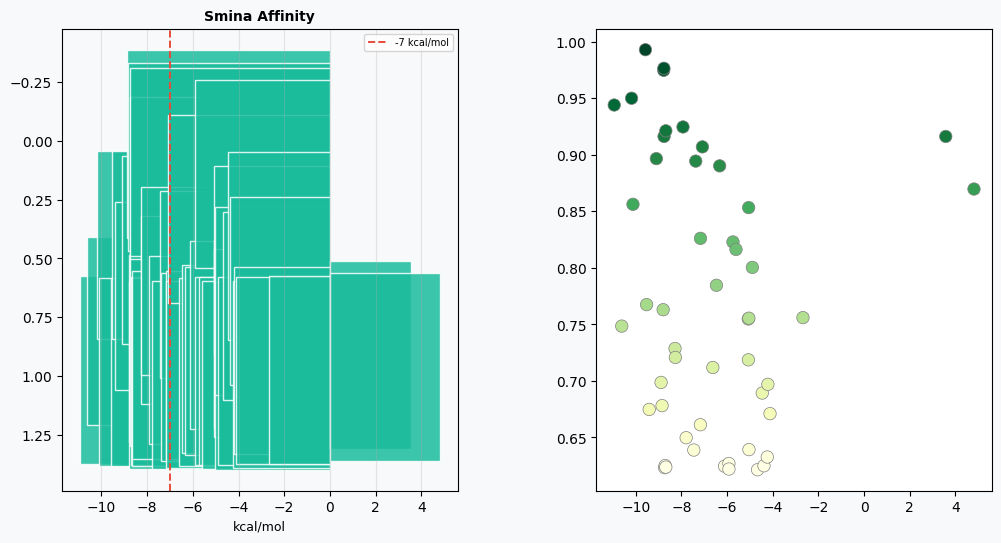

In [7]:
# Molecular Docking â 3D Generation | Active Site Detection | Smina | GNINA
import os, json, re, glob, shutil, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rdkit import Chem
from rdkit.Chem import AllChem, SDWriter, SDMolSupplier
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

BASE      = "/Users/abbaskhan/Desktop/ESR_beta_new/"
DOCK_DIR  = BASE + "docking_results/"
for d in [DOCK_DIR, DOCK_DIR+'ligands/', DOCK_DIR+'smina/', DOCK_DIR+'gnina/', DOCK_DIR+'Docking_complexes/']:
    os.makedirs(d, exist_ok=True)

TOP_N          = 50   # top hits to dock
BOX_PAD        = 8.0  # A padding around ligand extents
EXHAUSTIVENESS = 16
N_MODES        = 9
CPU            = 8

# ====== 1. TOOL CHECK =======================================================
def _find_tool(name):
    """Return absolute path to tool, checking PATH then common conda prefixes."""
    import shutil as _sh
    _hit = _sh.which(name)
    if _hit:
        import stat as _st
        if os.path.isfile(_hit) and os.access(_hit, os.X_OK) and os.path.getsize(_hit) > 1000:
            return _hit   # real executable
    # Search known conda prefixes
    _prefixes = [
        os.path.expanduser("~/miniconda3"),
        os.path.expanduser("~/anaconda3"),
        "/opt/homebrew/Caskroom/miniconda/base",
        "/opt/conda",
        "/usr/local/anaconda3",
    ]
    for _pfx in _prefixes:
        _p = os.path.join(_pfx, "bin", name)
        if os.path.isfile(_p) and os.access(_p, os.X_OK) and os.path.getsize(_p) > 1000:
            return _p
    return None

SMINA_BIN  = _find_tool("smina")
GNINA_BIN  = _find_tool("gnina")
OBABEL_BIN = _find_tool("obabel")
SMINA_OK   = SMINA_BIN  is not None
GNINA_OK   = GNINA_BIN  is not None
OBABEL_OK  = OBABEL_BIN is not None
print("Tool check:")
print(f'  smina  : {SMINA_BIN  if SMINA_OK  else "NOT FOUND — install: conda install -c conda-forge smina"}')
print(f'  gnina  : {GNINA_BIN  if GNINA_OK  else "NOT FOUND — optional (conda install -c conda-forge gnina)"}')
print(f'  obabel : {OBABEL_BIN if OBABEL_OK else "NOT FOUND — install: conda install -c conda-forge openbabel"}')
if not SMINA_OK and not GNINA_OK:
    raise RuntimeError("Neither smina nor gnina found. Install at least one before running this cell.")

# ====== 2. LOAD TOP HITS ====================================================
vs_path = BASE + "besthitsfile_results.csv"
if not os.path.exists(vs_path):
    raise FileNotFoundError(f'{vs_path} not found. Run the Virtual Screening cell first.')
df_vs = pd.read_csv(vs_path)
if 'InDomain' in df_vs.columns and (df_vs['InDomain'] == 'In-Domain').any():
    df_pool = df_vs[df_vs['InDomain'] == 'In-Domain'].copy()
else:
    df_pool = df_vs.copy()
df_hits = df_pool.head(TOP_N).reset_index(drop=True)
print(f'\n{len(df_hits)} compounds selected for docking:')
display(df_hits[['Name','Smiles','Active_Probability','InDomain']].reset_index(drop=True))

# ====== 3. FIND RECEPTOR PDB ================================================
_pdbs = (glob.glob(BASE + '*.pdb') +
         glob.glob(BASE + '**/*.pdb', recursive=True))
if not _pdbs:
    raise FileNotFoundError(
        f'No PDB file found in {BASE}.\n'
        'Place your protein-ligand complex PDB file in that folder.')
# Prefer a complex (contains HETATM non-water)
receptor_pdb = _pdbs[0]
for _p in _pdbs:
    _txt = open(_p).read()
    if 'HETATM' in _txt and 'HOH' not in _txt.replace('HETATM','')[:50]:
        receptor_pdb = _p; break
print(f'\nReceptor  : {receptor_pdb}')

# ====== 4. ACTIVE SITE FROM CO-CRYSTALLISED LIGAND ==========================
# Parse all non-water HETATM atoms to get binding-box centre + size
hetatm_xyz = []
with open(receptor_pdb) as _fh:
    for _ln in _fh:
        if not _ln.startswith('HETATM'): continue
        if _ln[17:20].strip().upper() == 'HOH': continue
        try:
            hetatm_xyz.append([float(_ln[30:38]), float(_ln[38:46]), float(_ln[46:54])])
        except ValueError:
            pass
if not hetatm_xyz:
    raise ValueError(
        'No non-water HETATM atoms found in PDB.\n'
        'Provide a protein-ligand co-crystal PDB so the binding site can be located.')
_coords  = np.array(hetatm_xyz)
center   = _coords.mean(axis=0)       # binding-box centre
box_size = _coords.max(axis=0) - _coords.min(axis=0) + BOX_PAD  # extent + padding
box_size = np.maximum(box_size, 22.5)     # minimum 15 A on each side
print(f'Active site centre : ({center[0]:.2f}, {center[1]:.2f}, {center[2]:.2f})')
print(f'Box size (A)       : ({box_size[0]:.1f} x {box_size[1]:.1f} x {box_size[2]:.1f})')

# ====== 5. PREPARE RECEPTOR (protein-only, strip co-crystallised ligand) =====
_prot_pdb   = DOCK_DIR + "receptor_protein_only.pdb"
_rec_pdbqt  = DOCK_DIR + "receptor.pdbqt"

# Always write a clean protein-only PDB (ATOM/TER lines only)
with open(receptor_pdb) as _rf, open(_prot_pdb, "w") as _wf:
    for _ln in _rf:
        if _ln.startswith(("ATOM", "TER", "END")):
            _wf.write(_ln)
print(f"Protein-only PDB : {_prot_pdb}")

# Convert to PDBQT (force rebuild if stale)
if OBABEL_OK:
    _r = subprocess.run(
        [OBABEL_BIN, _prot_pdb, "-O", _rec_pdbqt, "-xr"],
        capture_output=True, text=True)
    if os.path.exists(_rec_pdbqt) and os.path.getsize(_rec_pdbqt) > 100:
        print(f"Receptor PDBQT   : {_rec_pdbqt}")
    else:
        print(f"[WARN] obabel PDBQT conversion failed — using PDB directly")
        print(f"       stderr: {_r.stderr[:300]}")
        _rec_pdbqt = _prot_pdb
else:
    _rec_pdbqt = _prot_pdb
    print("obabel not found - using protein-only PDB as receptor.")

# ====== 6. 3-D CONFORMER GENERATION (ETKDGv3 + MMFF94) =====================
print('\nGenerating 3-D conformers...')
_lig_sdfs = {}
for _, _row in df_hits.iterrows():
    _name  = re.sub(r'[^A-Za-z0-9_-]', '_', str(_row['Name']))[:40]
    _smi   = str(_row['Smiles'])
    _sdf   = DOCK_DIR + f'ligands/{_name}.sdf'
    _mol   = Chem.MolFromSmiles(_smi)
    if _mol is None:
        print(f'  [SKIP] bad SMILES: {_name}'); continue
    _mol = Chem.AddHs(_mol)
    _ps  = AllChem.ETKDGv3()
    _ps.randomSeed = 42
    if AllChem.EmbedMolecule(_mol, _ps) == -1:
        _ps.useRandomCoords = True
        AllChem.EmbedMolecule(_mol, _ps)
    AllChem.MMFFOptimizeMolecule(_mol)
    _mol.SetProp('_Name', _name)
    _w = SDWriter(_sdf); _w.write(_mol); _w.close()
    _lig_sdfs[_name] = _sdf
    print(f'  {_name}: 3-D OK')
print(f'{len(_lig_sdfs)} ligands prepared.')

# ====== 7. DOCKING HELPERS ==================================================
def _base_cmd(tool_path, lig, out, log):
    return [
        tool_path,
        '--receptor',       _rec_pdbqt,
        '--ligand',         lig,
        '--out',            out,
        '--log',            log,
        '--center_x',       f'{center[0]:.3f}',
        '--center_y',       f'{center[1]:.3f}',
        '--center_z',       f'{center[2]:.3f}',
        '--size_x',         f'{box_size[0]:.1f}',
        '--size_y',         f'{box_size[1]:.1f}',
        '--size_z',         f'{box_size[2]:.1f}',
        '--exhaustiveness', str(EXHAUSTIVENESS),
        '--num_modes',      str(N_MODES),
        '--cpu',            str(CPU),
    ]

def _parse_vina_score(sdf_path, log_path):
    """Extract best Vina/Smina affinity from output SDF (minimizedAffinity prop) or log."""
    # Try SDF property first (most reliable)
    if os.path.exists(sdf_path):
        for _m in SDMolSupplier(sdf_path, removeHs=False):
            if _m is not None and _m.HasProp('minimizedAffinity'):
                return float(_m.GetProp('minimizedAffinity'))
    # Fall back to log parsing
    if os.path.exists(log_path):
        for _l in open(log_path):
            _mt = re.search(r'^\s*1\s+([-\d.]+)', _l)
            if _mt: return float(_mt.group(1))
    return float('nan')

def _parse_gnina_scores(sdf_path, log_path):
    """Return (vina_score, cnn_score, cnn_affinity) from GNINA output SDF."""
    vina = cnn_s = cnn_a = float('nan')
    if os.path.exists(sdf_path):
        for _m in SDMolSupplier(sdf_path, removeHs=False):
            if _m is None: continue
            if _m.HasProp('minimizedAffinity'): vina  = float(_m.GetProp('minimizedAffinity'))
            if _m.HasProp('CNNscore'):          cnn_s = float(_m.GetProp('CNNscore'))
            if _m.HasProp('CNNaffinity'):       cnn_a = float(_m.GetProp('CNNaffinity'))
            break   # best pose only
    if any(np.isnan(v) for v in [vina, cnn_s, cnn_a]):
        # fall back to log
        if os.path.exists(log_path):
            for _l in open(log_path):
                _mt = re.search(r'^\s*1\s+([-\d.]+)', _l)
                if _mt and np.isnan(vina): vina = float(_mt.group(1))
    return vina, cnn_s, cnn_a

# ====== 8. SMINA DOCKING ====================================================
smina_results = {}
if SMINA_OK:
    print('\nRunning Smina...')
    for _nm, _sdf in _lig_sdfs.items():
        _out = DOCK_DIR + f'smina/{_nm}_docked.sdf'
        _log = DOCK_DIR + f'smina/{_nm}.log'
        _cmd_list = _base_cmd(SMINA_BIN, _sdf, _out, _log)
        _res = subprocess.run(_cmd_list, capture_output=True, text=True)
        _sc  = _parse_vina_score(_out, _log)
        smina_results[_nm] = _sc
        _tag = f'{_sc:.3f} kcal/mol' if not np.isnan(_sc) else 'FAILED'
        print(f'  {_nm:<40} {_tag}')
else:
    print('\nSmina not available - skipping.')

# ====== 9. GNINA DOCKING + CNN RESCORING ====================================
gnina_vina   = {}
gnina_cnn_s  = {}
gnina_cnn_a  = {}
if GNINA_OK:
    print('\nRunning GNINA (Vina + CNN scoring)...')
    for _nm, _sdf in _lig_sdfs.items():
        _out = DOCK_DIR + f'gnina/{_nm}_docked.sdf'
        _log = DOCK_DIR + f'gnina/{_nm}.log'
        _cmd_list = _base_cmd(GNINA_BIN, _sdf, _out, _log) + ['--cnn_scoring', 'rescore']
        _res = subprocess.run(_cmd_list, capture_output=True, text=True)
        _v, _cs, _ca = _parse_gnina_scores(_out, _log)
        gnina_vina[_nm]  = _v
        gnina_cnn_s[_nm] = _cs
        gnina_cnn_a[_nm] = _ca
        _tag = (f'Vina={_v:.3f}  CNNscore={_cs:.3f}  CNNaffinity={_ca:.3f}'
                if not np.isnan(_v) else 'FAILED')
        print(f'  {_nm:<40} {_tag}')
else:
    print('\nGNINA not available - skipping.')


# ====== 9b. SAVE PROTEIN-LIGAND COMPLEXES AS PDB ===========================
COMPLEX_DIR = DOCK_DIR + "Docking_complexes/"
print("\nSaving docking complexes...")
_saved_complexes = []
for _nm, _sdf_src in _lig_sdfs.items():
    # Pick best available docked pose (smina preferred)
    _pose_sdf = None
    if SMINA_OK:
        _cand = DOCK_DIR + f"smina/{_nm}_docked.sdf"
        if os.path.exists(_cand) and os.path.getsize(_cand) > 50: _pose_sdf = _cand
    if _pose_sdf is None and GNINA_OK:
        _cand = DOCK_DIR + f"gnina/{_nm}_docked.sdf"
        if os.path.exists(_cand) and os.path.getsize(_cand) > 50: _pose_sdf = _cand
    if _pose_sdf is None:
        print(f"  [SKIP] no docked pose for {_nm}"); continue
    # Convert best pose SDF → PDB via obabel or RDKit
    _lig_pdb = COMPLEX_DIR + f"{_nm}_ligand.pdb"
    _complex_pdb = COMPLEX_DIR + f"{_nm}_complex.pdb"
    _ok = False
    if OBABEL_OK:
        _r = subprocess.run([OBABEL_BIN, _pose_sdf, "-O", _lig_pdb,
                             "-f", "1", "-l", "1"],   # first pose only
                            capture_output=True, text=True)
        _ok = os.path.exists(_lig_pdb) and os.path.getsize(_lig_pdb) > 50
    if not _ok:
        # RDKit fallback
        try:
            from rdkit.Chem import PDBWriter as _PDBW
            _pm = next((m for m in SDMolSupplier(_pose_sdf, removeHs=False) if m), None)
            if _pm:
                _w = _PDBW(_lig_pdb); _w.write(_pm); _w.close()
                _ok = True
        except Exception: pass
    if not _ok:
        print(f"  [SKIP] could not convert pose to PDB for {_nm}"); continue
    # Concatenate protein + ligand PDB → complex
    with open(_complex_pdb, "w") as _cf:
        with open(_prot_pdb) as _pf: _cf.write(_pf.read())
        _cf.write("\nREMARK  Docked ligand: " + _nm + "\n")
        with open(_lig_pdb) as _lf: _cf.write(_lf.read())
    _saved_complexes.append(_complex_pdb)
    print(f"  {_nm}: {_complex_pdb}")
print(f"{len(_saved_complexes)} complex PDBs saved to {COMPLEX_DIR}")

# ====== 10. RESULTS TABLE ===================================================
rows = []
for _, _row in df_hits.iterrows():
    _nm = re.sub(r'[^A-Za-z0-9_-]', '_', str(_row['Name']))[:40]
    rows.append({
        'Name'               : _row['Name'],
        'Active_Probability' : _row['Active_Probability'],
        'InDomain'           : _row.get('InDomain', 'N/A'),
        'Smina_Affinity'     : smina_results.get(_nm, float('nan')),
        'GNINA_Vina'         : gnina_vina.get(_nm,   float('nan')),
        'GNINA_CNNscore'     : gnina_cnn_s.get(_nm,  float('nan')),
        'GNINA_CNNaffinity'  : gnina_cnn_a.get(_nm,  float('nan')),
    })
df_dock = pd.DataFrame(rows)

# Sort by best available docking score (lower affinity = better)
_score_col = next((c for c in ['Smina_Affinity','GNINA_Vina','GNINA_CNNaffinity']
                   if not df_dock[c].isna().all()), None)
if _score_col:
    df_dock = df_dock.sort_values(_score_col).reset_index(drop=True)
df_dock.index += 1

_fmt = {
    'Active_Probability' : '{:.4f}',
    'Smina_Affinity'     : lambda x: f'{x:.3f}' if x == x else 'N/A',
    'GNINA_Vina'         : lambda x: f'{x:.3f}' if x == x else 'N/A',
    'GNINA_CNNscore'     : lambda x: f'{x:.3f}' if x == x else 'N/A',
    'GNINA_CNNaffinity'  : lambda x: f'{x:.3f}' if x == x else 'N/A',
}
_grad_cols = [c for c in ['Smina_Affinity','GNINA_Vina','GNINA_CNNaffinity']
              if not df_dock[c].isna().all()]
_styled = (df_dock.style
    .background_gradient(subset=['Active_Probability'], cmap='YlGn')
    .background_gradient(subset=_grad_cols, cmap='RdYlGn_r')
    .format(_fmt)
    .set_caption('Top Hits â Virtual Screening + Molecular Docking Scores'))
print('\n' + '='*70)
print('DOCKING RESULTS')
print('='*70)
display(_styled)

_out_csv = BASE + 'docking_summary_all.csv'
df_dock.to_csv(_out_csv, index_label='Rank')
print(f'Saved â {_out_csv}')

# ====== 11. FIGURE ==========================================================
TEAL   = '#1ABC9C'; PURPLE = '#9B59B6'; RED = '#E74C3C'
LIGHT  = '#F8F9FA'
_avail = [(c, col) for c, col in
          [('Smina_Affinity', TEAL), ('GNINA_Vina', PURPLE), ('GNINA_CNNaffinity', '#E67E22')]
          if not df_dock[c].isna().all()]
if _avail:
    _nc   = len(_avail) + 1
    _fig  = plt.figure(figsize=(6*_nc, 6))
    _gs   = gridspec.GridSpec(1, _nc, figure=_fig, wspace=0.35)
    _fig.patch.set_facecolor(LIGHT)

    for _i, (_col, _clr) in enumerate(_avail):
        _ax = _fig.add_subplot(_gs[_i])
        _df = df_dock[['Name', _col]].dropna()
        _ax.barh(_df['Name'], _df[_col], color=_clr, alpha=0.85, edgecolor='white')
        _ax.axvline(-7.0, color=RED, ls='--', lw=1.4, label='-7 kcal/mol')
        _ax.invert_yaxis()
        _ax.set_xlabel('kcal/mol', fontsize=9)
        _ax.set_title(_col.replace('_', ' '), fontweight='bold', fontsize=10)
        _ax.legend(fontsize=7)
        _ax.set_facecolor(LIGHT)
        _ax.grid(axis='x', alpha=0.3)

    # Consensus scatter: Active_Probability vs best docking score
    _ax2  = _fig.add_subplot(_gs[-1])
    _xc   = _avail[0][0]
    _df2  = df_dock[['Name','Active_Probability',_xc]].dropna()
    _sc   = _ax2.scatter(_df2[_xc], _df2['Active_Probability'],
                         s=80, c=_df2['Active_Probability'], cmap='YlGn',
                         edgecolors='grey', linewidth=0.5, zorder=3)
    for _, _r in _df2.iterrows():
        _ax2.annotate(_r['Name'][:12], (_r[_xc], _r['Active_Probability']),
                      fontsize=6, ha='left', va='bottom')
    _ax2.axvline(-7.0, color=RED, ls='--', lw=1.2)
    _ax2.set_xlabel(_xc.replace('_',' ') + ' (kcal/mol)', fontsize=9)
    _ax2.set_ylabel('Active Probability (ML)', fontsize=9)
    _ax2.set_title('Consensus: ML vs Docking', fontweight='bold', fontsize=10)
    _ax2.set_facecolor(LIGHT)
    _ax2.grid(alpha=0.3)
    plt.colorbar(_sc, ax=_ax2, label='Active Prob', shrink=0.7)

    _fig.suptitle('Molecular Docking â Top Hits', fontsize=13, fontweight='bold')
    plt.savefig(BASE + 'fig_docking_results.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
    plt.show()
    print('Figure saved â fig_docking_results.png')

# ====== 12. WORD REPORT WITH 2-D STRUCTURES ================================
try:
    from docx import Document as _DocX
    from docx.shared import Inches as _In, Pt as _Pt, RGBColor as _RGB
    from docx.enum.text import WD_ALIGN_PARAGRAPH as _WA
    from docx.oxml.ns import qn as _qn
    import io as _io
    from rdkit.Chem import Draw as _Draw

    _doc = _DocX()
    _doc.core_properties.author = "ESR-beta ML Pipeline"
    _h = _doc.add_heading("Molecular Docking Results — Top Hits", 0)
    _h.alignment = _WA.CENTER
    _doc.add_paragraph(
        f"Receptor: {receptor_pdb}\n"
        f"Active site centre: ({center[0]:.2f}, {center[1]:.2f}, {center[2]:.2f}) Å\n"
        f"Box size: {box_size[0]:.1f} × {box_size[1]:.1f} × {box_size[2]:.1f} Å"
    )
    _doc.add_paragraph("")

    # Build column list dynamically
    _score_cols = [c for c in ["Smina_Affinity","GNINA_Vina","GNINA_CNNscore","GNINA_CNNaffinity"]
                   if c in df_dock.columns and not df_dock[c].isna().all()]
    _hdr_cols = ["Rank", "2D Structure", "Name", "Active\nProb", "In\nDomain"] + _score_cols
    _tbl = _doc.add_table(rows=1, cols=len(_hdr_cols))
    _tbl.style = "Table Grid"

    # Header row
    _hr = _tbl.rows[0]
    for _ci, _ch in enumerate(_hdr_cols):
        _cell = _hr.cells[_ci]
        _cell.text = _ch
        _run = _cell.paragraphs[0].runs[0]
        _run.bold = True
        _run.font.size = _Pt(9)
        _cell.paragraphs[0].alignment = _WA.CENTER

    # Data rows
    for _rank, (_ridx, _row) in enumerate(df_dock.iterrows(), start=1):
        _nm2 = re.sub(r"[^A-Za-z0-9_-]", "_", str(_row["Name"]))[:40]
        _dr  = _tbl.add_row()
        _ci  = 0
        # Rank
        _dr.cells[_ci].text = str(_rank); _ci += 1
        # 2D Structure image
        _smi2 = df_vs.loc[df_vs["Name"] == _row["Name"], "Smiles"]
        _img_cell = _dr.cells[_ci]; _ci += 1
        if len(_smi2) > 0:
            _m2d = Chem.MolFromSmiles(_smi2.values[0])
            if _m2d:
                AllChem.Compute2DCoords(_m2d)
                _pil = _Draw.MolToImage(_m2d, size=(200, 150))
                _buf = _io.BytesIO()
                _pil.save(_buf, format="PNG")
                _buf.seek(0)
                _p = _img_cell.paragraphs[0]
                _p.alignment = _WA.CENTER
                _run2 = _p.add_run()
                _run2.add_picture(_buf, width=_In(1.6))
        # Name
        _dr.cells[_ci].text = str(_row["Name"]); _ci += 1
        # Active Probability
        _v = _row["Active_Probability"]
        _dr.cells[_ci].text = f"{_v:.4f}" if _v == _v else "N/A"; _ci += 1
        # InDomain
        _dr.cells[_ci].text = str(_row.get("InDomain", "N/A")); _ci += 1
        # Score columns
        for _sc_col in _score_cols:
            _sv = _row.get(_sc_col, float("nan"))
            _dr.cells[_ci].text = f"{_sv:.3f}" if _sv == _sv else "N/A"
            _ci += 1
        # Font size for all cells
        for _c2 in _dr.cells:
            for _p2 in _c2.paragraphs:
                for _r2 in _p2.runs:
                    _r2.font.size = _Pt(8)
                _p2.alignment = _WA.CENTER

    _word_path = BASE + "docking_report_besthits.docx"
    _doc.save(_word_path)
    print(f"\nWord report saved → {_word_path}")

except ImportError:
    print("\n[WARN] python-docx not installed. Run: pip install python-docx")
    print("       Word report skipped.")
except Exception as _we:
    print(f"\n[WARN] Word report failed: {_we}")
